# multi-omics analysis of *Yarrowia lipolytica* Reactorsamples - Lipid Focus. 

This notebook analysis the omic that was obtained from Yarrowia lipolytica grown under variety of oxygen conditions in 2L bioreactors.


samples were collected Jan 2025-Feb 2025 (PPI_Biostat2L experiments). 
Data provided as raw metabolite peaks. 

As of 23 April, 2025. Focus on Lipidomic samples


## Sample Information
| Sample Label | 	Media | 	Carbon source  | 	Nitrogen condition | 	comments | 
| --- | --- | --- | --- | --- |
| Ctrl | 	YNB-100gGlucose-C/N100 | 	Glucose | 	C/N 100 | pO2 set to 25% | 
| Osc | 	YNB-100gGlucose-C/N100 | Glucose | 	C/N 100 | pO2 oscillating between ~5-40%	 | 
| Low | 	YNB-100gGlucose-C/N100 | 	Glucose | 	C/N 100 | pO2 set to 5%	 |




import libraries.

In [51]:
import pandas as pd
import numpy as np
import seaborn as sns
from scipy.stats import zscore
from scipy.stats import ttest_ind
from statsmodels.stats.multitest import multipletests
import matplotlib.pyplot as plt
from matplotlib_venn import venn2, venn3
from matplotlib.lines import Line2D

import re
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

from io import StringIO


from scipy.stats import fisher_exact


from Bio.KEGG import REST
from Bio.KEGG.KGML import KGML_parser
import io

from scipy.stats import f_oneway
from statsmodels.stats.multitest import multipletests
sns.set_context("talk")
plt.rcParams['pdf.fonttype'] = 42 # when exporting as PDF, font can be edited as font

## Create sample mapping for names to conditions/reactors. 

In [52]:
# Data provided
sample_ids_prot_redox = [
    "Biostat2L_29_Oscillation_3.5", "Biostat2L_29_Oscillation_4.5", "Biostat2L_29_Oscillation_5.5",
    "Biostat2L_29_Oscillation_24", "Biostat2L_29_Oscillation_48", "Biostat2L_29_Oscillation_72",
    "Biostat2L_30_Control_3.5", "Biostat2L_30_Control_4.5", "Biostat2L_30_Control_5.5",
    "Biostat2L_30_Control_24", "Biostat2L_30_Control_48", "Biostat2L_30_Control_72",
    "Biostat2L_30_Oscillation_3.5", "Biostat2L_30_Oscillation_4.5", "Biostat2L_30_Oscillation_5.5",
    "Biostat2L_30_Oscillation_24", "Biostat2L_30_Oscillation_48", "Biostat2L_30_Oscillation_72",
    "Biostat2L_31_Control_3.5", "Biostat2L_31_Control_4.5", "Biostat2L_31_Control_5.5",
    "Biostat2L_31_Control_24", "Biostat2L_31_Control_48", "Biostat2L_31_Control_72",
    "Biostat2L_31_Oscillation_3.5", "Biostat2L_31_Oscillation_4.5", "Biostat2L_31_Oscillation_5.5",
    "Biostat2L_31_Oscillation_24", "Biostat2L_31_Oscillation_48", "Biostat2L_31_Oscillation_72",
    "Biostat2L_32_Control_3.5", "Biostat2L_32_Control_4.5", "Biostat2L_32_Control_5.5",
    "Biostat2L_32_Control_24", "Biostat2L_32_Control_48", "Biostat2L_32_Control_72",
    "Biostat2L_32_Low_3.5", "Biostat2L_32_Low_4.5", "Biostat2L_32_Low_5.5",
    "Biostat2L_32_Low_24", "Biostat2L_32_Low_48", "Biostat2L_32_Low_72",
    "Biostat2L_33_Low_3.5", "Biostat2L_33_Low_4.5", "Biostat2L_33_Low_5.5",
    "Biostat2L_33_Low_24", "Biostat2L_33_Low_48", "Biostat2L_33_Low_72",
    "Biostat2L_34_Low_3.5", "Biostat2L_34_Low_4.5", "Biostat2L_34_Low_5.5",
    "Biostat2L_34_Low_24", "Biostat2L_34_Low_48", "Biostat2L_34_Low_72",
]

sample_ids_metabolomics = [
        'PPI_Ylip_Osc_3hr_01',
        'PPI_Ylip_Osc_3hr_08',
        'PPI_Ylip_Osc_3hr_20',
        'PPI_Ylip_Osc_4hr_02',
        'PPI_Ylip_Osc_4hr_10',
        'PPI_Ylip_Osc_4hr_22',
        'PPI_Ylip_Osc_5hr_03',
        'PPI_Ylip_Osc_5hr_12',
        'PPI_Ylip_Osc_5hr_24',
        'PPI_Ylip_Osc_24hr_04',
        'PPI_Ylip_Osc_24hr_14',
        'PPI_Ylip_Osc_24hr_26',
        'PPI_Ylip_Osc_47hr_05',
        'PPI_Ylip_Osc_48hr_16',
        'PPI_Ylip_Osc_48hr_28',
        'PPI_Ylip_Osc_72hr_06',
        'PPI_Ylip_Osc_72hr_18',
        'PPI_Ylip_Osc_72hr_30',
        'PPI_Ylip_Ctrl_3hr_07',
        'PPI_Ylip_Ctrl_3hr_19',
        'PPI_Ylip_Ctrl_3hr_31',
        'PPI_Ylip_Ctrl_4hr_09',
        'PPI_Ylip_Ctrl_4hr_21',
        'PPI_Ylip_Ctrl_4hr_33',
        'PPI_Ylip_Ctrl_5hr_11',
        'PPI_Ylip_Ctrl_5hr_23',
        'PPI_Ylip_Ctrl_5hr_35',
        'PPI_Ylip_Ctrl_24hr_13',
        'PPI_Ylip_Ctrl_24hr_25',
        'PPI_Ylip_Ctrl_24hr_37',
        'PPI_Ylip_Ctrl_48hr_15',
        'PPI_Ylip_Ctrl_48hr_27',
        'PPI_Ylip_Ctrl_48hr_39',
        'PPI_Ylip_Ctrl_72hr_17',
        'PPI_Ylip_Ctrl_72hr_29',
        'PPI_Ylip_Ctrl_72hr_41',
        'PPI_Ylip_Low_3hr_32',
        'PPI_Ylip_Low_3hr_43',
        'PPI_Ylip_Low_3hr_49',
        'PPI_Ylip_Low_4hr_34',
        'PPI_Ylip_Low_4hr_44',
        'PPI_Ylip_Low_4hr_50',
        'PPI_Ylip_Low_5hr_36',
        'PPI_Ylip_Low_5hr_45',
        'PPI_Ylip_Low_5hr_51',
        'PPI_Ylip_Low_24hr_38',
        'PPI_Ylip_Low_24hr_46',
        'PPI_Ylip_Low_24hr_52',
        'PPI_Ylip_Low_48hr_40',
        'PPI_Ylip_Low_48hr_47',
        'PPI_Ylip_Low_48hr_53',
        'PPI_Ylip_Low_72hr_42',
        'PPI_Ylip_Low_72hr_48',
        'PPI_Ylip_Low_72hr_54',

]
lipid_timepoint = [
  3.5, 3.5, 3.5,
  4.5, 4.5, 4.5,
  5.5, 5.5, 5.5,
  24, 24, 24,
  48, 48, 48,
  72, 72, 72,
  3.5, 3.5, 3.5,
  4.5, 4.5, 4.5,
  5.5, 5.5, 5.5,
  24, 24, 24,
  48, 48, 48,
  72, 72, 72,
  3.5, 3.5, 3.5,
  4.5, 4.5, 4.5,
  5.5, 5.5, 5.5,
  24, 24, 24,
  48, 48, 48,
  72, 72, 72
]

sample_ids_lipidomics = [
        'PPI_Ylip_Osc_3hr_01',
        'PPI_Ylip_Osc_3hr_08',
        'PPI_Ylip_Osc_3hr_20',
        'PPI_Ylip_Osc_4hr_02',
        'PPI_Ylip_Osc_4hr_10',
        'PPI_Ylip_Osc_4hr_22',
        'PPI_Ylip_Osc_5hr_03',
        'PPI_Ylip_Osc_5hr_12',
        'PPI_Ylip_Osc_5hr_24',
        'PPI_Ylip_Osc_24hr_04',
        'PPI_Ylip_Osc_24hr_14',
        'PPI_Ylip_Osc_24hr_26',
        'PPI_Ylip_Osc_47hr_05',
        'PPI_Ylip_Osc_48hr_16',
        'PPI_Ylip_Osc_48hr_28',
        'PPI_Ylip_Osc_72hr_06',
        'PPI_Ylip_Osc_72hr_18',
        'PPI_Ylip_Osc_72hr_30',
        'PPI_Ylip_Ctrl_3hr_07',
        'PPI_Ylip_Ctrl_3hr_19',
        'PPI_Ylip_Ctrl_3hr_31',
        'PPI_Ylip_Ctrl_4hr_09',
        'PPI_Ylip_Ctrl_4hr_21',
        'PPI_Ylip_Ctrl_4hr_33',
        'PPI_Ylip_Ctrl_5hr_11',
        'PPI_Ylip_Ctrl_5hr_23',
        'PPI_Ylip_Ctrl_5hr_35',
        'PPI_Ylip_Ctrl_24hr_13',
        'PPI_Ylip_Ctrl_24hr_25',
        'PPI_Ylip_Ctrl_24hr_37',
        'PPI_Ylip_Ctrl_48hr_15',
        'PPI_Ylip_Ctrl_48hr_27',
        'PPI_Ylip_Ctrl_48hr_39',
        'PPI_Ylip_Ctrl_72hr_17',
        'PPI_Ylip_Ctrl_72hr_29',
        'PPI_Ylip_Ctrl_72hr_41',
        'PPI_Ylip_Low_3hr_32',
        'PPI_Ylip_Low_3hr_43',
        'PPI_Ylip_Low_3hr_49',
        'PPI_Ylip_Low_4hr_34',
        'PPI_Ylip_Low_4hr_44',
        'PPI_Ylip_Low_4hr_50',
        'PPI_Ylip_Low_5hr_36',
        'PPI_Ylip_Low_5hr_45',
        'PPI_Ylip_Low_5hr_51',
        'PPI_Ylip_Low_24hr_38',
        'PPI_Ylip_Low_24hr_46',
        'PPI_Ylip_Low_24hr_52',
        'PPI_Ylip_Low_48hr_40',
        'PPI_Ylip_Low_48hr_47',
        'PPI_Ylip_Low_48hr_53',
        'PPI_Ylip_Low_48hr_40',
        'PPI_Ylip_Low_48hr_47',
        'PPI_Ylip_Low_48hr_53',

]



sample_ids_lipidomics = [
        'PPI_Ylip_Osc_3hr_01',
        'PPI_Ylip_Osc_3hr_08',
        'PPI_Ylip_Osc_3hr_20',
        'PPI_Ylip_Osc_4hr_02',
        'PPI_Ylip_Osc_4hr_10',
        'PPI_Ylip_Osc_4hr_22',
        'PPI_Ylip_Osc_5hr_03',
        'PPI_Ylip_Osc_5hr_12',
        'PPI_Ylip_Osc_5hr_24',
        'PPI_Ylip_Osc_24hr_04',
        'PPI_Ylip_Osc_24hr_14',
        'PPI_Ylip_Osc_24hr_26',
        'PPI_Ylip_Osc_47hr_05',
        'PPI_Ylip_Osc_48hr_16',
        'PPI_Ylip_Osc_48hr_28',
        'PPI_Ylip_Osc_72hr_06',
        'PPI_Ylip_Osc_72hr_18',
        'PPI_Ylip_Osc_72hr_30',
        'PPI_Ylip_Ctrl_3hr_07',
        'PPI_Ylip_Ctrl_3hr_19',
        'PPI_Ylip_Ctrl_3hr_31',
        'PPI_Ylip_Ctrl_4hr_09',
        'PPI_Ylip_Ctrl_4hr_21',
        'PPI_Ylip_Ctrl_4hr_33',
        'PPI_Ylip_Ctrl_5hr_11',
        'PPI_Ylip_Ctrl_5hr_23',
        'PPI_Ylip_Ctrl_5hr_35',
        'PPI_Ylip_Ctrl_24hr_13',
        'PPI_Ylip_Ctrl_24hr_25',
        'PPI_Ylip_Ctrl_24hr_37',
        'PPI_Ylip_Ctrl_48hr_15',
        'PPI_Ylip_Ctrl_48hr_27',
        'PPI_Ylip_Ctrl_48hr_39',
        'PPI_Ylip_Ctrl_72hr_17',
        'PPI_Ylip_Ctrl_72hr_29',
        'PPI_Ylip_Ctrl_72hr_41',
        'PPI_Ylip_Low_3hr_32',
        'PPI_Ylip_Low_3hr_43',
        'PPI_Ylip_Low_3hr_49',
        'PPI_Ylip_Low_4hr_34',
        'PPI_Ylip_Low_4hr_44',
        'PPI_Ylip_Low_4hr_50',
        'PPI_Ylip_Low_5hr_36',
        'PPI_Ylip_Low_5hr_45',
        'PPI_Ylip_Low_5hr_51',
        'PPI_Ylip_Low_24hr_38',
        'PPI_Ylip_Low_24hr_46',
        'PPI_Ylip_Low_24hr_52',
        'PPI_Ylip_Low_48hr_40',
        'PPI_Ylip_Low_48hr_47',
        'PPI_Ylip_Low_48hr_53',
        'PPI_Ylip_Low_72hr_42', 
        'PPI_Ylip_Low_72hr_48',
        'PPI_Ylip_Low_72hr_54',

]



conditions = [
    "Oscillation", "Oscillation", "Oscillation", "Oscillation", "Oscillation", "Oscillation",
    "Control", "Control", "Control", "Control", "Control", "Control",
    "Oscillation", "Oscillation", "Oscillation", "Oscillation", "Oscillation", "Oscillation",
    "Control", "Control", "Control", "Control", "Control", "Control",
    "Oscillation", "Oscillation", "Oscillation", "Oscillation", "Oscillation", "Oscillation",
    "Control", "Control", "Control", "Control", "Control", "Control",
    "Low", "Low", "Low", "Low", "Low", "Low",
    "Low", "Low", "Low", "Low", "Low", "Low",
    "Low", "Low", "Low", "Low", "Low", "Low"
]

timepoints = [
    3.5, 4.5, 5.5, 24, 48, 72,
    3.5, 4.5, 5.5, 24, 48, 72,
    3.5, 4.5, 5.5, 24, 48, 72,
    3.5, 4.5, 5.5, 24, 48, 72,
    3.5, 4.5, 5.5, 24, 48, 72,
    3.5, 4.5, 5.5, 24, 48, 72,
    3.5, 4.5, 5.5, 24, 48, 72,
    3.5, 4.5, 5.5, 24, 48, 72,
    3.5, 4.5, 5.5, 24, 48, 72,
]

# Create sample_dict
sample_dict = {
    'prot_redox_ids':sample_ids_prot_redox,
    'lipid_ids':sample_ids_lipidomics,
    'lipid_timepoint': lipid_timepoint,
    'met_ids':sample_ids_metabolomics,
    "sample ID": sample_ids_prot_redox,
    "condition": conditions,
    "timepoint": timepoints,
}

lipid_condition_dict = dict(zip(sample_dict['lipid_ids'], sample_dict['condition']))
lipid_timepoint_dict = dict(zip(sample_dict['lipid_ids'], sample_dict['lipid_timepoint']))
met_condition_dict = dict(zip(sample_dict['met_ids'], sample_dict['condition']))
met_timepoint_dict = dict(zip(sample_dict['met_ids'], sample_dict['lipid_timepoint']))
prot_condition_dict = dict(zip(sample_dict['prot_redox_ids'], sample_dict['condition']))
prot_timepoint_dict = dict(zip(sample_dict['prot_redox_ids'], sample_dict['timepoint']))


prot_timepoint_dict = {
    "Biostat2L_29_Oscillation_3.5": "Early",
    "Biostat2L_29_Oscillation_4.5": "Early",
    "Biostat2L_29_Oscillation_5.5": "Early",
    "Biostat2L_29_Oscillation_24": "Late",
    "Biostat2L_29_Oscillation_48": "Late",
    "Biostat2L_29_Oscillation_72": "Late",
    "Biostat2L_30_Control_3.5": "Early",
    "Biostat2L_30_Control_4.5": "Early",
    "Biostat2L_30_Control_5.5": "Early",
    "Biostat2L_30_Control_24": "Late",
    "Biostat2L_30_Control_48": "Late",
    "Biostat2L_30_Control_72": "Late",
    "Biostat2L_30_Oscillation_3.5": "Early",
    "Biostat2L_30_Oscillation_4.5": "Early",
    "Biostat2L_30_Oscillation_5.5": "Early",
    "Biostat2L_30_Oscillation_24": "Late",
    "Biostat2L_30_Oscillation_48": "Late",
    "Biostat2L_30_Oscillation_72": "Late",
    "Biostat2L_31_Control_3.5": "Early",
    "Biostat2L_31_Control_4.5": "Early",
    "Biostat2L_31_Control_5.5": "Early",
    "Biostat2L_31_Control_24": "Late",
    "Biostat2L_31_Control_48": "Late",
    "Biostat2L_31_Control_72": "Late",
    "Biostat2L_31_Oscillation_3.5": "Early",
    "Biostat2L_31_Oscillation_4.5": "Early",
    "Biostat2L_31_Oscillation_5.5": "Early",
    "Biostat2L_31_Oscillation_24": "Late",
    "Biostat2L_31_Oscillation_48": "Late",
    "Biostat2L_31_Oscillation_72": "Late",
    "Biostat2L_32_Control_3.5": "Early",
    "Biostat2L_32_Control_4.5": "Early",
    "Biostat2L_32_Control_5.5": "Early",
    "Biostat2L_32_Control_24": "Late",
    "Biostat2L_32_Control_48": "Late",
    "Biostat2L_32_Control_72": "Late",
    "Biostat2L_32_Low_3.5": "Early",
    "Biostat2L_32_Low_4.5": "Early",
    "Biostat2L_32_Low_5.5": "Early",
    "Biostat2L_32_Low_24": "Late",
    "Biostat2L_32_Low_48": "Late",
    "Biostat2L_32_Low_72": "Late",
    "Biostat2L_33_Low_3.5": "Early",
    "Biostat2L_33_Low_4.5": "Early",
    "Biostat2L_33_Low_5.5": "Early",
    "Biostat2L_33_Low_24": "Late",
    "Biostat2L_33_Low_48": "Late",
    "Biostat2L_33_Low_72": "Late",
    "Biostat2L_34_Low_3.5": "Early",
    "Biostat2L_34_Low_4.5": "Early",
    "Biostat2L_34_Low_5.5": "Early",
    "Biostat2L_34_Low_24": "Late",
    "Biostat2L_34_Low_48": "Late",
    "Biostat2L_34_Low_72": "Late",
}



## Definitions.

In [53]:


def plot_pca(pca_df, explained_variance, hue='Condition', time='Timepoint', title=None):
    # Font style
    plt.rcParams['font.family'] = 'serif'
    plt.rcParams['font.serif'] = ['Times New Roman']

    # Force condition order and assign colors manually
    condition_order = ['Control', 'Low', 'Oscillation']
    color_palette = {
        'Control': '#9467bd',     # purple
        'Low': '#2ca02c',         # red
        'Oscillation': '#6495ED'  # blue
    }
    pca_df[hue] = pd.Categorical(pca_df[hue], categories=condition_order, ordered=True)

    # Timepoint to marker shape
    marker_styles = {
        24.0: 'v',   # triangle down
        48.0: 's',   # square
        72.0: 'D'    # diamond
    }
    default_marker = 'o'
    pca_df['Marker'] = pca_df[time].map(marker_styles).fillna(default_marker)

    # Create the plot
    plt.figure(figsize=(8, 8))
    ax = sns.scatterplot(
        x='PC1', y='PC2',
        hue=hue,
        hue_order=condition_order,
        style='Marker',
        markers={'o': 'o', 'v': 'v', 's': 's', 'D': 'D'},
        palette=color_palette,
        data=pca_df,
        s=150
    )

    # Label axes
    plt.xlabel(f'PC1 ({explained_variance[0]*100:.2f}% variance)', fontsize=24)
    plt.ylabel(f'PC2 ({explained_variance[1]*100:.2f}% variance)', fontsize=24)

    # Custom shape legend
    shape_legend_elements = [
        Line2D([0], [0], marker='o', color='w', label='< 24 h', markersize=10, markerfacecolor='black'),

        Line2D([0], [0], marker='v', color='w', label='24 h', markersize=10, markerfacecolor='black'),
        Line2D([0], [0], marker='s', color='w', label='48 h', markersize=10, markerfacecolor='black'),
        Line2D([0], [0], marker='D', color='w', label='72 h', markersize=10, markerfacecolor='black'),
    ]

    # Manually control legends to prevent cutoff & missing entries
    handles, labels = ax.get_legend_handles_labels()
    condition_handles = [h for h, l in zip(handles, labels) if l in condition_order]
    condition_labels = condition_order  # preserve order

    # Add condition legend
    first_legend = plt.legend(
        condition_handles, condition_labels,
        title=hue, bbox_to_anchor=(0.95, .75), loc='upper left',
        frameon=False, fontsize=16, title_fontsize=16
    )
    ax.add_artist(first_legend)

    # Add timepoint shape legend
    plt.legend(
        title='Time (h)', 
        handles=shape_legend_elements,
        bbox_to_anchor=(1.0, 0.50), loc='upper left',
        frameon=False, fontsize=16, title_fontsize=16
    )

    # Clean up axes and ticks
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(0.5)
    ax.spines['bottom'].set_linewidth(0.5)
    ax.tick_params(axis='both', which='major', width=0.5, labelsize=20)
    plt.xticks(size=16)
    plt.yticks(size=16)

    # Prevent legends from getting cut off
    plt.tight_layout()

    # Save if filename provided
    if title:
        plt.savefig(title, bbox_inches='tight', facecolor='white')

    plt.show()


def global_stats_calc_lipid(df, condition_series,lip_labels=None):
    # Prepare DataFrame for ANOVA
    # data = df.drop(columns=['Protein', 'ANOVA_p', 'ANOVA_padj'], errors='ignore').copy()
    # data.index = df['Protein']
    t_data = df.transpose()


    unique_conditions = condition_series.unique()

    # Perform ANOVA for each protein
    anova_results = {}
    for lipid in t_data.columns:
        # Group data based on mapped conditions
        group_data = []
        for condition in unique_conditions:
            indices = condition_series[condition_series == condition].index
            group_data.append(t_data.loc[indices, lipid].dropna().values)
        # Ensure valid data points are present across all condition groups
        if any(len(group) == 0 for group in group_data):
            print(f"Skipping lipid {lipid} due to insufficient data in some groups.")
            continue
        
        # Perform ANOVA
        try:
            f_stat, p_value = f_oneway(*group_data)
            anova_results[protein] = p_value
        except Exception as e:
            print(f"Error processing lipid {lipid}: {e}")
            continue

    # Convert ANOVA results into DataFrame
    anova_df = pd.DataFrame.from_dict(anova_results, orient='index', columns=['ANOVA_p'])

    # Adjust p-values using Benjamini-Hochberg
    if len(anova_df > 0):
        anova_df['ANOVA_padj'] = multipletests(anova_df['ANOVA_p'], method='fdr_bh')[1]
    else:
        print('No ANOVA_p values returned')

    # Merge ANOVA results back to the original DataFrame
    if lip_labels is not None:
        anova_df['lipid'] = lip_labels
        df['lipid'] = lip_labels
    else:
        anova_df['lipid'] = anova_df.index
    merged_df = df.merge(anova_df, on='lipid', how='left')

    return merged_df

def sort_by_significance(df,key_stat='ANOVA_padj'):
    if key_stat not in df.columns:
        raise KeyError("'Key_stat column is missing. Ensure ANOVA has been performed.")
    
    # Sort the DataFrame based on 'ANOVA_p' for significance
    # If you want to use 'ANOVA_padj', you can replace 'ANOVA_p' with 'ANOVA_padj'
    sorted_df = df.sort_values(by=key_stat).copy()

    # Select the top 100 most significant
    top_100_df = sorted_df.head(100)

    return top_100_df

def pca_preprocess(df):
    # Standardize the features
    scaler = StandardScaler()
    scaled_features = scaler.fit_transform(df)

    # Perform PCA
    # pca = make_pipeline(StandardScaler(), PCA())

    # pca = PCA()#n_components=2)  # Reduce to 2 components for visualization
    pca = PCA(n_components=2)  # Reduce to 2 components for visualization
    pca_result = pca.fit_transform(df)

    # Capture the explained variance for each component
    explained_variance = pca.explained_variance_ratio_

    # Create a new DataFrame with PCA results
    # pca_df = pd.DataFrame(
    #     pca_result,
    #     columns=[f"PC{i+1}" for i in range(pca_result.shape[1])]
    # )
    pca_df = pd.DataFrame(data=pca_result, columns=['PC1', 'PC2'])
    return pca_df, explained_variance


def get_dynamic_limits(df):
    # Compute the overall minimum and maximum values from the dataset
    x_min = df.min()[0]-1
    x_max = df.max()[0]+1
    
    y_min = 0
    y_max = dataset.max()[2]+1

    return x_min,x_max,y_min,y_max


def volcano_plot(dataset,y_cutoff,x_cutoff,title=None):
    fig,ax = plt.subplots(1,1,figsize=(7,7))

    plt.rcParams['font.family'] = 'serif'
    plt.rcParams['font.serif'] = ['Times New Roman']
    
    x_min,x_max, y_min,y_max = get_dynamic_limits(dataset)

    x_limits = (x_min,x_max)
    y_limits = (0,y_max)
    
    y_cutoff = -np.log10(0.05)
    x_cutoff = 0.37851162325
    sns.scatterplot(data = dataset, 
                    x = 'log2FC', 
                    y = '-logP_adj', 
                    hue='class', 
                    s = 25, alpha = 0.5, palette=['#0571B0','#BABABA','#CA0020'], ax=ax)
    legend_handles, _= ax.get_legend_handles_labels()
    
    legend = ax.legend(legend_handles, ['down-regulated','not significant','up-regulated'], 
              bbox_to_anchor=(1,1), 
              title='')
    
    legend.get_frame().set_edgecolor('none')  # Disable the border

    ax.plot(x_limits,[y_cutoff,y_cutoff],'k--')
    ax.plot([x_cutoff,x_cutoff],y_limits,'k--')
    ax.plot([-x_cutoff,-x_cutoff],y_limits,'k--')
    ax.set_ylabel(r'-Log$_2$(P$_{adj}$)', fontsize=24)
    ax.set_xlabel(r'Log$_2$(FC)', fontsize=24)
    if title:
        fig.savefig(title+'.png')

def log2FC_function(df1,df2):
    # substrates 1 dataframe from the second. 
    mean1 = df1.mean(axis=1)
    mean2 = df2.mean(axis=1)
    return (mean1-mean2)

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# import matplotlib.pyplot as plt
# import seaborn as sns
# import numpy as np
# import pandas as pd

def annotate_top_genes(ax, dataset, num_top=5):
    """
    Annotates the top up-regulated and down-regulated genes on the volcano plot with dynamic text positioning.
    """
    # Sort dataset by log2FC and find top up-regulated and down-regulated genes
    top_up = dataset.nlargest(num_top, 'log2FC')
    top_down = dataset.nsmallest(num_top, 'log2FC')

    # Combine top genes using pd.concat (instead of deprecated append)
    top_genes = pd.concat([top_up, top_down])
    
    for protein_id, row in top_genes.iterrows():
        # Determine text position based on log2FC (right for positive, left for negative)
        if row['log2FC'] > 0:
            xytext = (row['log2FC'] + 0.5, row['-logP_adj'] + 0.5)  # Right-hand side for positive values
        else:
            xytext = (row['log2FC'] - 0.5, row['-logP_adj'] + 0.5)  # Left-hand side for negative values
        
        ax.annotate(
            protein_id, # Annotate with proteinID, which is the index
            xy=(row['log2FC'], row['-logP_adj']), # Point where annotation starts
            xytext=xytext, # Adjust text placement dynamically
            fontsize=10,
            arrowprops=dict(arrowstyle="->", color="black", lw=1.5), # Arrow pointing to the data point
            bbox=dict(boxstyle="round,pad=0.3", edgecolor="black", facecolor="white") # Label background
        )


def volcano_plot_annotate(dataset, title=None):
    """
    Function to plot the volcano plot and annotate the top 5 up-regulated and down-regulated genes with arrows.
    """
    # Extract dynamic plot limits
    x_min, x_max, y_min, y_max = get_dynamic_limits(dataset)
    x_limits = (x_min, x_max)
    y_limits = (0, y_max)

    # Initialize plot
    fig, ax = plt.subplots(1, 1, figsize=(7, 7))
    plt.rcParams['font.family'] = 'serif'
    plt.rcParams['font.serif'] = ['Times New Roman']

    # Add scatter plot
    sns.scatterplot(data=dataset, 
                    x='log2FC', 
                    y='-logP_adj', 
                    hue='class', 
                    s=25, alpha=0.5, palette=['#0571B0','#BABABA','#CA0020'], ax=ax)
    
    # Add legend
    legend_handles, _ = ax.get_legend_handles_labels()
    legend = ax.legend(legend_handles, ['down-regulated', 'not significant', 'up-regulated'], 
                       bbox_to_anchor=(1, 1), title='')
    legend.get_frame().set_edgecolor('none')  # Disable legend border

    # Draw threshold cutoff lines
    y_cutoff = -np.log10(0.05)
    x_cutoff = 0.37851162325
    ax.plot(x_limits, [y_cutoff, y_cutoff], 'k--')
    ax.plot([x_cutoff, x_cutoff], y_limits, 'k--')
    ax.plot([-x_cutoff, -x_cutoff], y_limits, 'k--')

    # Label axes
    ax.set_ylabel(r'-Log$_2$(P$_{adj}$)', fontsize=24)
    ax.set_xlabel(r'Log$_2$(FC)', fontsize=24)

    # Annotate the top genes
    annotate_top_genes(ax, dataset)

    # Save the plot if a title is provided
    if title:
        fig.savefig(f"{title}.png")

    return fig, ax


In [54]:

def global_stats_calc_from_groups(df_group1: pd.DataFrame,
                                       df_group2: pd.DataFrame,
                                       lip_labels=None,
                                       min_non_na_per_group: int = 1) -> pd.DataFrame:
    """
    Perform per-feature one-way ANOVA across TWO pre-split groups.

    Parameters
    ----------
    df_group1, df_group2 : pd.DataFrame
        Each DataFrame should contain measurements for one group with
        rows as features (e.g., proteins/lipids) and columns as samples.
        The function aligns on the intersection of row indices (features).
    lip_labels : (optional)
        Optional labels for features. May be:
          - a pd.Series indexed by feature id
          - a dict {feature_id: label}
          - a list/array aligned to the resulting features (after intersection)
        If omitted, the feature id (index) is used as 'lipid'.
    min_non_na_per_group : int, default 1
        Minimum number of non-NA values required in each group for a feature
        to be tested. Features failing this check are skipped.

    Returns
    -------
    anova_df : pd.DataFrame
        Index = feature id (intersection of df_group1 and df_group2).
        Columns:
            - 'ANOVA_p'   : raw p-value from one-way ANOVA (2 groups)
            - 'ANOVA_padj': BH/FDR-adjusted p-value
            - 'lipid'     : provided label or the feature id itself
    """

    # Ensure numeric
    g1 = df_group1.apply(pd.to_numeric, errors='coerce')
    g2 = df_group2.apply(pd.to_numeric, errors='coerce')

    # Align features by intersection of indices
    features = g1.index.intersection(g2.index)
    if len(features) == 0:
        raise ValueError("No overlapping features between df_group1 and df_group2 indices.")

    g1 = g1.loc[features]
    g2 = g2.loc[features]

    pvals = []
    kept = []

    for feat in features:
        x1 = g1.loc[feat].dropna().values
        x2 = g2.loc[feat].dropna().values

        # Require sufficient data per group
        if len(x1) < min_non_na_per_group or len(x2) < min_non_na_per_group:
            continue

        # Run one-way ANOVA (with two groups). Equivalent to F-test here.
        try:
            fstat, p = f_oneway(x1, x2)
            if not np.isfinite(p):
                p = np.nan
        except Exception:
            p = np.nan

        kept.append(feat)
        pvals.append(p)

    # Build results table
    anova_df = pd.DataFrame({"ANOVA_p": pvals}, index=pd.Index(kept, name="feature"))

    # BH/FDR adjust (skip NaNs)
    valid = anova_df["ANOVA_p"].notna()
    if valid.any():
        anova_df.loc[valid, "ANOVA_padj"] = multipletests(anova_df.loc[valid, "ANOVA_p"],
                                                          method="fdr_bh")[1]
    else:
        anova_df["ANOVA_padj"] = np.nan

    # Attach labels
    if lip_labels is None:
        anova_df["lipid"] = anova_df.index
    else:
        if isinstance(lip_labels, pd.Series):
            anova_df["lipid"] = lip_labels.reindex(anova_df.index).values
        elif isinstance(lip_labels, dict):
            anova_df["lipid"] = [lip_labels.get(i, i) for i in anova_df.index]
        else:
            # Assume sequence aligned to current index length
            if len(lip_labels) != len(anova_df):
                raise ValueError("lip_labels length does not match the number of tested features.")
            anova_df["lipid"] = list(lip_labels)

    return anova_df


# PCA Lipid Plots.



In [55]:
lipidomics = pd.read_excel('../Data/Lipidomics/Processed Expression Data (e_data).xlsx',sheet_name = 'in',index_col=0)


In [56]:
lipidomics.columns

Index(['PPI_Ylip_Ctrl_24hr_13', 'PPI_Ylip_Ctrl_24hr_25',
       'PPI_Ylip_Ctrl_24hr_37', 'PPI_Ylip_Ctrl_3hr_07', 'PPI_Ylip_Ctrl_3hr_19',
       'PPI_Ylip_Ctrl_3hr_31', 'PPI_Ylip_Ctrl_48hr_15',
       'PPI_Ylip_Ctrl_48hr_27', 'PPI_Ylip_Ctrl_48hr_39',
       'PPI_Ylip_Ctrl_4hr_09', 'PPI_Ylip_Ctrl_4hr_21', 'PPI_Ylip_Ctrl_4hr_33',
       'PPI_Ylip_Ctrl_5hr_11', 'PPI_Ylip_Ctrl_5hr_23', 'PPI_Ylip_Ctrl_5hr_35',
       'PPI_Ylip_Ctrl_72hr_17', 'PPI_Ylip_Ctrl_72hr_29',
       'PPI_Ylip_Ctrl_72hr_41', 'PPI_Ylip_Low_24hr_38', 'PPI_Ylip_Low_24hr_46',
       'PPI_Ylip_Low_24hr_52', 'PPI_Ylip_Low_3hr_32', 'PPI_Ylip_Low_3hr_43',
       'PPI_Ylip_Low_3hr_49', 'PPI_Ylip_Low_48hr_40', 'PPI_Ylip_Low_48hr_47',
       'PPI_Ylip_Low_48hr_53', 'PPI_Ylip_Low_4hr_34', 'PPI_Ylip_Low_4hr_44',
       'PPI_Ylip_Low_4hr_50', 'PPI_Ylip_Low_5hr_36', 'PPI_Ylip_Low_5hr_45',
       'PPI_Ylip_Low_5hr_51', 'PPI_Ylip_Low_72hr_42', 'PPI_Ylip_Low_72hr_48',
       'PPI_Ylip_Low_72hr_54', 'PPI_Ylip_Osc_24hr_04', 'PPI_Ylip_Osc_

In [57]:
lipid_timepoint_dict

{'PPI_Ylip_Osc_3hr_01': 3.5,
 'PPI_Ylip_Osc_3hr_08': 3.5,
 'PPI_Ylip_Osc_3hr_20': 3.5,
 'PPI_Ylip_Osc_4hr_02': 4.5,
 'PPI_Ylip_Osc_4hr_10': 4.5,
 'PPI_Ylip_Osc_4hr_22': 4.5,
 'PPI_Ylip_Osc_5hr_03': 5.5,
 'PPI_Ylip_Osc_5hr_12': 5.5,
 'PPI_Ylip_Osc_5hr_24': 5.5,
 'PPI_Ylip_Osc_24hr_04': 24,
 'PPI_Ylip_Osc_24hr_14': 24,
 'PPI_Ylip_Osc_24hr_26': 24,
 'PPI_Ylip_Osc_47hr_05': 48,
 'PPI_Ylip_Osc_48hr_16': 48,
 'PPI_Ylip_Osc_48hr_28': 48,
 'PPI_Ylip_Osc_72hr_06': 72,
 'PPI_Ylip_Osc_72hr_18': 72,
 'PPI_Ylip_Osc_72hr_30': 72,
 'PPI_Ylip_Ctrl_3hr_07': 3.5,
 'PPI_Ylip_Ctrl_3hr_19': 3.5,
 'PPI_Ylip_Ctrl_3hr_31': 3.5,
 'PPI_Ylip_Ctrl_4hr_09': 4.5,
 'PPI_Ylip_Ctrl_4hr_21': 4.5,
 'PPI_Ylip_Ctrl_4hr_33': 4.5,
 'PPI_Ylip_Ctrl_5hr_11': 5.5,
 'PPI_Ylip_Ctrl_5hr_23': 5.5,
 'PPI_Ylip_Ctrl_5hr_35': 5.5,
 'PPI_Ylip_Ctrl_24hr_13': 24,
 'PPI_Ylip_Ctrl_24hr_25': 24,
 'PPI_Ylip_Ctrl_24hr_37': 24,
 'PPI_Ylip_Ctrl_48hr_15': 48,
 'PPI_Ylip_Ctrl_48hr_27': 48,
 'PPI_Ylip_Ctrl_48hr_39': 48,
 'PPI_Ylip_Ctrl_72hr_17': 72

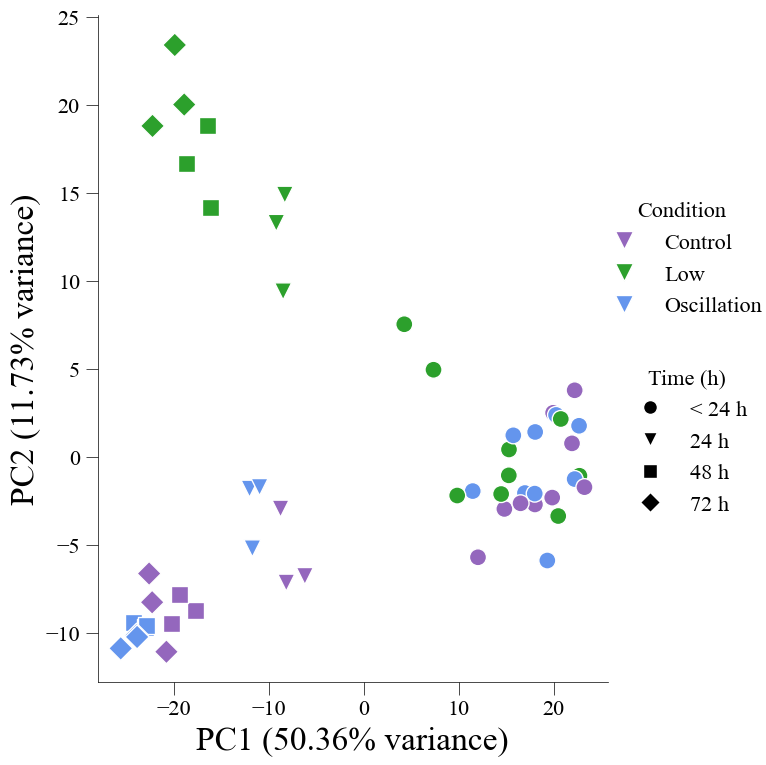

In [58]:
lipid = lipidomics.dropna(axis=0)
features = lipid.T
pca_df, explained_variance = pca_preprocess(features)
features['Condition'] = features.index.map(lipid_condition_dict)


pca_df['Condition'] = features['Condition'].values
pca_df['Timepoint'] = features.index.map(lipid_timepoint_dict)


pca_df['Batch']=0
# pca_df[pca_df.index<15]['Batch']=1
# pca_df['Reactor'] = df['Reactor'].values
pca_df.loc[pca_df.index <= 17, 'Batch'] = 1
pca_df.loc[pca_df.index > 17, 'Batch'] = 2
plot_pca(pca_df, explained_variance,)



# Differential expression analysis.

# preprocess data. 

In [59]:
lipidomics_data = lipidomics.copy()
lipidomics_data['lipid'] = lipidomics_data.index
lipidomics_data.index = lipidomics_data['lipid']
lipidomics_data = lipidomics_data.drop(columns=['lipid'])
lipidomics_data = lipidomics_data.T

lipidomics_data['Time (h)'] = lipidomics_data.index.map(lipid_timepoint_dict)
lipidomics_data['Condition'] = lipidomics_data.index.map(lipid_condition_dict)
lipidomics_data['combined'] = lipidomics_data['Condition'] + "_" + lipidomics_data['Time (h)'].astype(str)
lipidomics_data.rename(index={'PPI_Ylip_Osc_47hr_05': 'PPI_Ylip_Osc_48hr_05'}, inplace=True)

In [60]:
lip = lipidomics_data.drop(columns=['Condition','Time (h)','combined']).T

# lip['lipid'] = lip.index
# lip.index = lip['lipid']
# lip = lip.drop(columns=['lipid'])


In [61]:
lip.tail()

,PPI_Ylip_Ctrl_24hr_13,PPI_Ylip_Ctrl_24hr_25,PPI_Ylip_Ctrl_24hr_37,PPI_Ylip_Ctrl_3hr_07,PPI_Ylip_Ctrl_3hr_19,PPI_Ylip_Ctrl_3hr_31,PPI_Ylip_Ctrl_48hr_15,PPI_Ylip_Ctrl_48hr_27,PPI_Ylip_Ctrl_48hr_39,PPI_Ylip_Ctrl_4hr_09,...,PPI_Ylip_Osc_48hr_28,PPI_Ylip_Osc_4hr_02,PPI_Ylip_Osc_4hr_10,PPI_Ylip_Osc_4hr_22,PPI_Ylip_Osc_5hr_03,PPI_Ylip_Osc_5hr_12,PPI_Ylip_Osc_5hr_24,PPI_Ylip_Osc_72hr_06,PPI_Ylip_Osc_72hr_18,PPI_Ylip_Osc_72hr_30
lipid,,,,,,,,,,,,,,,,,,,,,
PS 34:2|PS 16:1_18:1_Neg,26.151497,26.204853,26.668654,24.485353,24.917534,24.467435,26.563338,27.517377,27.427478,26.316644,...,26.148316,23.853807,25.575554,24.575755,24.378892,23.999042,23.472622,27.082956,26.592536,27.306536
PS 34:3|PS 16:1_18:2_Neg,21.922784,21.622256,22.249945,22.182380,22.471076,21.754320,22.199900,23.241202,23.180653,23.612445,...,21.497560,20.899754,22.408655,21.977006,21.167752,20.783734,20.344045,22.224821,22.041227,22.456705
PS 36:3|PS 18:1_18:2_Neg,22.611695,22.778382,23.066782,21.982672,22.456388,21.972834,22.325820,23.461621,23.095878,23.719022,...,22.217822,21.308381,22.607539,21.783180,21.684530,21.478251,20.725867,22.554605,22.604825,22.958472
SM 36:1;2O_Neg,13.376558,NaN,NaN,NaN,NaN,12.572391,17.599572,14.130612,NaN,NaN,...,NaN,12.147371,13.009637,12.463638,NaN,NaN,NaN,13.854972,NaN,NaN
ST 27:1;O;S_Neg,23.790849,23.988537,23.711170,22.772032,24.140596,23.516403,24.922143,25.450679,24.099282,23.170746,...,24.159170,23.209749,22.898465,23.430768,22.601564,23.701056,23.727102,24.888690,24.196137,24.223095


# All Comparisions. 

In [64]:


# -----------------------------
# 0) Define time groups
# -----------------------------
EARLY_TIMES = ["3hr", "4hr", "5hr"]
LATE_TIMES  = ["24hr", "48hr", "72hr"]
ALL_TIMES   = EARLY_TIMES + LATE_TIMES

# Optional: map simplified labels if needed
TIME_LABELS = {
    "3hr": "3",
    "4hr": "4",
    "5hr": "5",
    "24hr": "24",
    "48hr": "48",
    "72hr": "72",
}

# -----------------------------
# 1) Helper functions for subsetting
# -----------------------------
def subset_condition_and_times(df, condition, times):
    """
    Keep only columns matching a given condition and one or more times.
    condition: 'Ctrl', 'Low', 'Osc'
    times: list of strings like ['24hr'] or ['3hr','4hr','5hr']
    """
    cond_mask = df.columns.str.contains(condition, case=False, regex=True)
    time_pattern = "|".join(times)
    time_mask = df.columns.str.contains(time_pattern, case=False, regex=True)
    return df.loc[:, cond_mask & time_mask]

def subset_condition_all(df, condition):
    """Keep all columns for a condition."""
    return df.loc[:, df.columns.str.contains(condition, case=False, regex=True)]

# -----------------------------
# 2) Mean difference on log2 data
# -----------------------------
def log2FC_function_logdata(case_df, ctrl_df):
    """
    Since data are already log2-transformed, log2FC is just:
        mean(case) - mean(control)
    Returns a Series indexed by lipid.
    """
    return case_df.mean(axis=1, skipna=True) - ctrl_df.mean(axis=1, skipna=True)

# -----------------------------
# 3) Pairwise stats helper
# -----------------------------
def _pair_stats(label, suffix, ctrl_df, case_df, lip_labels=None):
    """
    Returns:
        lipid,
        {label}/control_{suffix},
        {label}/control_{suffix}_ANOVA_p,
        {label}/control_{suffix}_ANOVA_padj
    """
    stats_df = global_stats_calc_from_groups(
        ctrl_df, case_df,
        lip_labels=lip_labels,
        min_non_na_per_group=2
    ).rename(columns={
        "ANOVA_p":    f"{label}/control_{suffix}_ANOVA_p",
        "ANOVA_padj": f"{label}/control_{suffix}_ANOVA_padj",
    })

    if stats_df.index.name == "lipid" or "lipid" not in stats_df.columns:
        stats_df = stats_df.reset_index()
        if stats_df.columns[0] != "lipid":
            stats_df = stats_df.rename(columns={stats_df.columns[0]: "lipid"})
    stats_df.index.name = None

    value_col = f"{label}/control_{suffix}"
    l2fc = log2FC_function_logdata(case_df, ctrl_df)

    if isinstance(l2fc, pd.Series):
        l2fc = l2fc.to_frame(name=value_col).reset_index()
        if l2fc.columns[0] != "lipid":
            l2fc = l2fc.rename(columns={l2fc.columns[0]: "lipid"})
    else:
        col = "log2FC" if "log2FC" in l2fc.columns else l2fc.columns[0]
        l2fc = l2fc[[col]].rename(columns={col: value_col}).reset_index()
        if l2fc.columns[0] != "lipid":
            l2fc = l2fc.rename(columns={l2fc.columns[0]: "lipid"})
    l2fc.index.name = None

    pair_df = pd.merge(
        l2fc[["lipid", value_col]],
        stats_df[["lipid",
                  f"{label}/control_{suffix}_ANOVA_p",
                  f"{label}/control_{suffix}_ANOVA_padj"]],
        on="lipid",
        how="outer",
    )
    return pair_df

# -----------------------------
# 4) Within-condition early vs late helper
# -----------------------------
def _within_condition_stats(condition_label, suffix, early_df, late_df, lip_labels=None):
    """
    Compare early vs late within one condition.
    Returns:
        lipid,
        {condition_label}_late/early_{suffix},
        {condition_label}_late/early_{suffix}_ANOVA_p,
        {condition_label}_late/early_{suffix}_ANOVA_padj
    """
    stats_df = global_stats_calc_from_groups(
        early_df, late_df,
        lip_labels=lip_labels,
        min_non_na_per_group=2
    ).rename(columns={
        "ANOVA_p":    f"{condition_label}_late/early_{suffix}_ANOVA_p",
        "ANOVA_padj": f"{condition_label}_late/early_{suffix}_ANOVA_padj",
    })

    if stats_df.index.name == "lipid" or "lipid" not in stats_df.columns:
        stats_df = stats_df.reset_index()
        if stats_df.columns[0] != "lipid":
            stats_df = stats_df.rename(columns={stats_df.columns[0]: "lipid"})
    stats_df.index.name = None

    value_col = f"{condition_label}_late/early_{suffix}"
    l2fc = log2FC_function_logdata(late_df, early_df)  # late - early

    if isinstance(l2fc, pd.Series):
        l2fc = l2fc.to_frame(name=value_col).reset_index()
        if l2fc.columns[0] != "lipid":
            l2fc = l2fc.rename(columns={l2fc.columns[0]: "lipid"})
    else:
        col = "log2FC" if "log2FC" in l2fc.columns else l2fc.columns[0]
        l2fc = l2fc[[col]].rename(columns={col: value_col}).reset_index()
        if l2fc.columns[0] != "lipid":
            l2fc = l2fc.rename(columns={l2fc.columns[0]: "lipid"})
    l2fc.index.name = None

    out = pd.merge(
        l2fc[["lipid", value_col]],
        stats_df[["lipid",
                  f"{condition_label}_late/early_{suffix}_ANOVA_p",
                  f"{condition_label}_late/early_{suffix}_ANOVA_padj"]],
        on="lipid",
        how="outer"
    )
    return out

# -----------------------------
# 5) Build all subsets once
# -----------------------------
subsets = {
    "ctrl": {
        "3": subset_condition_and_times(lip, "Ctrl", ["3hr"]),
        "4": subset_condition_and_times(lip, "Ctrl", ["4hr"]),
        "5": subset_condition_and_times(lip, "Ctrl", ["5hr"]),
        "24": subset_condition_and_times(lip, "Ctrl", ["24hr"]),
        "48": subset_condition_and_times(lip, "Ctrl", ["48hr"]),
        "72": subset_condition_and_times(lip, "Ctrl", ["72hr"]),
        "early_combined": subset_condition_and_times(lip, "Ctrl", EARLY_TIMES),
        "late_combined": subset_condition_and_times(lip, "Ctrl", LATE_TIMES),
    },
    "low": {
        "3": subset_condition_and_times(lip, "Low", ["3hr"]),
        "4": subset_condition_and_times(lip, "Low", ["4hr"]),
        "5": subset_condition_and_times(lip, "Low", ["5hr"]),
        "24": subset_condition_and_times(lip, "Low", ["24hr"]),
        "48": subset_condition_and_times(lip, "Low", ["48hr"]),
        "72": subset_condition_and_times(lip, "Low", ["72hr"]),
        "early_combined": subset_condition_and_times(lip, "Low", EARLY_TIMES),
        "late_combined": subset_condition_and_times(lip, "Low", LATE_TIMES),
    },
    "osc": {
        "3": subset_condition_and_times(lip, "Osc", ["3hr"]),
        "4": subset_condition_and_times(lip, "Osc", ["4hr"]),
        "5": subset_condition_and_times(lip, "Osc", ["5hr"]),
        "24": subset_condition_and_times(lip, "Osc", ["24hr"]),
        "48": subset_condition_and_times(lip, "Osc", ["48hr"]),
        "72": subset_condition_and_times(lip, "Osc", ["72hr"]),
        "early_combined": subset_condition_and_times(lip, "Osc", EARLY_TIMES),
        "late_combined": subset_condition_and_times(lip, "Osc", LATE_TIMES),
    }
}

# -----------------------------
# 6) LOW vs CTRL comparisons
# -----------------------------
pairs_low = [
    ("3",  subsets["ctrl"]["3"],  subsets["low"]["3"]),
    ("4",  subsets["ctrl"]["4"],  subsets["low"]["4"]),
    ("5",  subsets["ctrl"]["5"],  subsets["low"]["5"]),
    ("24", subsets["ctrl"]["24"], subsets["low"]["24"]),
    ("48", subsets["ctrl"]["48"], subsets["low"]["48"]),
    ("72", subsets["ctrl"]["72"], subsets["low"]["72"]),
    ("early_combined", subsets["ctrl"]["early_combined"], subsets["low"]["early_combined"]),
    ("late_combined",  subsets["ctrl"]["late_combined"],  subsets["low"]["late_combined"]),
]

df_low = None
for suffix, ctrl_df, low_df in pairs_low:
    one = _pair_stats("low", suffix, ctrl_df, low_df, lip_labels=None)
    df_low = one if df_low is None else df_low.merge(one, on="lipid", how="outer")

# -----------------------------
# 7) OSC vs CTRL comparisons
# -----------------------------
pairs_osc = [
    ("3",  subsets["ctrl"]["3"],  subsets["osc"]["3"]),
    ("4",  subsets["ctrl"]["4"],  subsets["osc"]["4"]),
    ("5",  subsets["ctrl"]["5"],  subsets["osc"]["5"]),
    ("24", subsets["ctrl"]["24"], subsets["osc"]["24"]),
    ("48", subsets["ctrl"]["48"], subsets["osc"]["48"]),
    ("72", subsets["ctrl"]["72"], subsets["osc"]["72"]),
    ("early_combined", subsets["ctrl"]["early_combined"], subsets["osc"]["early_combined"]),
    ("late_combined",  subsets["ctrl"]["late_combined"],  subsets["osc"]["late_combined"]),
]

df_osc = None
for suffix, ctrl_df, osc_df in pairs_osc:
    one = _pair_stats("osc", suffix, ctrl_df, osc_df, lip_labels=None)
    df_osc = one if df_osc is None else df_osc.merge(one, on="lipid", how="outer")

# -----------------------------
# 8) Early vs Late within each condition
# -----------------------------
within_pairs = [
    ("ctrl", subsets["ctrl"]["early_combined"], subsets["ctrl"]["late_combined"]),
    ("low",  subsets["low"]["early_combined"],  subsets["low"]["late_combined"]),
    ("osc",  subsets["osc"]["early_combined"],  subsets["osc"]["late_combined"]),
]

df_within = None
for cond_label, early_df, late_df in within_pairs:
    one = _within_condition_stats(cond_label, "combined", early_df, late_df, lip_labels=None)
    df_within = one if df_within is None else df_within.merge(one, on="lipid", how="outer")

# -----------------------------
# 9) Merge everything
# -----------------------------
final_df = df_low.merge(df_osc, on="lipid", how="outer")
final_df = final_df.merge(df_within, on="lipid", how="outer")

# -----------------------------
# 10) Optional: column order
# -----------------------------
order = ["lipid"]

for s in ["3", "4", "5", "24", "48", "72", "early_combined", "late_combined"]:
    order += [
        f"low/control_{s}", f"low/control_{s}_ANOVA_p", f"low/control_{s}_ANOVA_padj",
        f"osc/control_{s}", f"osc/control_{s}_ANOVA_p", f"osc/control_{s}_ANOVA_padj",
    ]

for cond in ["ctrl", "low", "osc"]:
    order += [
        f"{cond}_late/early_combined",
        f"{cond}_late/early_combined_ANOVA_p",
        f"{cond}_late/early_combined_ANOVA_padj",
    ]

final_df = final_df.reindex(columns=[c for c in order if c in final_df.columns])

final_df.head()

,lipid,low/control_3,low/control_3_ANOVA_p,low/control_3_ANOVA_padj,osc/control_3,osc/control_3_ANOVA_p,osc/control_3_ANOVA_padj,low/control_4,low/control_4_ANOVA_p,low/control_4_ANOVA_padj,...,osc/control_late_combined_ANOVA_padj,ctrl_late/early_combined,ctrl_late/early_combined_ANOVA_p,ctrl_late/early_combined_ANOVA_padj,low_late/early_combined,low_late/early_combined_ANOVA_p,low_late/early_combined_ANOVA_padj,osc_late/early_combined,osc_late/early_combined_ANOVA_p,osc_late/early_combined_ANOVA_padj
0,13-Docosenamide_Pos,-0.446223,0.495475,0.991905,-0.339214,0.598220,0.995335,0.163880,0.711057,0.942124,...,0.965676,-0.818383,0.063127,0.092767,-0.043655,0.898061,0.929731,-1.104340,0.003979,0.008727
1,Benzyl butyl phthalate (also known as chemical...,0.389343,0.877690,0.991905,-2.027802,0.249676,0.995335,0.602397,0.546911,0.892831,...,0.965676,-0.594510,0.579367,0.630081,0.387002,0.665942,0.743755,-0.520304,0.473414,0.501696
2,CL 68:4|CL 16:1_18:1_16:1_18:1_Neg,-0.362308,0.462071,0.991905,-0.189351,0.642093,0.995335,1.613961,0.028034,0.264706,...,0.975471,-2.253231,0.000008,0.000476,1.509145,0.001088,0.003908,-2.059234,0.001000,0.002916
3,CL 68:5|CL 16:1_18:1_16:1_18:2_Neg,-0.310902,0.287471,0.991905,-0.035609,0.911473,0.995335,1.378935,0.030268,0.264706,...,0.385496,-2.495991,0.000009,0.000476,0.960370,0.002440,0.006868,-1.691632,0.001269,0.003474
4,CL 68:6|CL 16:1_18:2_16:1_18:2_Neg,-0.359899,0.107160,0.991905,0.095800,0.707776,0.995335,1.270453,0.108519,0.436248,...,0.688442,-3.067276,0.000012,0.000476,-0.254454,0.408824,0.498595,-2.422986,0.000980,0.002886


## Volcano plot comparing low vs high, 
all late (increase means increased in low)


In [65]:

def get_dynamic_limits(dataset: pd.DataFrame, x_pad=0.1, y_pad=0.1, x_cutoff=None, y_cutoff=None):
    x = pd.to_numeric(dataset["log2FC"], errors="coerce").dropna()
    y = pd.to_numeric(dataset["-logP_adj"], errors="coerce").dropna()

    if x.empty:
        x_min, x_max = -1.0, 1.0
    else:
        q1, q99 = x.quantile([0.01, 0.99])
        m = max(abs(q1), abs(q99)) * (1 + x_pad)
        if x_cutoff is not None:
            m = max(m, abs(x_cutoff) * 1.2)
        x_min, x_max = -m, m

    if y.empty:
        y_min, y_max = 0.0, 3.0
    else:
        ymax = float(y.quantile(0.99)) * (1 + y_pad)
        if y_cutoff is not None:
            ymax = max(ymax, y_cutoff * 1.2)
        y_min, y_max = 0.0, ymax

    return x_min, x_max, y_min, y_max


def volcano_plot(
    dataset: pd.DataFrame,
    y_cutoff: float | None = None,
    x_cutoff: float | None = None,
    alpha: float = 0.05,
    fc: float = 1.3,
    title: str | None = None,
    save_path: str | None = None,
    formats: tuple = ("png", "svg"),
    dpi: int = 300,
    transparent: bool = True
):
    """
    Expects columns:
        - 'log2FC'
        - '-logP_adj' OR 'padj'

    Significance rule:
        |log2FC| >= x_cutoff AND padj <= alpha
    """

    ds = dataset.copy()

    # Build -log10 adjusted p if needed
    if "-logP_adj" not in ds.columns:
        if "padj" in ds.columns:
            ds["-logP_adj"] = -np.log10(ds["padj"].clip(lower=np.finfo(float).tiny))
        else:
            raise ValueError("Dataset must contain either '-logP_adj' or 'padj'.")

    # Thresholds
    if y_cutoff is None:
        y_cutoff = -np.log10(alpha)

    if x_cutoff is None:
        x_cutoff = np.log2(fc)   # <-- FIXED

    # Classify
    ds["class"] = 0
    ds.loc[(ds["log2FC"] >=  x_cutoff) & (ds["-logP_adj"] >= y_cutoff), "class"] = 1
    ds.loc[(ds["log2FC"] <= -x_cutoff) & (ds["-logP_adj"] >= y_cutoff), "class"] = -1

    # Global font
    plt.rcParams["font.family"] = "serif"
    plt.rcParams["font.serif"] = ["Times New Roman"]

    fig, ax = plt.subplots(figsize=(10, 7))

    hue_order = [-1, 0, 1]
    palette = {-1: "#0571B0", 0: "#BABABA", 1: "#CA0020"}

    sns.scatterplot(
        data=ds,
        x="log2FC",
        y="-logP_adj",
        hue="class",
        hue_order=hue_order,
        palette=palette,
        s=25,
        alpha=0.5,
        edgecolor=None,
        linewidth=0,
        legend=False,
        ax=ax,
    )

    x_min, x_max, y_min, y_max = get_dynamic_limits(ds)
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)

    ax.axhline(y_cutoff, ls="--", color="k")
    ax.axvline(x_cutoff, ls="--", color="k")
    ax.axvline(-x_cutoff, ls="--", color="k")

    ax.set_xlabel(r"Log$_2$(FC)", fontsize=14)
    ax.set_ylabel(r"-Log$_{10}$(P$_{adj}$)", fontsize=14)

    if title:
        ax.set_title(title, fontsize=16)

    handles = [
        plt.Line2D([0], [0], marker="o", color="none", markerfacecolor=palette[-1], markersize=6, label="down-regulated"),
        plt.Line2D([0], [0], marker="o", color="none", markerfacecolor=palette[0],  markersize=6, label="not significant"),
        plt.Line2D([0], [0], marker="o", color="none", markerfacecolor=palette[1],  markersize=6, label="up-regulated"),
    ]
    ax.legend(handles=handles, bbox_to_anchor=(1, 1), frameon=False)

    fig.tight_layout()

    if save_path:
        for fmt in formats:
            fig.savefig(
                f"{save_path}.{fmt}",
                dpi=dpi,
                bbox_inches="tight",
                transparent=transparent
            )

    return fig, ax

Volcano: ctrl_late/early_combined (n=410)
Volcano: low/control_3 (n=384)
Volcano: low/control_4 (n=402)
Volcano: low/control_5 (n=388)
Volcano: low/control_24 (n=399)
Volcano: low/control_48 (n=389)
Volcano: low/control_72 (n=390)
Volcano: low/control_early_combined (n=411)
Volcano: low/control_late_combined (n=411)
Volcano: low_late/early_combined (n=411)
Volcano: osc/control_3 (n=388)
Volcano: osc/control_4 (n=402)
Volcano: osc/control_5 (n=381)
Volcano: osc/control_24 (n=399)
Volcano: osc/control_48 (n=393)
Volcano: osc/control_72 (n=390)
Volcano: osc/control_early_combined (n=411)
Volcano: osc/control_late_combined (n=410)
Volcano: osc_late/early_combined (n=408)


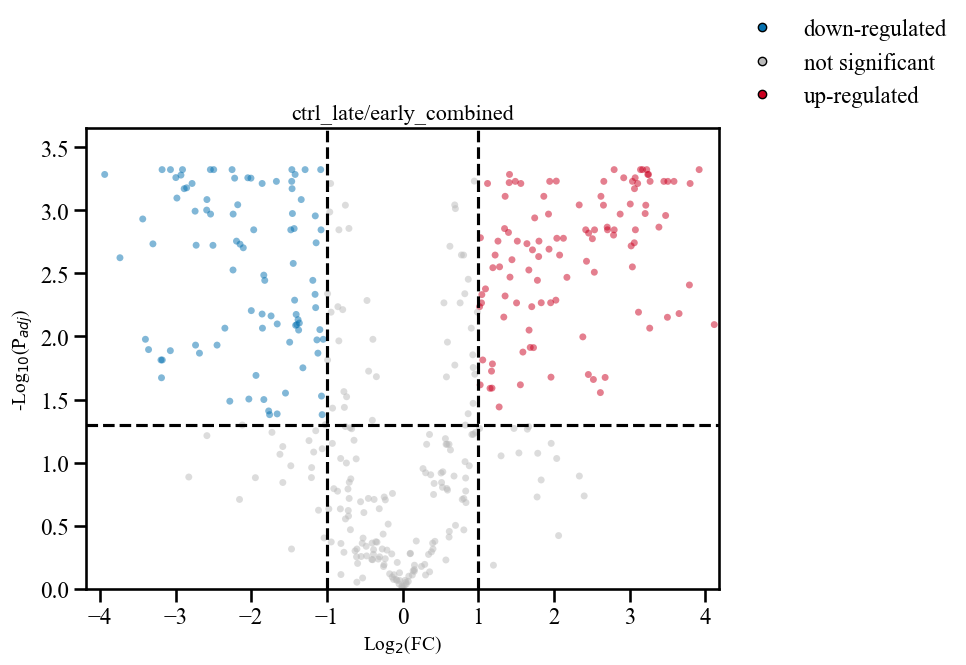

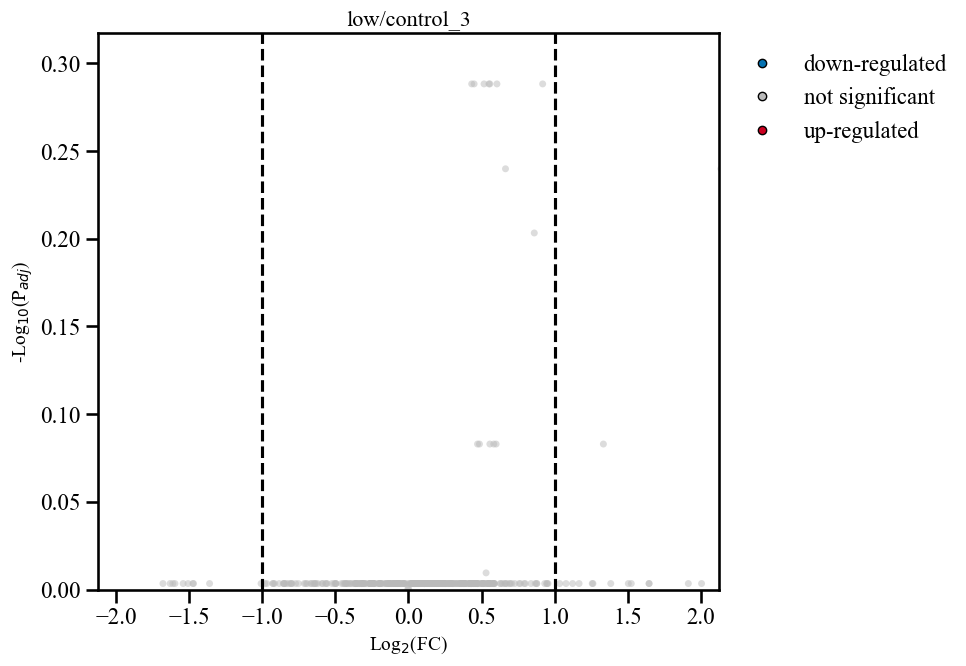

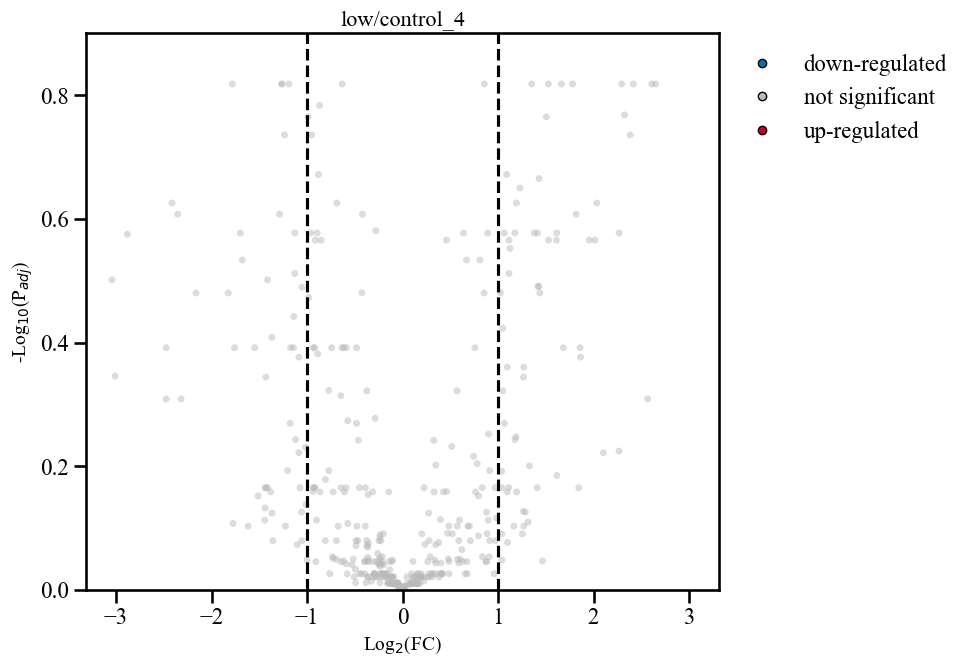

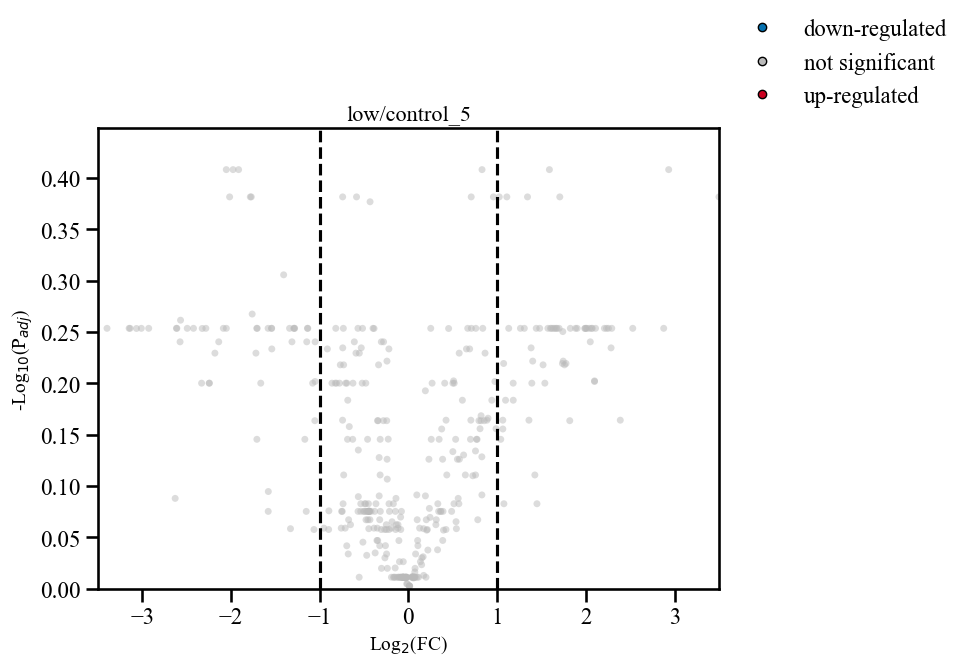

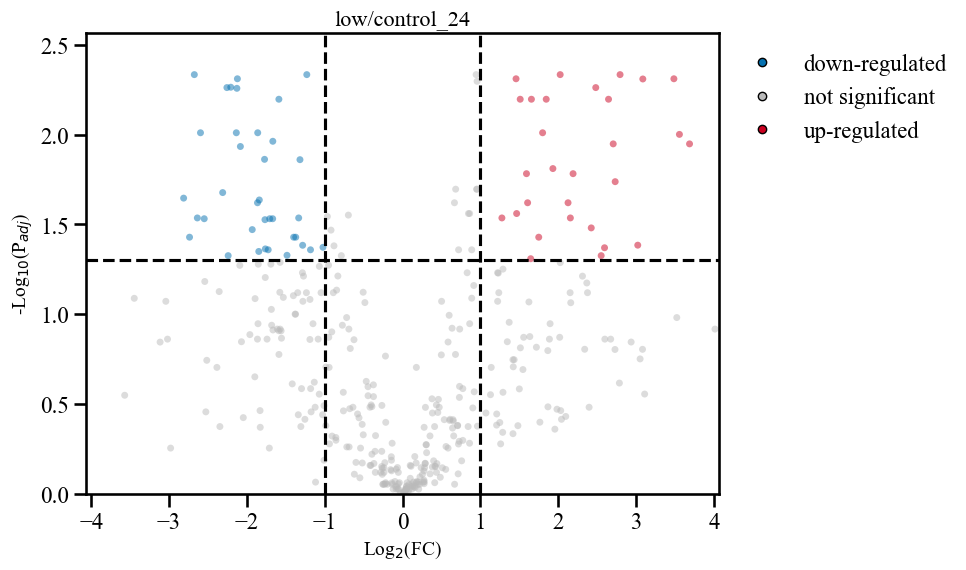

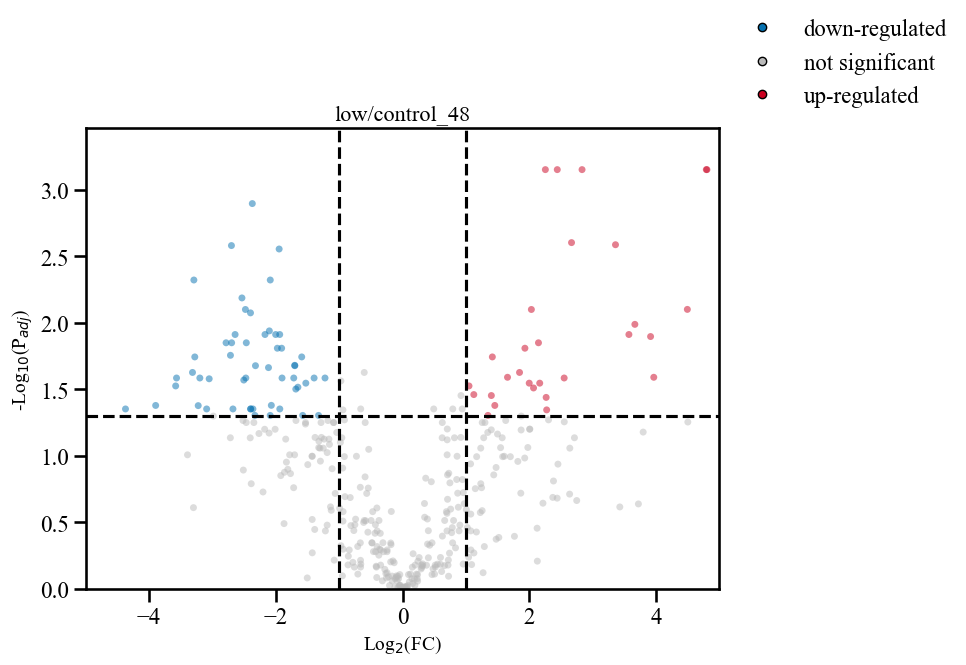

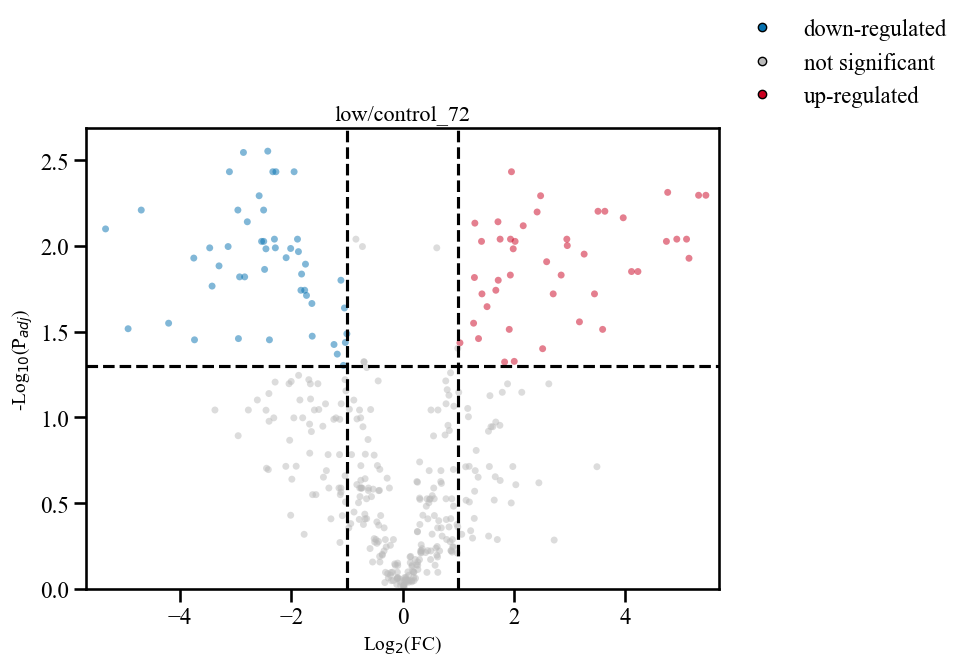

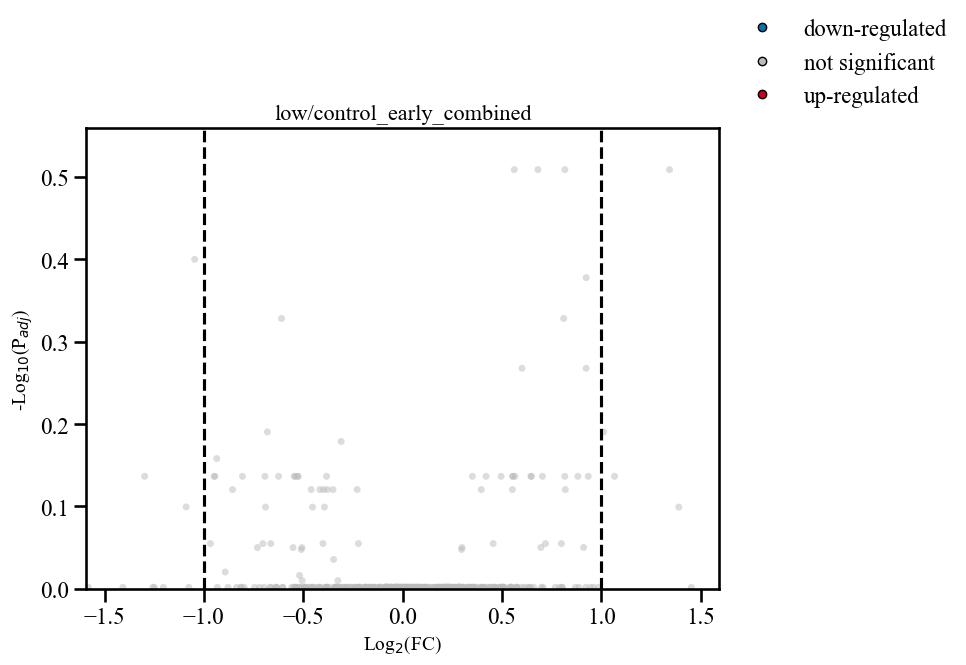

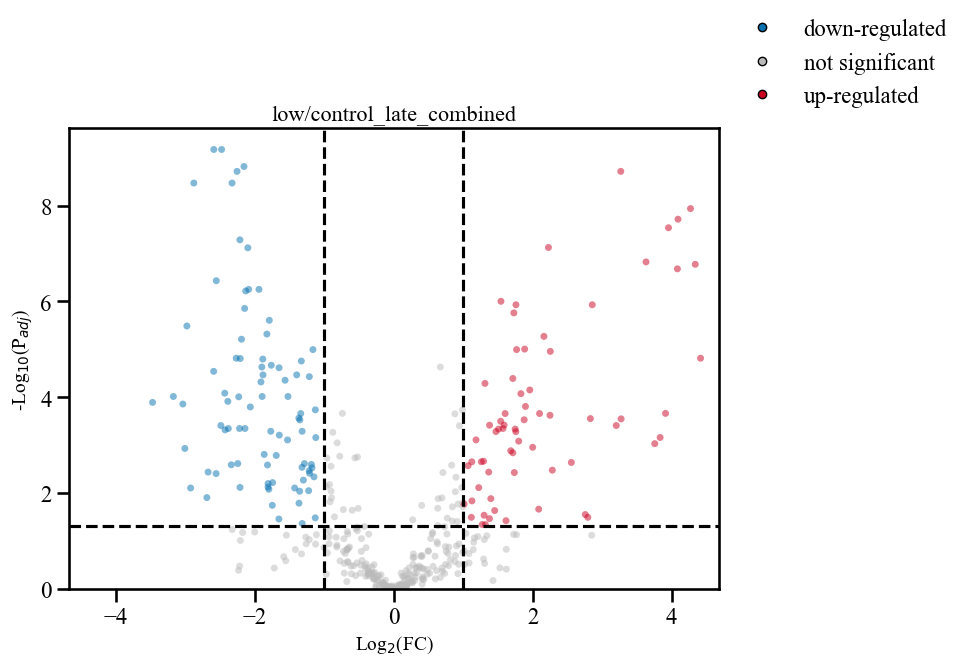

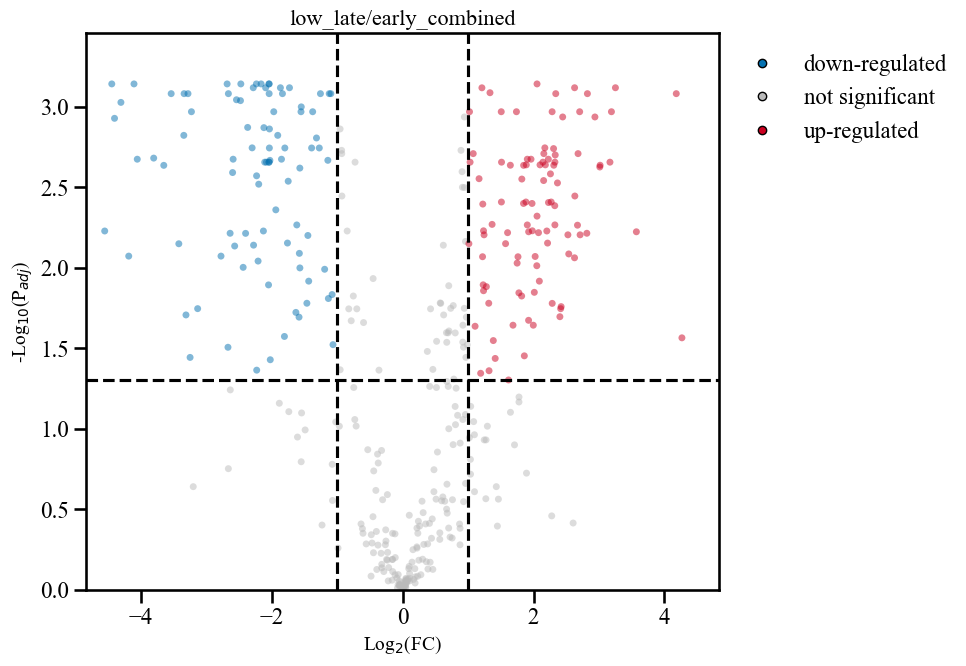

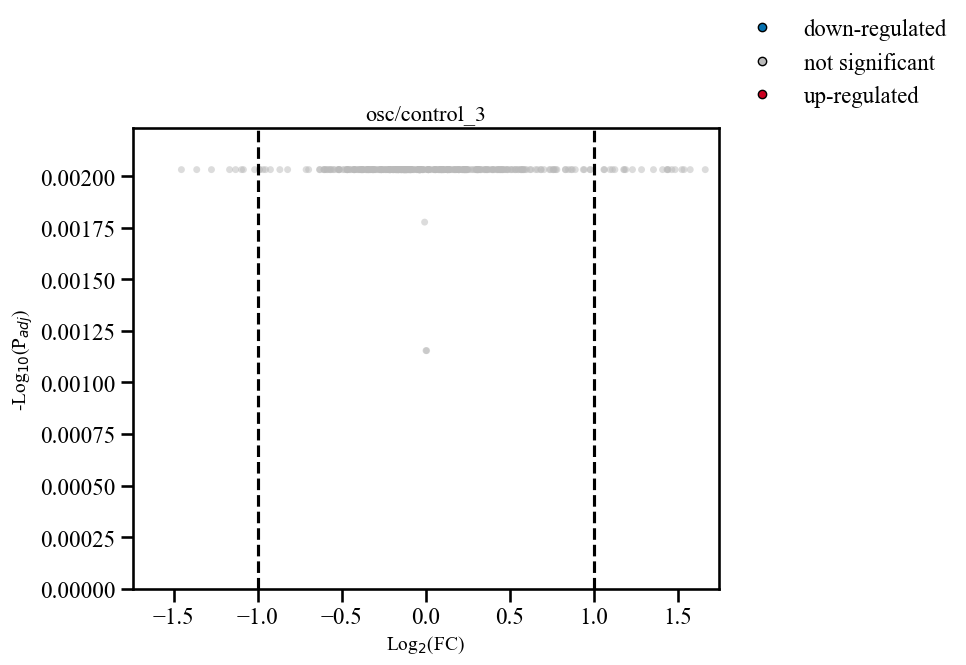

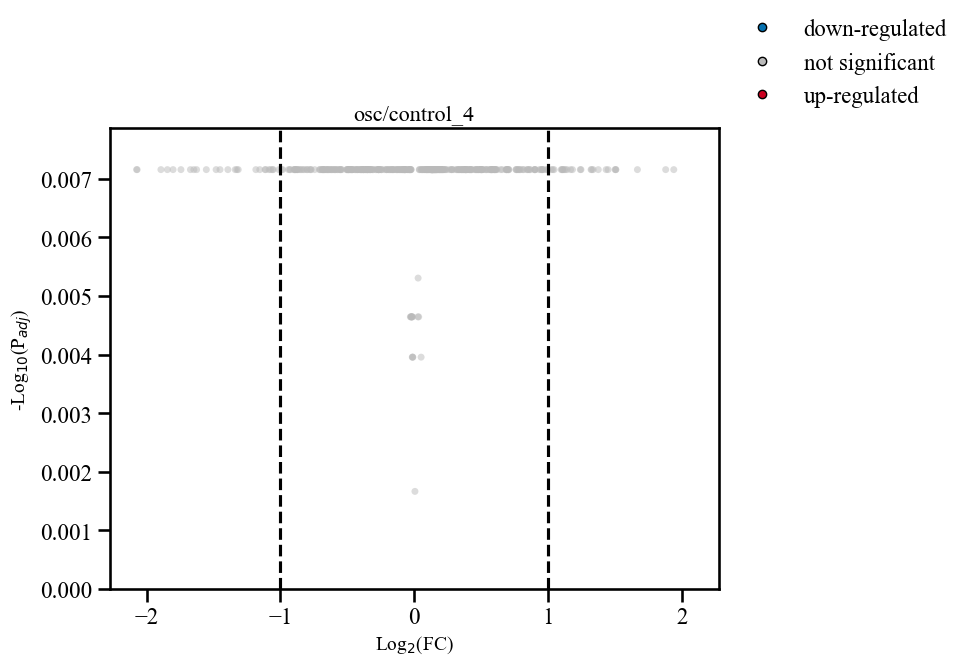

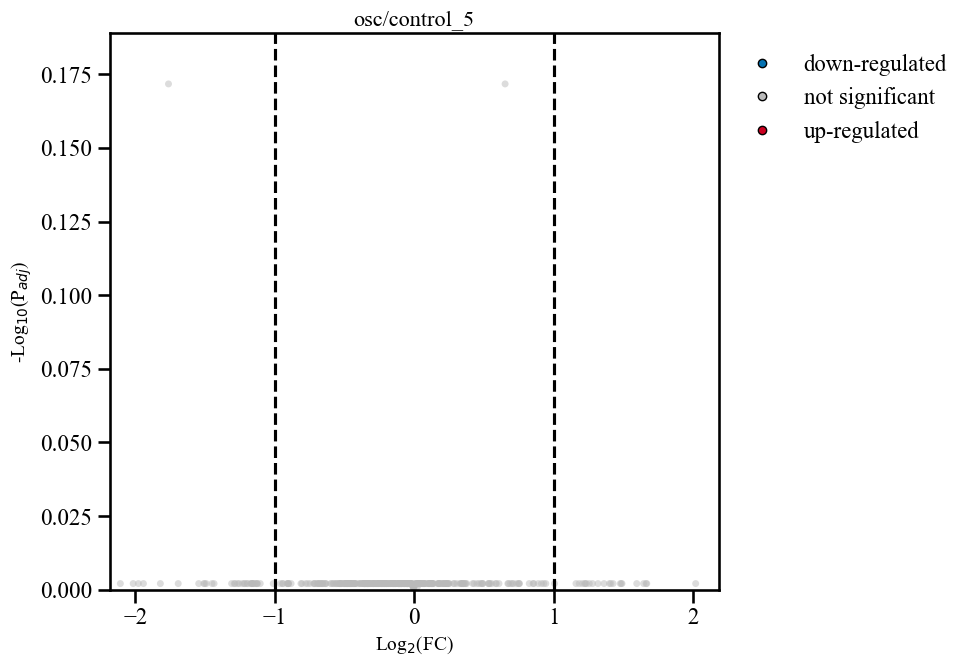

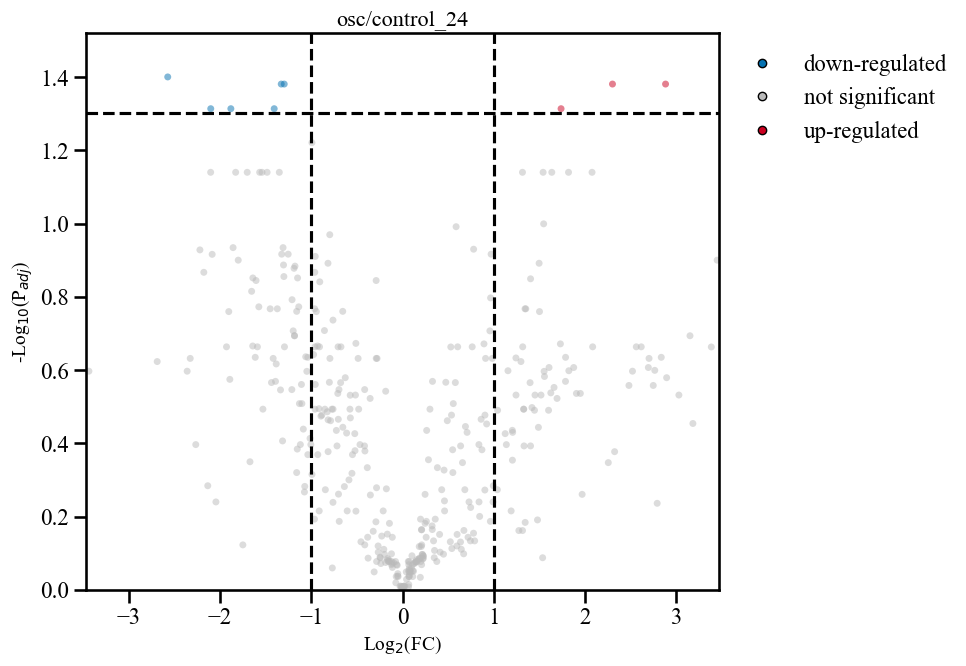

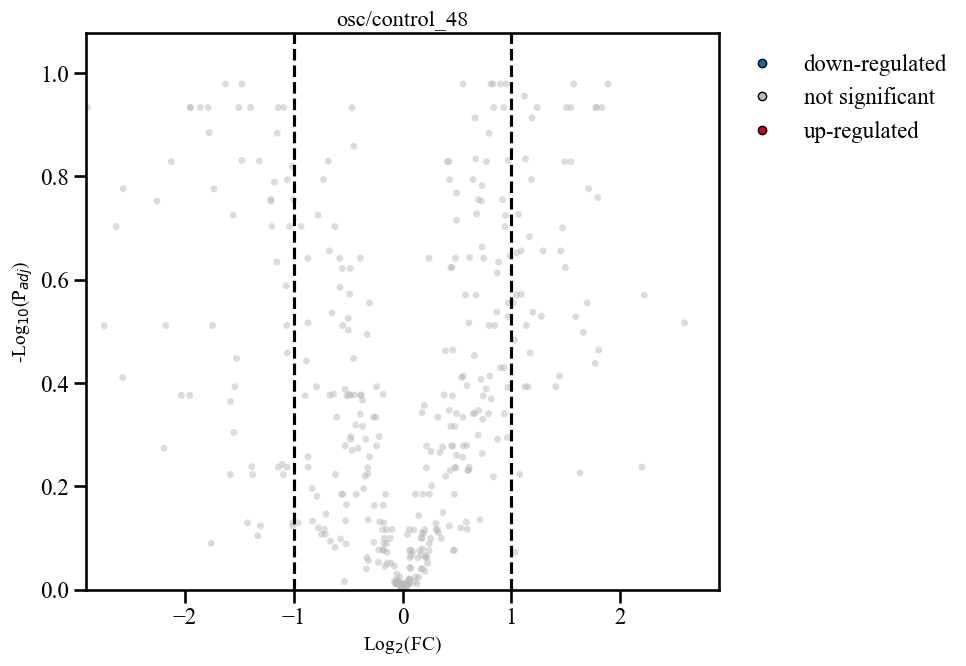

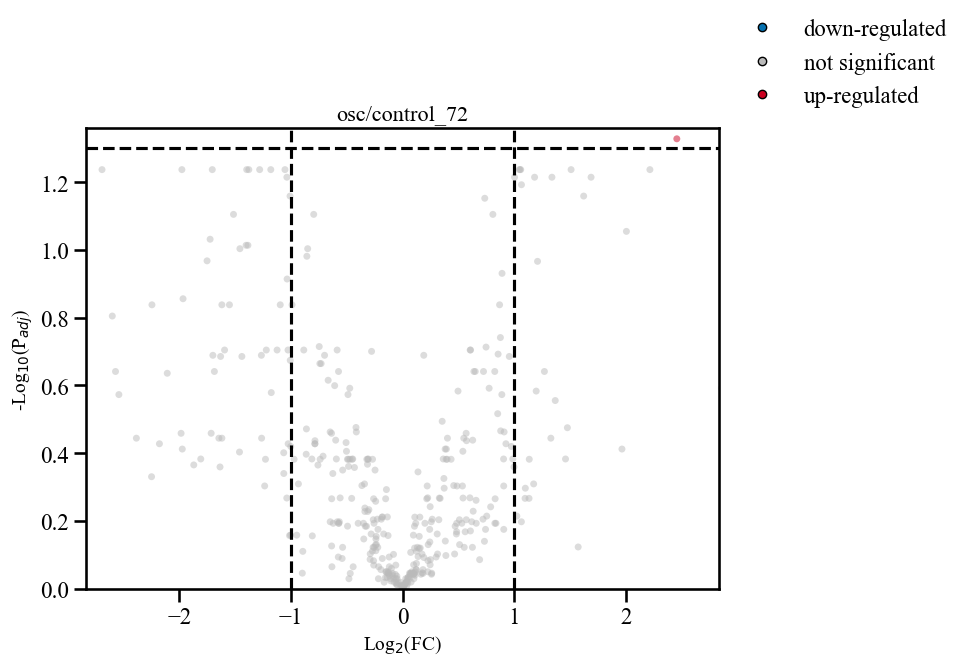

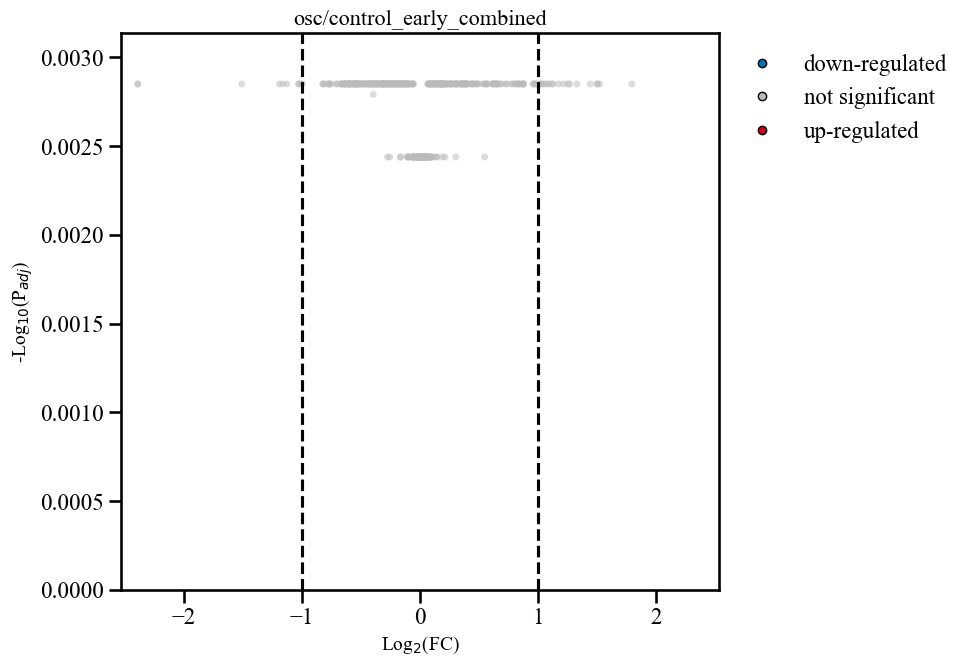

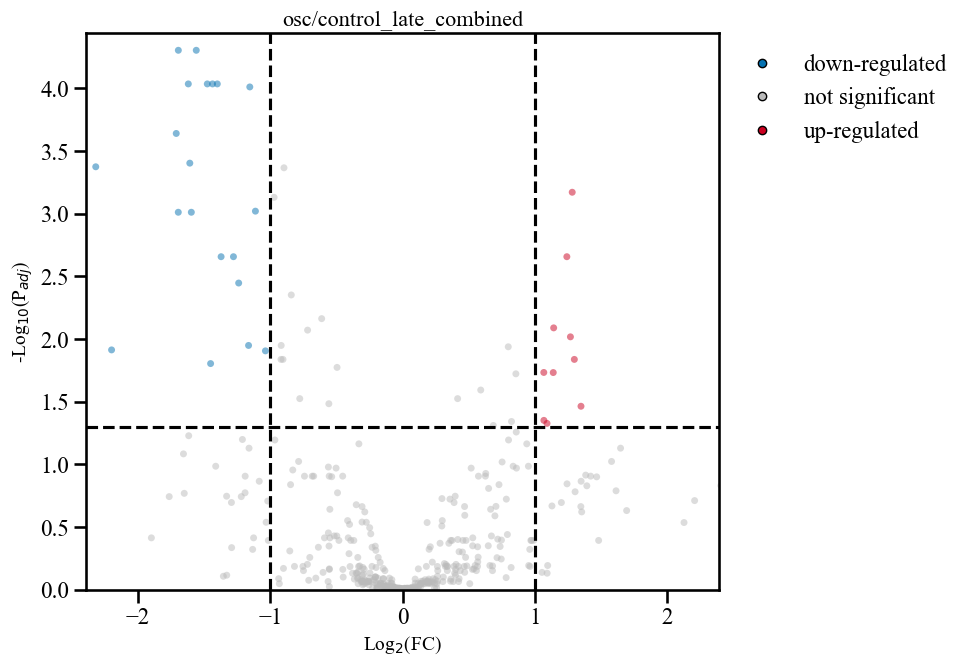

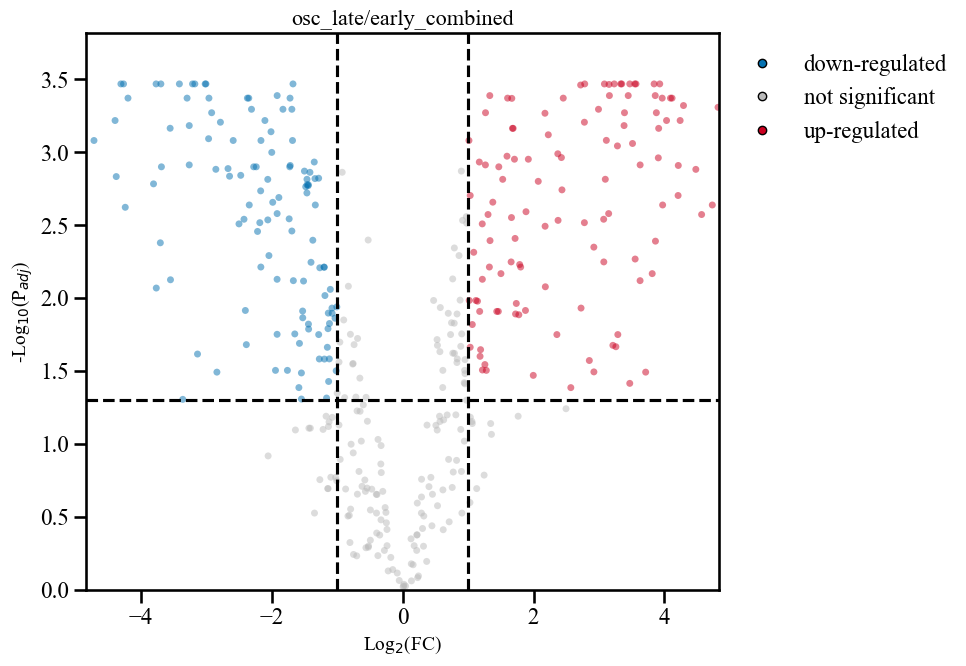

In [66]:
alpha = 0.05
fc_threshold = 2

assert "lipid" in final_df.columns, "final_df must have a 'lipid' column."
work = final_df.copy()

padj_cols = [c for c in work.columns if c.endswith("_ANOVA_padj")]
pairs = []

for padj_col in padj_cols:
    base = padj_col.replace("_ANOVA_padj", "")
    fc_col = base
    if fc_col in work.columns:
        pairs.append((base, fc_col, padj_col))

order_priority = ["3", "4", "5", "24", "48", "72", "early_combined", "late_combined"]
def sort_key(triple):
    base, _, _ = triple
    if "control_" in base:
        t = base.split("control_")[-1]
        group = base.split("/")[0]
    elif "_late/early_" in base:
        t = base.split("_late/early_")[-1]
        group = base.split("_late/early_")[0]
    else:
        t = ""
        group = base
    return (group, order_priority.index(t) if t in order_priority else 999, base)

pairs = sorted(pairs, key=sort_key)

volcano_inputs = {}

for base, fc_col, padj_col in pairs:
    ds = work[["lipid", fc_col, padj_col]].dropna(subset=[fc_col, padj_col]).copy()

    ds = ds.rename(columns={
        fc_col: "log2FC",
        padj_col: "padj"
    })

    volcano_inputs[base] = ds

    print(f"Volcano: {base} (n={len(ds)})")

    volcano_plot(
        ds,
        alpha=alpha,
        fc=fc_threshold,
        title=base
    )

# Add in Lipid ontology.

In [67]:
final_df

,lipid,low/control_3,low/control_3_ANOVA_p,low/control_3_ANOVA_padj,osc/control_3,osc/control_3_ANOVA_p,osc/control_3_ANOVA_padj,low/control_4,low/control_4_ANOVA_p,low/control_4_ANOVA_padj,...,osc/control_late_combined_ANOVA_padj,ctrl_late/early_combined,ctrl_late/early_combined_ANOVA_p,ctrl_late/early_combined_ANOVA_padj,low_late/early_combined,low_late/early_combined_ANOVA_p,low_late/early_combined_ANOVA_padj,osc_late/early_combined,osc_late/early_combined_ANOVA_p,osc_late/early_combined_ANOVA_padj
0,13-Docosenamide_Pos,-0.446223,0.495475,0.991905,-0.339214,0.598220,0.995335,0.163880,0.711057,0.942124,...,0.965676,-0.818383,0.063127,0.092767,-0.043655,0.898061,0.929731,-1.104340,0.003979,0.008727
1,Benzyl butyl phthalate (also known as chemical...,0.389343,0.877690,0.991905,-2.027802,0.249676,0.995335,0.602397,0.546911,0.892831,...,0.965676,-0.594510,0.579367,0.630081,0.387002,0.665942,0.743755,-0.520304,0.473414,0.501696
2,CL 68:4|CL 16:1_18:1_16:1_18:1_Neg,-0.362308,0.462071,0.991905,-0.189351,0.642093,0.995335,1.613961,0.028034,0.264706,...,0.975471,-2.253231,0.000008,0.000476,1.509145,0.001088,0.003908,-2.059234,0.001000,0.002916
3,CL 68:5|CL 16:1_18:1_16:1_18:2_Neg,-0.310902,0.287471,0.991905,-0.035609,0.911473,0.995335,1.378935,0.030268,0.264706,...,0.385496,-2.495991,0.000009,0.000476,0.960370,0.002440,0.006868,-1.691632,0.001269,0.003474
4,CL 68:6|CL 16:1_18:2_16:1_18:2_Neg,-0.359899,0.107160,0.991905,0.095800,0.707776,0.995335,1.270453,0.108519,0.436248,...,0.688442,-3.067276,0.000012,0.000476,-0.254454,0.408824,0.498595,-2.422986,0.000980,0.002886
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
414,TG 60:2|TG 24:0_18:1_18:1_Pos,-1.360230,0.160905,0.991905,-0.988526,0.430288,0.995335,-1.441023,0.317327,0.737373,...,0.972561,3.116810,0.002553,0.006421,2.365400,0.000782,0.002975,4.208449,0.000588,0.001984
415,TG 60:3|TG 24:0_18:1_18:2_#_Pos,0.401899,NaN,NaN,1.354223,0.277796,0.995335,-3.045206,0.050496,0.315162,...,0.885705,3.652795,0.002650,0.006585,1.037426,0.132892,0.191645,3.552416,0.002147,0.005408
416,TG 60:3|TG 24:0_18:1_18:2_Pos,0.528399,0.815545,0.991905,1.523504,0.564222,0.995335,-2.320720,0.135655,0.491291,...,0.975471,4.117920,0.003431,0.008054,1.647423,0.048276,0.079049,4.479431,0.000312,0.001313
417,TG 62:2|TG 18:0_26:0_18:2_Pos,NaN,NaN,NaN,NaN,NaN,NaN,-1.776862,0.365322,0.781167,...,0.651204,0.047764,0.909151,0.918109,1.463257,0.197820,0.273750,3.258252,0.012538,0.021584


In [68]:

ontology_text = """
Metabolite name	Ontology
Cer 36:0;2O|Cer 18:0;2O/18:0_A	Cer_NDS
Cer 36:0;2O|Cer 18:0;2O/18:0_B	Cer_NDS
Cer 36:0;3O|Cer 18:0;2O/18:0;O	Cer_HDS
Cer 36:0;4O|Cer 18:0;3O/18:0;(2OH)_A	Cer_AP
Cer 36:0;4O|Cer 18:0;3O/18:0;(2OH)_B	Cer_AP
Cer 36:0;4O|Cer 18:0;3O/18:0;(2OH)_C	Cer_AP
Cer 36:1;2O|Cer 18:1;2O/18:0_A	Cer_NS
Cer 36:1;2O|Cer 18:1;2O/18:0_B	Cer_NS
Cer 36:2;2O|Cer 18:2;2O/18:0	Cer_NS
Cer 36:3;2O|Cer 18:2;2O/18:1_A	Cer_NS
Cer 36:3;2O|Cer 18:2;2O/18:1_B	Cer_NS
Cer 36:3;3O|Cer 12:2;2O/24:1;O	Cer_HS
Cer 37:2;2O|Cer 19:2;2O/18:0	Cer_NS
Cer 37:2;3O|Cer 12:2;2O/25:0;O	Cer_HS
Cer 39:2;3O|Cer 22:0;2O/17:2;O	Cer_HDS
Cer 40:0;4O|Cer 18:0;3O/22:0;(2OH)	Cer_AP
Cer 40:1;4O	Cer_AP
Cer 41:1;4O|Cer 18:0;3O/23:1;(2OH)	Cer_AP
Cer 41:3;4O|Cer 17:2;3O/24:1;(2OH)	Cer_AP
Cer 42:0;4O|Cer 18:0;3O/24:0;(2OH)	Cer_AP
Cer 42:1;2O|Cer 18:1;2O/24:0	Cer_NS
Cer 42:1;4O|Cer 18:0;3O/24:1;(2OH)	Cer_AP
Cer 42:1;4O|Cer 27:1;3O/15:0;(2OH)	Cer_AP
Cer 42:2;3O|Cer 18:1;2O/24:1;O	Cer_HS
Cer 42:2;3O|Cer 18:2;2O/24:0;O	Cer_HS
Cer 43:0;4O|Cer 18:0;3O/25:0;(2OH)_A	Cer_AP
Cer 43:0;4O|Cer 18:0;3O/25:0;(2OH)_B	Cer_AP
Cer 43:1;4O|Cer 18:0;3O/25:1;(2OH)	Cer_AP
Cer 44:0;4O|Cer 18:0;3O/26:0;(2OH)_A	Cer_AP
Cer 44:0;4O|Cer 18:0;3O/26:0;(2OH)_B	Cer_AP
DG 30:0	DG
DG 32:0	DG
DG 32:0|DG 16:0_16:0	DG
DG 32:1	DG
DG 32:2	DG
DG 33:1	DG
DG 34:0	DG
DG 34:1	DG
DG 34:1|DG 16:0_18:1	DG
DG 34:2	DG
DG 34:2|DG 16:0_18:2	DG
DG 34:3_A	DG
DG 34:3_B	DG
DG 34:3|DG 16:1_18:2	DG
DG 35:1	DG
DG 35:2	DG
DG 35:3	DG
DG 36:0	DG
DG 36:1	DG
DG 36:1|DG 18:0_18:1_A	DG
DG 36:1|DG 18:0_18:1_B	DG
DG 36:2	DG
DG 36:2|DG 18:1_18:1_A	DG
DG 36:2|DG 18:1_18:1_B	DG
DG 36:3	DG
DG 36:3|DG 18:1_18:2	DG
DG 36:4	DG
DG 36:5	DG
DG 37:7	DG
DG 38:1	DG
DG 38:9	DG
DG 40:1	DG
DG 42:1	DG
DG 42:1|DG 24:0_18:1	DG
DG 42:2	DG
LPC 16:0	LPC
LPC 16:0/0:0	LPC
LPC 16:1	LPC
LPC 16:1/0:0	LPC
LPC 17:1	LPC
LPC 17:1/0:0	LPC
LPC 18:0	LPC
LPC 18:0/0:0	LPC
LPC 18:1	LPC
LPC 18:1/0:0	LPC
LPC 18:2/0:0	LPC
LPC 20:1/0:0	LPC
LPE 18:1	LPE
LPE 18:2	LPE
NAE 16:0_A	NAE
NAE 16:0_B	NAE
NAE 16:0_C	NAE
NAE 16:0_D	NAE
NAE 16:0_E	NAE
NAE 16:0_F	NAE
NAE 18:2	NAE
NAE 20:0	NAE
NAE 20:2	NAE
PC 32:1	PC
PC 32:2|PC 16:1_16:1	PC
PC 32:3|PC 14:0_18:3	PC
PC 33:1|PC 15:0_18:1	PC
PC 33:2|PC 15:0_18:2	PC
PC 33:3|PC 15:0_18:3	PC
PC 34:1|PC 16:0_18:1	PC
PC 34:2	PC
PC 34:2|PC 16:0_18:2	PC
PC 34:3_A	PC
PC 34:3_B	PC
PC 34:3|PC 16:0_18:3	PC
PC 34:3|PC 16:1_18:2	PC
PC 34:4|PC 16:2_18:2	PC
PC 34:5|PC 16:2_18:3	PC
PC 35:1|PC 17:0_18:1	PC
PC 35:2_A	PC
PC 35:2_B	PC
PC 35:2|PC 17:1_18:1	PC
PC 35:3	PC
PC 35:3|PC 17:1_18:2	PC
PC 35:4|PC 17:2_18:2	PC
PC 35:5|PC 17:2_18:3	PC
PC 35:7|PC 18:3_17:4	PC
PC 35:8|PC 17:3_18:5	PC
PC 35:9|PC 17:4_18:5	PC
PC 36:1	PC
PC 36:1|PC 18:0_18:1	PC
PC 36:2	PC
PC 36:2|PC 18:1_18:1_A	PC
PC 36:2|PC 18:1_18:1_B	PC
PC 36:3_A	PC
PC 36:3_B	PC
PC 36:3|PC 18:1_18:2	PC
PC 36:4|PC 18:2_18:2	PC
PC 36:5	PC
PC 36:5|PC 18:2_18:3	PC
PC 36:8|PC 17:3_19:5	PC
PC 36:9	PC
PC 37:2	PC
PC 37:7|PC 17:2_20:5	PC
PC 37:8|PC 17:3_20:5	PC
PC 37:9|PC 17:4_20:5	PC
PC 38:2|PC 18:1_20:1	PC
PC 38:2|PC 20:0_18:2	PC
PC 38:3|PC 20:1_18:2	PC
PC 38:4|PC 18:2_20:2	PC
PC 40:2|PC 20:1_20:1	PC
PC 40:3|PC 22:0_18:3	PC
PC 42:1|PC 24:0_18:1	PC
PC 42:2|PC 24:0_18:2	PC
PC 42:3	PC
TG 45:0|TG 14:0_15:0_16:0	TG
TG 46:0|TG 14:0_16:0_16:0	TG
TG 46:1|TG 14:0_16:0_16:1_A	TG
TG 46:1|TG 14:0_16:0_16:1_B	TG
TG 47:0|TG 15:0_16:0_16:0	TG
TG 48:0|TG 14:0_16:0_18:0	TG
TG 48:1|TG 14:0_16:0_18:1_A	TG
TG 48:1|TG 14:0_16:0_18:1_B	TG
TG 48:2|TG 14:0_16:0_18:2_A	TG
TG 48:2|TG 14:0_16:0_18:2_B	TG
TG 49:1|TG 15:0_16:0_18:1_A	TG
TG 49:1|TG 15:0_16:0_18:1_B	TG
TG 49:2|TG 15:0_16:0_18:2	TG
TG 50:0|TG 16:0_16:0_18:0	TG
TG 50:1;1O|TG 16:0_16:0_18:1;1O	OxTG
TG 50:1|TG 16:0_16:0_18:1_A	TG
TG 50:1|TG 16:0_16:0_18:1_B	TG
TG 50:2|TG 16:0_16:1_18:1_A	TG
TG 50:2|TG 16:0_16:1_18:1_B	TG
TG 50:3|TG 14:0_18:1_18:2	TG
TG 50:3|TG 16:0_16:1_18:2_A	TG
TG 50:3|TG 16:0_16:1_18:2_B	TG
TG 50:4|TG 16:0_16:1_18:3	TG
TG 50:4|TG 16:1_16:1_18:2	TG
TG 51:0|TG 16:0_17:0_18:0	TG
TG 51:1|TG 16:0_17:0_18:1_A	TG
TG 51:1|TG 16:0_17:0_18:1_B	TG
TG 51:2|TG 16:0_17:0_18:2	TG
TG 51:2|TG 16:0_17:1_18:1_A	TG
TG 51:2|TG 16:0_17:1_18:1_B	TG
TG 51:3|TG 16:0_17:1_18:2_A	TG
TG 51:3|TG 16:0_17:1_18:2_B	TG
TG 51:4|TG 16:0_17:2_18:2	TG
TG 51:5|TG 15:0_18:2_18:3	TG
TG 52:0|TG 16:0_18:0_18:0	TG
TG 52:1|TG 16:0_18:0_18:1_A	TG
TG 52:1|TG 16:0_18:0_18:1_B	TG
TG 52:2|TG 16:0_18:0_18:2	TG
TG 52:2|TG 16:0_18:1_18:1	TG
TG 52:3|TG 16:0_18:1_18:2_A	TG
TG 52:3|TG 16:0_18:1_18:2_B	TG
TG 52:3|TG 16:0_18:1_18:2_C	TG
TG 52:4|TG 16:0_18:2_18:2_A	TG
TG 52:4|TG 16:0_18:2_18:2_B	TG
TG 52:4|TG 16:1_18:1_18:2	TG
TG 52:5|TG 16:0_18:2_18:3	TG
TG 52:5|TG 16:1_18:2_18:2	TG
TG 52:6|TG 16:0_18:3_18:3	TG
TG 52:6|TG 16:1_18:2_18:3	TG
TG 53:1|TG 17:0_18:0_18:1	TG
TG 53:2|TG 17:0_18:1_18:1_A	TG
TG 53:2|TG 17:0_18:1_18:1_B	TG
TG 53:2|TG 17:0_18:1_18:1_C	TG
TG 53:3|TG 17:1_18:1_18:1_A	TG
TG 53:3|TG 17:1_18:1_18:1_B	TG
TG 53:4|TG 17:0_18:2_18:2	TG
TG 53:4|TG 17:1_18:1_18:2	TG
TG 53:5|TG 17:0_18:2_18:3	TG
TG 53:6|TG 17:1_18:2_18:3	TG
TG 54:0|TG 16:0_18:0_20:0	TG
TG 54:1|TG 16:0_20:0_18:1_A	TG
TG 54:1|TG 16:0_20:0_18:1_B	TG
TG 54:2|TG 18:0_18:1_18:1_A	TG
TG 54:2|TG 18:0_18:1_18:1_B	TG
TG 54:3|TG 18:0_18:1_18:2_A	TG
TG 54:3|TG 18:0_18:1_18:2_B	TG
TG 54:4|TG 18:1_18:1_18:2_A	TG
TG 54:4|TG 18:1_18:1_18:2_B	TG
TG 54:5;1O|TG 19:1_18:2_17:2;1O	OxTG
TG 54:5|TG 18:1_18:2_18:2_A	TG
TG 54:5|TG 18:1_18:2_18:2_B	TG
TG 54:5|TG 18:1_18:2_18:2_C	TG
TG 54:6|TG 18:1_18:2_18:3	TG
TG 54:6|TG 18:2_18:2_18:2	TG
TG 54:7|TG 18:2_18:2_18:3_A	TG
TG 54:7|TG 18:2_18:2_18:3_B	TG
TG 55:2|TG 18:0_18:1_19:1	TG
TG 55:3|TG 18:1_18:1_19:1	TG
TG 56:0|TG 16:0_16:0_24:0	TG
TG 56:1|TG 16:0_22:0_18:1_A	TG
TG 56:1|TG 16:0_22:0_18:1_B	TG
TG 56:2|TG 16:0_18:1_22:1	TG
TG 56:2|TG 16:0_22:0_18:2	TG
TG 56:2|TG 20:0_18:1_18:1	TG
TG 56:3|TG 18:1_18:1_20:1	TG
TG 56:4|TG 18:1_18:1_20:2	TG
TG 57:1|TG 16:0_23:0_18:1_A	TG
TG 57:1|TG 16:0_23:0_18:1_B	TG
TG 57:2|TG 16:0_23:0_18:2_A	TG
TG 57:2|TG 16:0_23:0_18:2_B	TG
TG 57:2|TG 16:0_23:0_18:2_C	TG
TG 57:3|TG 16:0_23:0_18:3	TG
TG 58:0|TG 16:0_18:0_24:0_A	TG
TG 58:0|TG 16:0_18:0_24:0_B	TG
TG 58:1|TG 16:0_24:0_18:1_A	TG
TG 58:1|TG 16:0_24:0_18:1_B	TG
TG 58:1|TG 16:0_24:0_18:1_C	TG
TG 58:2|TG 16:0_24:0_18:2_A	TG
TG 58:2|TG 16:0_24:0_18:2_B	TG
TG 58:2|TG 16:0_24:0_18:2_C	TG
TG 58:3|TG 22:0_18:1_18:2	TG
TG 58:4|TG 22:0_18:2_18:2	TG
TG 59:1|TG 16:0_25:0_18:1_A	TG
TG 59:1|TG 16:0_25:0_18:1_B	TG
TG 59:2|TG 16:0_18:1_25:1	TG
TG 59:2|TG 16:0_25:0_18:2_A	TG
TG 59:2|TG 16:0_25:0_18:2_B	TG
TG 59:3|TG 23:0_18:1_18:2	TG
TG 59:4|TG 23:0_18:1_18:3	TG
TG 60:1|TG 18:0_24:0_18:1	TG
TG 60:12|TG 20:4_20:4_20:4	TG
TG 60:2|TG 24:0_18:1_18:1	TG
TG 60:3|TG 24:0_18:1_18:2_A	TG
TG 60:3|TG 24:0_18:1_18:2_B	TG
TG 60:3|TG 24:0_18:1_18:2_C	TG
TG 60:4|TG 24:0_18:1_18:3	TG
TG 60:4|TG 24:0_18:2_18:2	TG
TG 60:5|TG 24:0_18:2_18:3	TG
TG 61:1|TG 18:0_25:0_18:1_A	TG
TG 61:1|TG 18:0_25:0_18:1_B	TG
TG 61:2|TG 25:0_18:1_18:1	TG
TG 62:1|TG 18:0_26:0_18:1_A	TG
TG 62:1|TG 18:0_26:0_18:1_B	TG
TG 62:2|TG 26:0_18:1_18:1_A	TG
TG 62:2|TG 26:0_18:1_18:1_B	TG
TG 62:3|TG 18:1_18:1_26:1	TG
TG 62:4|TG 18:1_26:1_18:2	TG
TG 64:1|TG 22:0_24:0_18:1	TG
TG 66:1|TG 24:0_24:0_18:1	TG
Adenosine	Others
Cer 20:0;2O	Cer_NDS
Cer 34:0;2O|Cer 18:0;2O/16:0	Cer_NDS
Cer 34:0;4O|Cer 18:0;3O/16:0;(2OH)	Cer_AP
Cer 34:2;2O|Cer 18:2;2O/16:0_A	Cer_NS
Cer 34:2;2O|Cer 18:2;2O/16:0_B	Cer_NS
Cer 36:0;2O|Cer 18:0;2O/18:0_A	Cer_NDS
Cer 36:0;2O|Cer 18:0;2O/18:0_B	Cer_NDS
Cer 36:0;4O|Cer 18:0;3O/18:0;(2OH)_A	Cer_AP
Cer 36:0;4O|Cer 18:0;3O/18:0;(2OH)_B	Cer_AP
Cer 36:1;2O|Cer 18:1;2O/18:0_A	Cer_NS
Cer 36:1;2O|Cer 18:1;2O/18:0_B	Cer_NS
Cer 36:2;2O|Cer 18:2;2O/18:0_A	Cer_NS
Cer 36:2;2O|Cer 18:2;2O/18:0_B	Cer_NS
Cer 37:2;2O|Cer 19:2;2O/18:0_A	Cer_NS
Cer 37:2;2O|Cer 19:2;2O/18:0_B	Cer_NS
Cer 38:0;4O|Cer 18:0;3O/20:0;(2OH)	Cer_AP
Cer 40:0;4O|Cer 18:0;3O/22:0;(2OH)	Cer_AP
Cer 41:0;4O|Cer 18:0;3O/23:0;(2OH)_A	Cer_AP
Cer 41:0;4O|Cer 18:0;3O/23:0;(2OH)_B	Cer_AP
Cer 42:0;2O|Cer 18:0;2O/24:0	Cer_NDS
Cer 42:0;4O|Cer 18:0;3O/24:0;(2OH)_A	Cer_AP
Cer 42:0;4O|Cer 18:0;3O/24:0;(2OH)_B	Cer_AP
Cer 43:0;4O|Cer 18:0;3O/25:0;(2OH)_A	Cer_AP
Cer 43:0;4O|Cer 18:0;3O/25:0;(2OH)_B	Cer_AP
Cer 44:0;2O	Cer_NDS
Cer 44:0;4O|Cer 20:0;3O/24:0;(2OH)_A	Cer_AP
Cer 44:0;4O|Cer 20:0;3O/24:0;(2OH)_B	Cer_AP
CL 68:3|CL 16:0_18:1_16:0_18:2	CL
CL 68:4|CL 16:0_18:2_16:0_18:2	CL
CL 68:5|CL 36:2_32:3	CL
CL 70:4|CL 16:0_18:1_18:1_18:2	CL
CL 70:5|CL 16:0_18:2_18:1_18:2	CL
CL 70:6|CL 16:0_18:2_18:2_18:2	CL
CL 70:7|CL 16:1_18:2_18:2_18:2	CL
CL 72:10|CL 18:2_18:3_18:2_18:3	CL
CL 72:4|CL 18:1_18:1_18:1_18:1	CL
CL 72:5|CL 18:1_18:1_18:1_18:2	CL
CL 72:6|CL 18:1_18:2_18:1_18:2	CL
CL 72:7|CL 18:1_18:2_18:2_18:2	CL
CL 72:8|CL 18:2_18:2_18:2_18:2	CL
CL 72:9|CL 18:2_18:2_18:2_18:3	CL
CL 74:1|CL 16:0_16:0_24:0_18:1	CL
FA 14:0	FA
FA 15:0_A	FA
FA 15:0_B	FA
FA 15:0;(2OH)	OxFA
FA 15:0;O	OxFA
FA 15:1;2O	OxFA
FA 15:1;O_A	OxFA
FA 15:1;O_B	OxFA
FA 15:4	FA
FA 16:0	FA
FA 16:0;(2OH)	OxFA
FA 16:0;O_A	OxFA
FA 16:0;O_B	OxFA
FA 16:1	FA
FA 16:2	FA
FA 16:2;2O	OxFA
FA 17:0	FA
FA 17:0;O	OxFA
FA 17:1	FA
FA 17:2	FA
FA 17:3	FA
FA 18:0	FA
FA 18:0;(2OH)	OxFA
FA 18:0;O	OxFA
FA 18:1	FA
FA 18:1;O_A	OxFA
FA 18:1;O_B	OxFA
FA 18:2	FA
FA 18:2;2O_A	OxFA
FA 18:2;2O_B	OxFA
FA 18:2;2O_C	OxFA
FA 18:2;O	OxFA
FA 18:3	FA
FA 19:1;2O_A	OxFA
FA 19:1;2O_B	OxFA
FA 19:1;O	OxFA
FA 19:2;2O_A	OxFA
FA 19:2;2O_B	OxFA
FA 20:0_A	FA
FA 20:0_B	FA
FA 20:0;O	OxFA
FA 20:1_A	FA
FA 20:1_B	FA
FA 20:2_A	FA
FA 20:2_B	FA
FA 20:3	FA
FA 20:4	FA
FA 21:0_A	FA
FA 21:0_B	FA
FA 21:0_C	FA
FA 21:0_D	FA
FA 21:0_E	FA
FA 21:0;O	OxFA
FA 21:1;O	OxFA
FA 21:2;2O_A	OxFA
FA 21:2;2O_B	OxFA
FA 21:4;O	OxFA
FA 22:0_A	FA
FA 22:0_B	FA
FA 22:0_C	FA
FA 22:0_D	FA
FA 22:0_E	FA
FA 22:0;(2OH)	OxFA
FA 22:0;2O_A	OxFA
FA 22:0;2O_B	OxFA
FA 22:0;O	OxFA
FA 22:1	FA
FA 22:1;2O_A	OxFA
FA 22:1;2O_B	OxFA
FA 22:1;O_A	OxFA
FA 22:1;O_B	OxFA
FA 22:1;O_C	OxFA
FA 23:0_A	FA
FA 23:0_B	FA
FA 23:0_C	FA
FA 23:0;O	OxFA
FA 24:0_A	FA
FA 24:0_B	FA
FA 24:0;O_A	OxFA
FA 24:0;O_B	OxFA
FA 24:1	FA
FA 24:1;O	OxFA
FA 25:0_A	FA
FA 25:0_B	FA
FA 25:0_C	FA
FA 25:0_D	FA
FA 25:0_E	FA
FA 25:0_F	FA
FA 25:1;O	OxFA
FA 26:0_A	FA
FA 26:0_B	FA
FA 26:0_C	FA
FA 26:0_D	FA
FA 26:1	FA
FA 26:1;O	OxFA
FA 27:0_A	FA
FA 27:0_B	FA
FA 27:0_C	FA
FA 27:0_D	FA
FA 27:0_E	FA
FA 27:1_A	FA
FA 27:1_B	FA
FA 28:0_A	FA
FA 28:0_B	FA
FA 28:0_C	FA
FA 28:0_D	FA
FA 28:1;O	OxFA
FA 28:6	FA
FA 28:7	FA
FA 29:0	FA
FA 30:0_A	FA
FA 30:0_B	FA
FA 30:0_C	FA
FA 30:1_A	FA
FA 30:1_B	FA
FA 31:0_A	FA
FA 31:0_B	FA
FA 31:0_C	FA
FA 33:0_A	FA
FA 33:0_B	FA
FA 33:1	FA
FA 34:0_A	FA
FA 34:0_B	FA
FA 34:0_C	FA
FA 34:6	FA
FA 34:9	FA
FA 36:0_A	FA
FA 36:0_B	FA
FA 37:0_A	FA
FA 37:0_B	FA
FA 39:0_A	FA
FA 39:0_B	FA
FA 40:0_A	FA
FA 40:0_B	FA
FA 40:0_C	FA
FA 42:0_A	FA
FA 42:0_B	FA
FA 43:0	FA
FAHFA 40:0;O|FAHFA 16:0/24:0;O	FAHFA
FAHFA 46:3;O|FAHFA 18:1/28:2;O	FAHFA
LPE 16:0	LPE
LPE 16:1	LPE
LPE 17:0	LPE
LPE 18:0	LPE
LPE 18:1_A	LPE
LPE 18:1_B	LPE
LPE 18:2	LPE
LPE 18:3	LPE
LPG 18:2	LPG
LPI 16:0	LPI
LPI 18:1	LPI
LPI 18:2	LPI
LPS 18:1	LPS
PE 30:0|PE 14:0_16:0	PE
PE 32:0|PE 16:0_16:0	PE
PE 32:1|PE 16:0_16:1	PE
PE 32:2|PE 14:0_18:2	PE
PE 33:1|PE 16:0_17:1	PE
PE 33:2|PE 15:0_18:2	PE
PE 34:1|PE 16:0_18:1_A	PE
PE 34:1|PE 16:0_18:1_B	PE
PE 34:2|PE 16:0_18:2	PE
PE 34:3|PE 16:0_18:3	PE
PE 34:3|PE 16:1_18:2	PE
PE 34:4|PE 16:1_18:3	PE
PE 35:1|PE 17:0_18:1	PE
PE 35:2|PE 17:1_18:1	PE
PE 35:3|PE 17:1_18:2	PE
PE 35:4|PE 17:2_18:2	PE
PE 36:1|PE 18:0_18:1	PE
PE 36:2|PE 18:1_18:1_A	PE
PE 36:2|PE 18:1_18:1_B	PE
PE 36:3|PE 18:1_18:2_A	PE
PE 36:3|PE 18:1_18:2_B	PE
PE 36:4|PE 18:2_18:2_A	PE
PE 36:4|PE 18:2_18:2_B	PE
PE 36:5|PE 18:2_18:3	PE
PE 37:2|PE 18:1_19:1	PE
PE 38:2|PE 18:1_20:1	PE
PE 38:3|PE 20:1_18:2	PE
PG 32:1|PG 16:0_16:1	PG
PG 34:1|PG 16:0_18:1	PG
PG 34:2|PG 16:0_18:2	PG
PG 34:3|PG 16:0_18:3	PG
PG 34:3|PG 16:1_18:2	PG
PG 36:2|PG 18:1_18:1	PG
PG 36:3|PG 18:1_18:2	PG
PG 36:4|PG 18:2_18:2	PG
PI 30:0|PI 14:0_16:0	PI
PI 31:0|PI 15:0_16:0	PI
PI 32:0|PI 16:0_16:0	PI
PI 32:1|PI 16:0_16:1_A	PI
PI 32:1|PI 16:0_16:1_B	PI
PI 32:2|PI 14:0_18:2	PI
PI 32:2|PI 16:1_16:1	PI
PI 33:0|PI 16:0_17:0	PI
PI 33:1|PI 15:0_18:1	PI
PI 33:2|PI 15:0_18:2	PI
PI 34:0|PI 16:0_18:0	PI
PI 34:1;O|PI 16:0_18:1;O_A	OxPI
PI 34:1;O|PI 16:0_18:1;O_B	OxPI
PI 34:1|PI 16:0_18:1	PI
PI 34:2;O|PI 16:0_18:2;O	OxPI
PI 34:2|PI 16:0_18:2	PI
PI 34:3|PI 16:0_18:3	PI
PI 34:3|PI 16:1_18:2	PI
PI 34:4|PI 16:1_18:3	PI
PI 35:1|PI 17:0_18:1	PI
PI 35:2|PI 17:0_18:2	PI
PI 35:2|PI 17:1_18:1	PI
PI 35:3|PI 17:1_18:2	PI
PI 36:0|PI 18:0_18:0	PI
PI 36:1|PI 18:0_18:1	PI
PI 36:2|PI 18:1_18:1	PI
PI 36:3|PI 18:1_18:2	PI
PI 36:4|PI 18:2_18:2	PI
PI 36:5|PI 18:2_18:3	PI
PI O-33:2	EtherPI
PS 34:0|PS 16:0_18:0	PS
PS 34:1|PS 16:0_18:1_A	PS
PS 34:1|PS 16:0_18:1_B	PS
PS 34:1|PS 16:0_18:1_C	PS
PS 34:1|PS 16:0_18:1_D	PS
PS 34:1|PS 16:0_18:1_E	PS
PS 34:2|PS 16:0_18:2_A	PS
PS 34:2|PS 16:0_18:2_B	PS
PS 34:2|PS 16:0_18:2_C	PS
PS 34:2|PS 16:0_18:2_D	PS
PS O-37:4|PS O-9:0_28:4	EtherPS
"""

ontology_df = pd.read_csv(StringIO(ontology_text.strip()), sep="\t")

# clean
ontology_df.columns = ontology_df.columns.str.strip()
ontology_df["Metabolite name"] = ontology_df["Metabolite name"].astype(str).str.strip()
ontology_df["Ontology"] = ontology_df["Ontology"].astype(str).str.strip()

ontology_df = ontology_df[
    (ontology_df["Metabolite name"] != "") &
    (ontology_df["Ontology"] != "") &
    (ontology_df["Metabolite name"] != "Metabolite name") &
    (ontology_df["Ontology"] != "Ontology") &
    (ontology_df["Ontology"] != "Metabolite name")
].drop_duplicates()

# dictionary: lipid -> ontology
lipid_ontology_dict = dict(zip(ontology_df["Metabolite name"], ontology_df["Ontology"]))

# annotate final_df
final_df_annotated = final_df.copy()
final_df_annotated["Ontology"] = final_df_annotated["lipid"].astype(str).str.strip().map(lipid_ontology_dict)

# species in final_df not found in ontology
missing_species = sorted(
    set(final_df["lipid"].astype(str).str.strip()) - set(lipid_ontology_dict.keys())
)

missing_df = pd.DataFrame({"lipid": missing_species})

print("Ontology entries:", len(lipid_ontology_dict))
print("Missing species:", len(missing_species))

missing_df.head(20)

Ontology entries: 531
Missing species: 419


,lipid
0,13-Docosenamide_Pos
1,Benzyl butyl phthalate (also known as chemical...
2,CL 68:4|CL 16:1_18:1_16:1_18:1_Neg
3,CL 68:5|CL 16:1_18:1_16:1_18:2_Neg
4,CL 68:6|CL 16:1_18:2_16:1_18:2_Neg
5,CL 70:4|CL 16:1_18:1_18:1_18:1_Neg
6,CL 70:6|CL 16:1_18:1_18:2_18:2_Neg
7,CL 70:7|CL 16:1_18:2_18:2_18:2_Neg
8,CL 70:8|CL 16:2_18:2_18:2_18:2_Neg
9,CL 72:6|CL 18:1_18:1_18:2_18:2_Neg


In [69]:
final_df.head()

,lipid,low/control_3,low/control_3_ANOVA_p,low/control_3_ANOVA_padj,osc/control_3,osc/control_3_ANOVA_p,osc/control_3_ANOVA_padj,low/control_4,low/control_4_ANOVA_p,low/control_4_ANOVA_padj,...,osc/control_late_combined_ANOVA_padj,ctrl_late/early_combined,ctrl_late/early_combined_ANOVA_p,ctrl_late/early_combined_ANOVA_padj,low_late/early_combined,low_late/early_combined_ANOVA_p,low_late/early_combined_ANOVA_padj,osc_late/early_combined,osc_late/early_combined_ANOVA_p,osc_late/early_combined_ANOVA_padj
0,13-Docosenamide_Pos,-0.446223,0.495475,0.991905,-0.339214,0.598220,0.995335,0.163880,0.711057,0.942124,...,0.965676,-0.818383,0.063127,0.092767,-0.043655,0.898061,0.929731,-1.104340,0.003979,0.008727
1,Benzyl butyl phthalate (also known as chemical...,0.389343,0.877690,0.991905,-2.027802,0.249676,0.995335,0.602397,0.546911,0.892831,...,0.965676,-0.594510,0.579367,0.630081,0.387002,0.665942,0.743755,-0.520304,0.473414,0.501696
2,CL 68:4|CL 16:1_18:1_16:1_18:1_Neg,-0.362308,0.462071,0.991905,-0.189351,0.642093,0.995335,1.613961,0.028034,0.264706,...,0.975471,-2.253231,0.000008,0.000476,1.509145,0.001088,0.003908,-2.059234,0.001000,0.002916
3,CL 68:5|CL 16:1_18:1_16:1_18:2_Neg,-0.310902,0.287471,0.991905,-0.035609,0.911473,0.995335,1.378935,0.030268,0.264706,...,0.385496,-2.495991,0.000009,0.000476,0.960370,0.002440,0.006868,-1.691632,0.001269,0.003474
4,CL 68:6|CL 16:1_18:2_16:1_18:2_Neg,-0.359899,0.107160,0.991905,0.095800,0.707776,0.995335,1.270453,0.108519,0.436248,...,0.688442,-3.067276,0.000012,0.000476,-0.254454,0.408824,0.498595,-2.422986,0.000980,0.002886


In [70]:


# ---------------------------
# 1) clean feature names
# ---------------------------
def clean_lipid_name(x: str) -> str:
    x = str(x).strip()

    # remove polarity suffix
    x = re.sub(r'_(Pos|Neg)$', '', x)

    # remove stray # markers
    x = x.replace("_#_", "_")
    x = x.replace("#", "")

    # collapse multiple underscores
    x = re.sub(r'_+', '_', x)

    # strip trailing underscores
    x = x.strip("_")

    return x


# ---------------------------
# 2) broad ontology assignment
# ---------------------------
def assign_ontology(x: str) -> str:
    s = clean_lipid_name(x)

    # known non-lipid / contaminants
    if s.startswith("13-Docosenamide"):
        return "Others"
    if "Benzyl butyl phthalate" in s:
        return "Others"
    if s.startswith("Adenosine"):
        return "Others"

    # oxidized fatty acids
    if s.startswith("FA "):
        if ";O" in s or ";2O" in s or "(2OH)" in s:
            return "OxFA"
        return "FA"

    # oxidized TG
    if s.startswith("TG ") and (";O" in s or ";1O" in s or ";2O" in s):
        return "OxTG"

    # oxidized PI
    if s.startswith("PI ") and (";O" in s or ";1O" in s or ";2O" in s):
        return "OxPI"

    # ether lipids
    if s.startswith("PI O-"):
        return "EtherPI"
    if s.startswith("PS O-"):
        return "EtherPS"
    if s.startswith("PE O-"):
        return "EtherPE"
    if s.startswith("PG O-"):
        return "EtherPG"
    if s.startswith("LPG O-"):
        return "EtherLPG"

    # ceramide subclasses by oxygen count
    if s.startswith("Cer "):
        m = re.match(r"^Cer\s+\d+:\d+;(\d+)O", s)
        if m:
            oxy = int(m.group(1))
            if oxy == 2:
                # cannot always separate NS vs NDS from total sum alone
                return "Cer_NS/NDS"
            elif oxy == 3:
                return "Cer_HS/HDS"
            elif oxy == 4:
                return "Cer_AP"
        return "Cer"

    # common lipid families
    prefix_map = {
        "CL ": "CL",
        "DG ": "DG",
        "HexCer ": "HexCer",
        "LPC ": "LPC",
        "LPE ": "LPE",
        "LPG ": "LPG",
        "LPI ": "LPI",
        "LPS ": "LPS",
        "NAE ": "NAE",
        "NAGly ": "NAGly",
        "NAPhe ": "NAPhe",
        "PA ": "PA",
        "PC ": "PC",
        "PE ": "PE",
        "PG ": "PG",
        "PI ": "PI",
        "PS ": "PS",
        "SL ": "SL",
        "SM ": "SM",
        "SPB ": "SPB",
        "ST ": "ST",
        "TG ": "TG",
        "FAHFA ": "FAHFA",
    }

    for pref, ont in prefix_map.items():
        if s.startswith(pref):
            return ont

    return "Unassigned"


# ---------------------------
# 3) annotate final_df
# ---------------------------
final_df_annotated = final_df.copy()
final_df_annotated["lipid_clean"] = final_df_annotated["lipid"].astype(str).map(clean_lipid_name)
final_df_annotated["Ontology"] = final_df_annotated["lipid"].astype(str).map(assign_ontology)

# ---------------------------
# 4) inspect results
# ---------------------------
# count by class
ontology_counts = final_df_annotated["Ontology"].value_counts(dropna=False)
print(ontology_counts)

# show unmapped species
unassigned_df = (
    final_df_annotated.loc[final_df_annotated["Ontology"] == "Unassigned", ["lipid", "lipid_clean"]]
    .drop_duplicates()
    .sort_values("lipid")
)

unassigned_df.head(50)

Ontology
TG            65
FA            39
PI            37
OxFA          28
LPC           28
PE            21
HexCer        21
CL            17
Cer_AP        16
DG            16
PC            16
PG            13
NAE           11
LPE           11
Cer_NS/NDS    11
Cer_HS/HDS     8
LPI            7
EtherPE        7
EtherLPG       7
ST             6
LPG            4
NAPhe          4
PS             4
LPS            3
EtherPI        2
SM             2
Others         2
OxPI           2
EtherPG        2
PA             2
FAHFA          2
SPB            2
NAGly          1
SL             1
OxTG           1
Name: count, dtype: int64


,lipid,lipid_clean


In [71]:
lip_annotated = final_df_annotated.copy()

In [72]:
lip_annotated.head()

,lipid,low/control_3,low/control_3_ANOVA_p,low/control_3_ANOVA_padj,osc/control_3,osc/control_3_ANOVA_p,osc/control_3_ANOVA_padj,low/control_4,low/control_4_ANOVA_p,low/control_4_ANOVA_padj,...,ctrl_late/early_combined_ANOVA_p,ctrl_late/early_combined_ANOVA_padj,low_late/early_combined,low_late/early_combined_ANOVA_p,low_late/early_combined_ANOVA_padj,osc_late/early_combined,osc_late/early_combined_ANOVA_p,osc_late/early_combined_ANOVA_padj,lipid_clean,Ontology
0,13-Docosenamide_Pos,-0.446223,0.495475,0.991905,-0.339214,0.598220,0.995335,0.163880,0.711057,0.942124,...,0.063127,0.092767,-0.043655,0.898061,0.929731,-1.104340,0.003979,0.008727,13-Docosenamide,Others
1,Benzyl butyl phthalate (also known as chemical...,0.389343,0.877690,0.991905,-2.027802,0.249676,0.995335,0.602397,0.546911,0.892831,...,0.579367,0.630081,0.387002,0.665942,0.743755,-0.520304,0.473414,0.501696,Benzyl butyl phthalate (also known as chemical...,Others
2,CL 68:4|CL 16:1_18:1_16:1_18:1_Neg,-0.362308,0.462071,0.991905,-0.189351,0.642093,0.995335,1.613961,0.028034,0.264706,...,0.000008,0.000476,1.509145,0.001088,0.003908,-2.059234,0.001000,0.002916,CL 68:4|CL 16:1_18:1_16:1_18:1,CL
3,CL 68:5|CL 16:1_18:1_16:1_18:2_Neg,-0.310902,0.287471,0.991905,-0.035609,0.911473,0.995335,1.378935,0.030268,0.264706,...,0.000009,0.000476,0.960370,0.002440,0.006868,-1.691632,0.001269,0.003474,CL 68:5|CL 16:1_18:1_16:1_18:2,CL
4,CL 68:6|CL 16:1_18:2_16:1_18:2_Neg,-0.359899,0.107160,0.991905,0.095800,0.707776,0.995335,1.270453,0.108519,0.436248,...,0.000012,0.000476,-0.254454,0.408824,0.498595,-2.422986,0.000980,0.002886,CL 68:6|CL 16:1_18:2_16:1_18:2,CL


In [73]:
# lip_annotated - raw file before log2Transform comparison

lip_annotated = lip.copy().reset_index()
lip_annotated = lip_annotated.rename(columns={lip_annotated.columns[0]: "lipid"})

lip_annotated["lipid_clean"] = lip_annotated["lipid"].astype(str).map(clean_lipid_name)
lip_annotated["Ontology"] = lip_annotated["lipid"].astype(str).map(assign_ontology)
# ---------------------------
# 4) inspect results
# ---------------------------
# count by class
ontology_counts = lip_annotated["Ontology"].value_counts(dropna=False)
print(ontology_counts)

# show unmapped species
unassigned_df = (
    lip_annotated.loc[lip_annotated["Ontology"] == "Unassigned", ["lipid", "lipid_clean"]]
    .drop_duplicates()
    .sort_values("lipid")
)

unassigned_df.head(50)

Ontology
TG            65
FA            39
PI            37
OxFA          28
LPC           28
PE            21
HexCer        21
CL            17
Cer_AP        16
DG            16
PC            16
PG            13
NAE           11
Cer_NS/NDS    11
LPE           11
Cer_HS/HDS     8
EtherPE        7
EtherLPG       7
LPI            7
ST             6
NAPhe          4
PS             4
LPG            4
LPS            3
FAHFA          2
PA             2
SPB            2
SM             2
EtherPG        2
OxPI           2
EtherPI        2
Others         2
OxTG           1
SL             1
NAGly          1
Name: count, dtype: int64


,lipid,lipid_clean


### save file for figure configuration file (03b_lipid_Figs_)

In [74]:
final_df_annotated.to_csv('annotated_df.csv')

# Plots based on ontology.

In [29]:

def make_volcano_df(df, fc_col, padj_col):
    out = df[["lipid", "Ontology", fc_col, padj_col]].copy()
    out = out.rename(columns={fc_col: "log2FC", padj_col: "padj"})
    out["neglog10_padj"] = -np.log10(out["padj"].clip(lower=np.finfo(float).tiny))
    return out

low_volc = make_volcano_df(
    final_df_annotated,
    "low/control_late_combined",
    "low/control_late_combined_ANOVA_padj"
)

osc_volc = make_volcano_df(
    final_df_annotated,
    "osc/control_late_combined",
    "osc/control_late_combined_ANOVA_padj"
)

/var/folders/kn/zzns_smn1q79xdnf1tgqk__r0000gn/T/ipykernel_85471/2396598185.py:25: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()
/var/folders/kn/zzns_smn1q79xdnf1tgqk__r0000gn/T/ipykernel_85471/2396598185.py:25: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


(<Figure size 1000x700 with 1 Axes>,
 <Axes: title={'center': 'Osc vs Ctrl late_combined'}, xlabel='log2FC', ylabel='-log10(padj)'>)

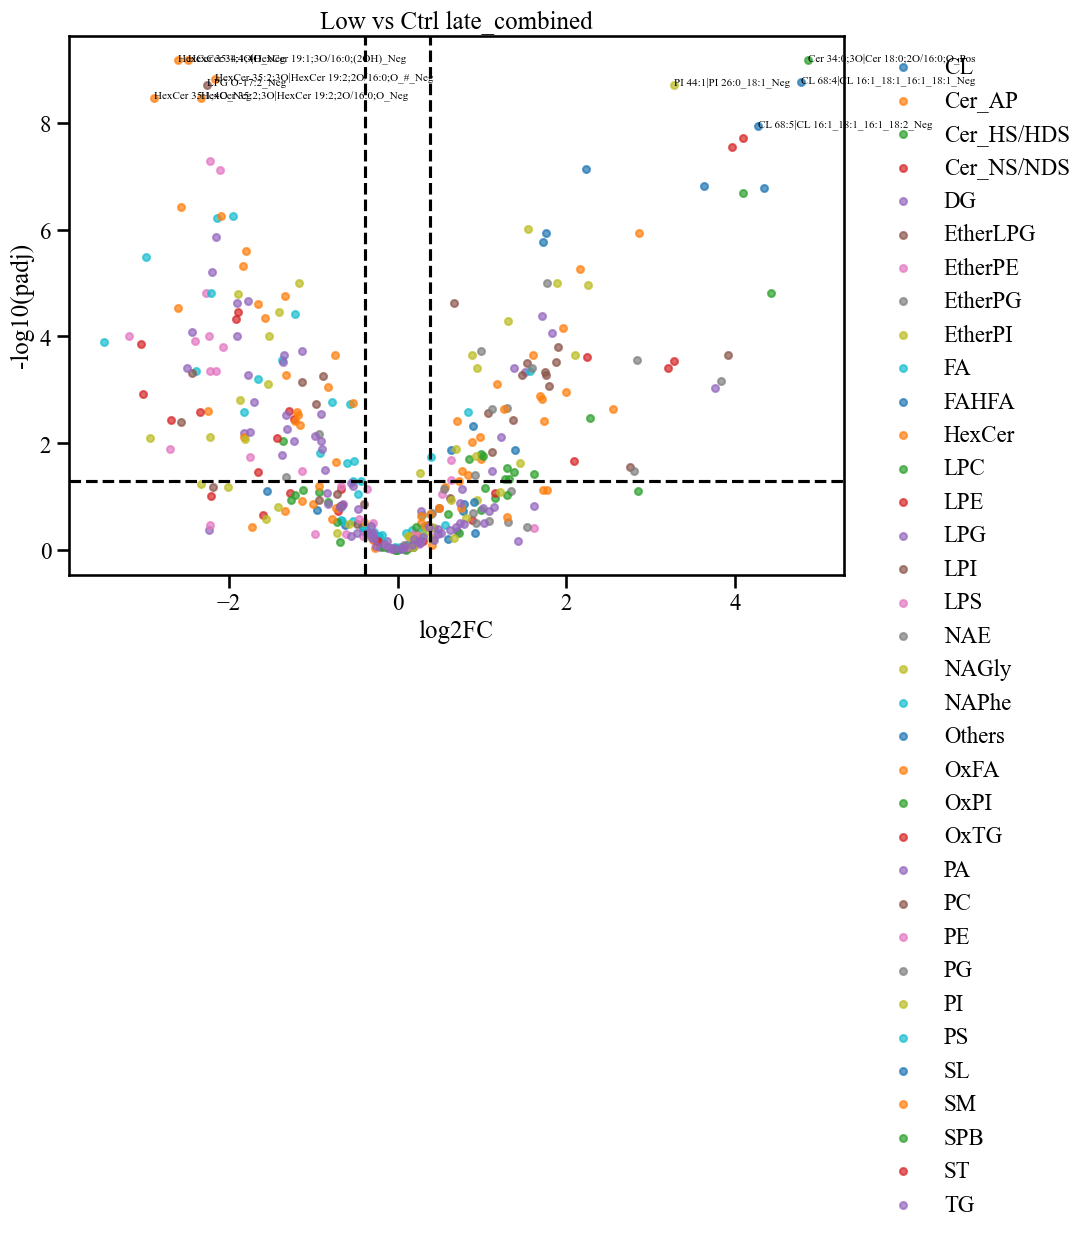

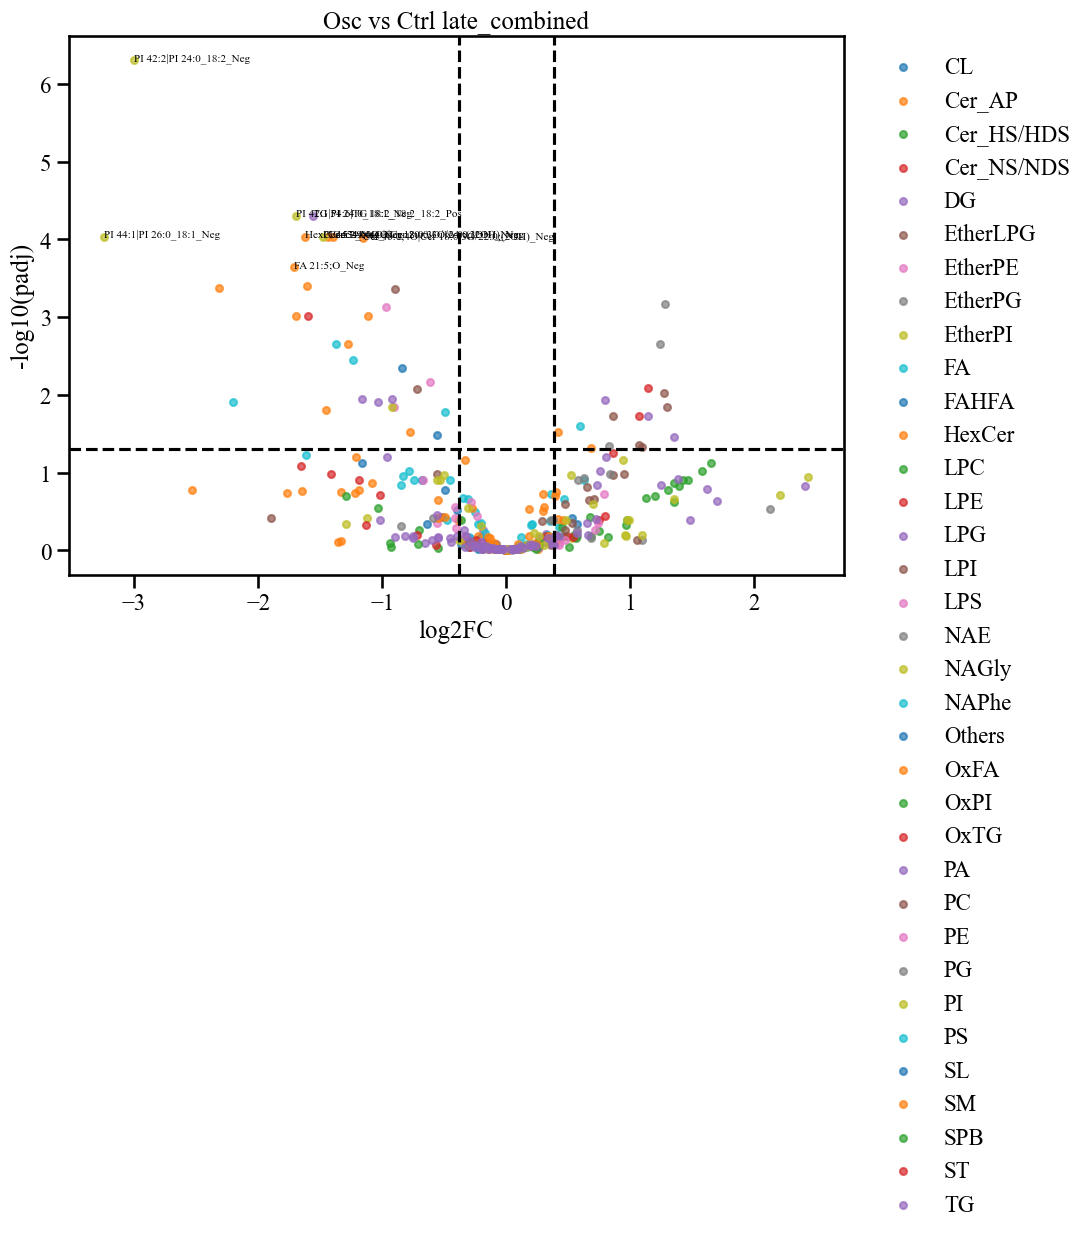

In [30]:
def plot_volcano_by_ontology(df, title, x_cut=0.38, alpha=0.05, top_n_labels=10):
    plot_df = df.dropna(subset=["log2FC", "padj", "Ontology"]).copy()
    plot_df["sig"] = (plot_df["padj"] <= alpha) & (plot_df["log2FC"].abs() >= x_cut)

    fig, ax = plt.subplots(figsize=(10, 7))
    categories = sorted(plot_df["Ontology"].dropna().unique())

    for cat in categories:
        sub = plot_df[plot_df["Ontology"] == cat]
        ax.scatter(sub["log2FC"], sub["neglog10_padj"], s=25, alpha=0.7, label=cat)

    ax.axvline(x_cut, ls="--", color="k")
    ax.axvline(-x_cut, ls="--", color="k")
    ax.axhline(-np.log10(alpha), ls="--", color="k")

    # label top significant lipids
    top = plot_df[plot_df["sig"]].sort_values("padj").head(top_n_labels)
    for _, r in top.iterrows():
        ax.text(r["log2FC"], r["neglog10_padj"], r["lipid"], fontsize=8)

    ax.set_xlabel("log2FC")
    ax.set_ylabel("-log10(padj)")
    ax.set_title(title)
    ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False)
    plt.tight_layout()
    return fig, ax

plot_volcano_by_ontology(low_volc, "Low vs Ctrl late_combined")
plot_volcano_by_ontology(osc_volc, "Osc vs Ctrl late_combined")

(<Figure size 1000x800 with 1 Axes>,
 <Axes: title={'center': 'Top lipid species: Osc vs Ctrl late'}, xlabel='log2FC'>)

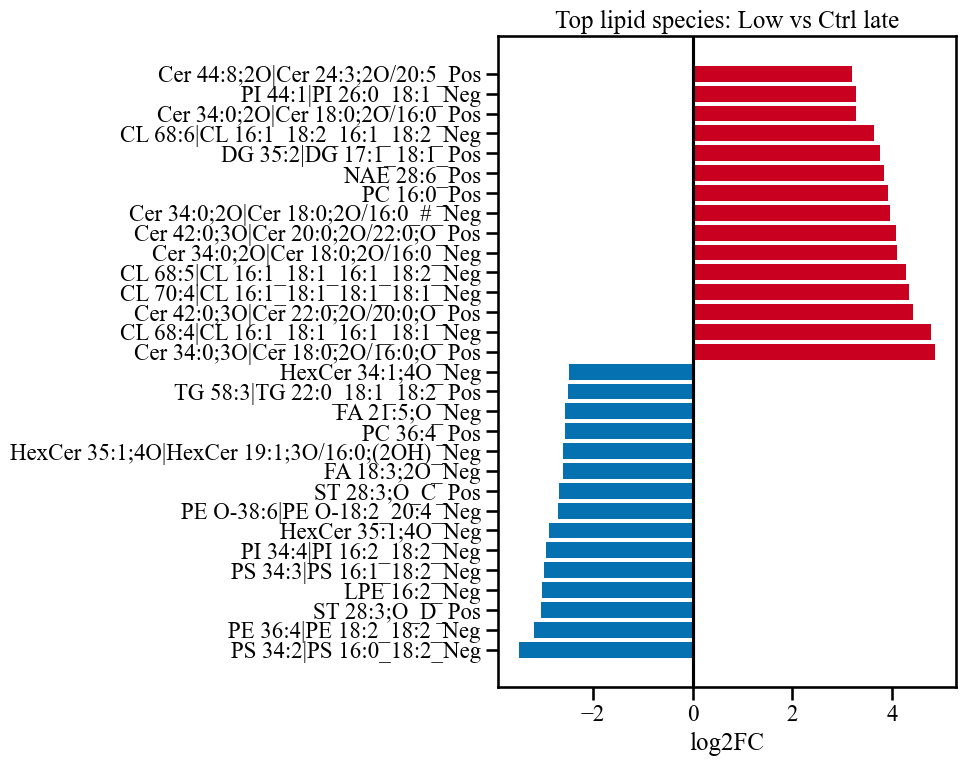

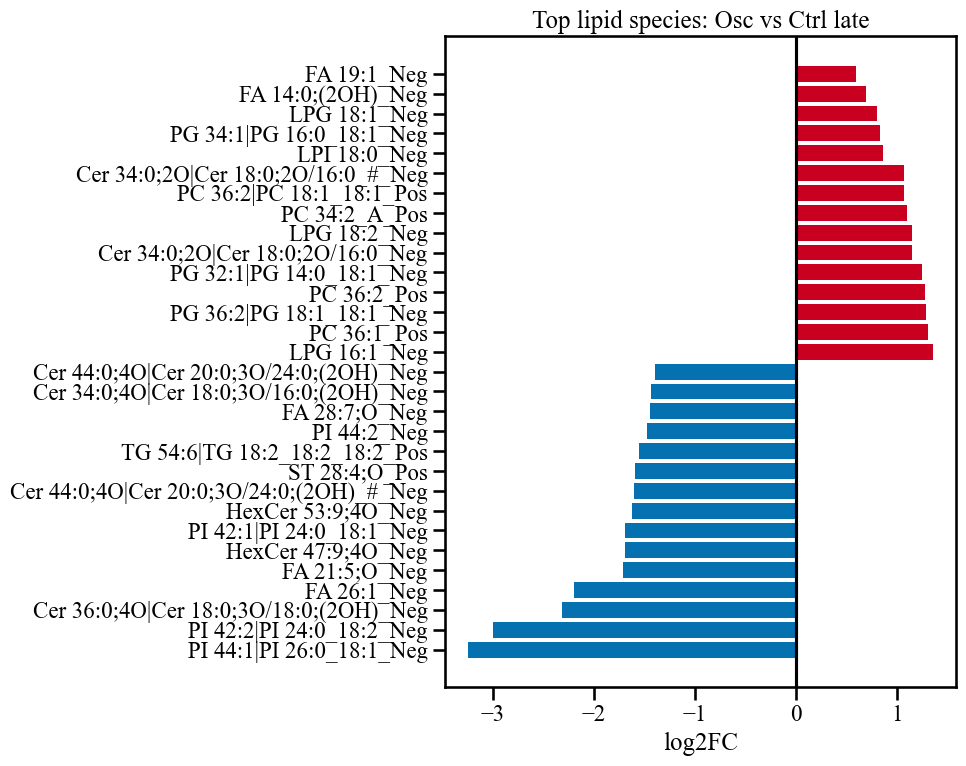

In [31]:
def top_species_plot(df, title, n=15, alpha=0.05, x_cut=0.38):
    plot_df = df.dropna(subset=["log2FC", "padj"]).copy()
    plot_df = plot_df[(plot_df["padj"] <= alpha) & (plot_df["log2FC"].abs() >= x_cut)].copy()

    top_up = plot_df.sort_values("log2FC", ascending=False).head(n)
    top_down = plot_df.sort_values("log2FC", ascending=True).head(n)
    plot_df2 = pd.concat([top_down, top_up], axis=0)

    fig, ax = plt.subplots(figsize=(10, 8))
    colors = ["#0571B0" if x < 0 else "#CA0020" for x in plot_df2["log2FC"]]
    ax.barh(plot_df2["lipid"], plot_df2["log2FC"], color=colors)
    ax.axvline(0, color="k")
    ax.set_xlabel("log2FC")
    ax.set_title(title)
    plt.tight_layout()
    return fig, ax

top_species_plot(low_volc, "Top lipid species: Low vs Ctrl late")
top_species_plot(osc_volc, "Top lipid species: Osc vs Ctrl late")

In [32]:
def summarize_by_class(df, alpha=0.05, x_cut=0.38):
    plot_df = df.dropna(subset=["Ontology", "log2FC", "padj"]).copy()
    plot_df["sig"] = (plot_df["padj"] <= alpha) & (plot_df["log2FC"].abs() >= x_cut)

    summary = (
        plot_df.groupby("Ontology")
        .agg(
            mean_log2FC=("log2FC", "mean"),
            median_log2FC=("log2FC", "median"),
            n_species=("lipid", "count"),
            n_sig=("sig", "sum"),
            frac_sig=("sig", "mean"),
        )
        .reset_index()
        .sort_values("mean_log2FC")
    )
    return summary

low_class = summarize_by_class(low_volc)
osc_class = summarize_by_class(osc_volc)

In [33]:
low_class

,Ontology,mean_log2FC,median_log2FC,n_species,n_sig,frac_sig
29,PS,-2.623486,-2.598083,4,4,1.000000
23,OxTG,-2.212547,-2.212547,1,0,0.000000
16,LPS,-1.988888,-2.068804,3,3,1.000000
8,EtherPI,-1.644284,-1.644284,2,1,0.500000
6,EtherPE,-1.123766,-1.598634,6,2,0.333333
13,LPE,-1.063773,-0.701941,11,5,0.454545
19,NAPhe,-1.024622,-0.669797,4,2,0.500000
22,OxPI,-0.970782,-0.970782,2,0,0.000000
11,HexCer,-0.884956,-1.165689,20,16,0.800000
26,PE,-0.738868,-0.404643,21,9,0.428571


(<Figure size 900x600 with 2 Axes>,
 <Axes: title={'center': 'Ontology bubble plot: Osc vs Ctrl late'}, xlabel='Mean class log2FC'>)

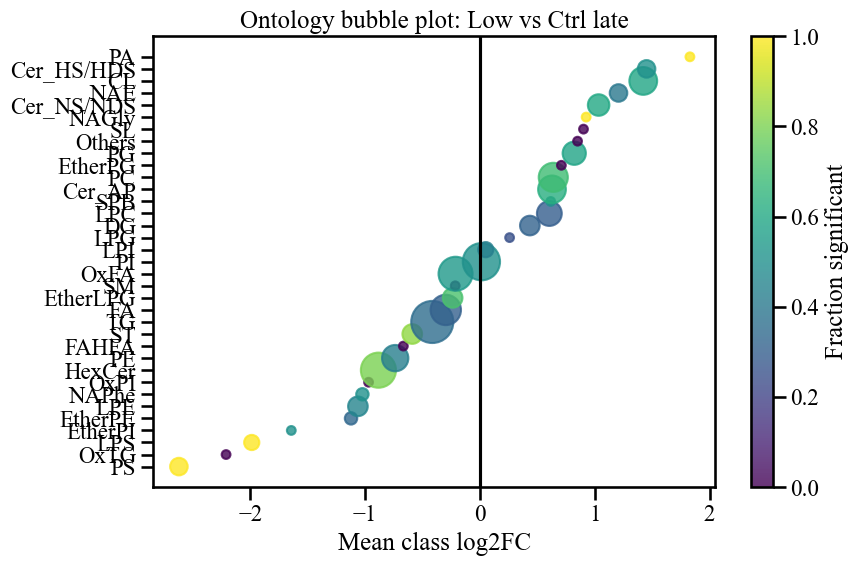

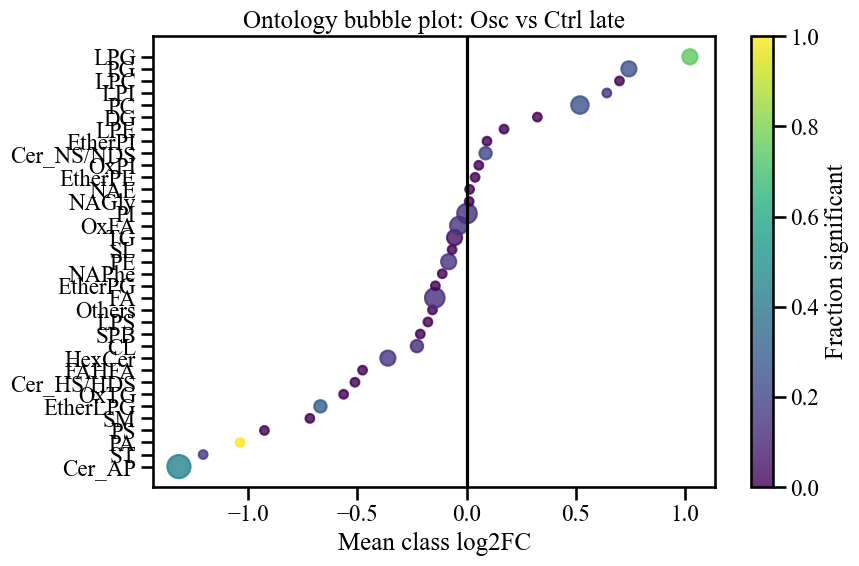

In [34]:
def class_bubbleplot(summary_df, title):
    fig, ax = plt.subplots(figsize=(9, 6))

    sc = ax.scatter(
        summary_df["mean_log2FC"],
        summary_df["Ontology"],
        s=summary_df["n_sig"].clip(lower=1) * 40,
        c=summary_df["frac_sig"],
        alpha=0.8
    )

    ax.axvline(0, color="k")
    ax.set_xlabel("Mean class log2FC")
    ax.set_title(title)
    cbar = plt.colorbar(sc, ax=ax)
    cbar.set_label("Fraction significant")
    plt.tight_layout()
    return fig, ax

class_bubbleplot(low_class, "Ontology bubble plot: Low vs Ctrl late")
class_bubbleplot(osc_class, "Ontology bubble plot: Osc vs Ctrl late")

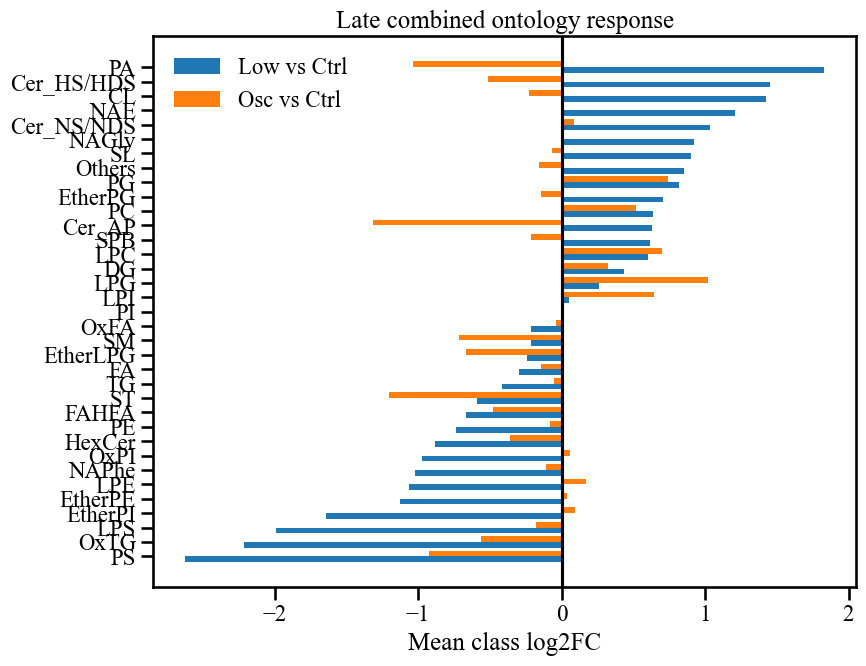

In [35]:
class_compare = low_class.merge(
    osc_class,
    on="Ontology",
    suffixes=("_low", "_osc")
)

fig, ax = plt.subplots(figsize=(9, 7))
y = np.arange(len(class_compare))

ax.barh(y - 0.2, class_compare["mean_log2FC_low"], height=0.4, label="Low vs Ctrl")
ax.barh(y + 0.2, class_compare["mean_log2FC_osc"], height=0.4, label="Osc vs Ctrl")

ax.set_yticks(y)
ax.set_yticklabels(class_compare["Ontology"])
ax.axvline(0, color="k")
ax.set_xlabel("Mean class log2FC")
ax.set_title("Late combined ontology response")
ax.legend(frameon=False)
plt.tight_layout()

In [36]:
# -----------------------------
# 1) Load data
# -----------------------------
df = final_df_annotated

if "Unnamed: 0" in df.columns:
    df = df.drop(columns=["Unnamed: 0"])

# thresholds
alpha = 0.05
x_cut = 1

# contrasts to analyze
contrasts = {
    "Low vs Ctrl (late combined)": (
        "low/control_late_combined",
        "low/control_late_combined_ANOVA_padj"
    ),
    "Osc vs Ctrl (late combined)": (
        "osc/control_late_combined",
        "osc/control_late_combined_ANOVA_padj"
    )
}

In [37]:
def prepare_contrast(df, fc_col, padj_col):
    out = df[["lipid", "lipid_clean", "Ontology", fc_col, padj_col]].copy()
    out = out.rename(columns={fc_col: "log2FC", padj_col: "padj"})
    out["neglog10_padj"] = -np.log10(out["padj"].clip(lower=np.finfo(float).tiny))
    out["sig"] = (out["padj"] <= alpha) & (out["log2FC"].abs() >= x_cut)

    out["direction"] = "ns"
    out.loc[(out["sig"]) & (out["log2FC"] >= x_cut), "direction"] = "up"
    out.loc[(out["sig"]) & (out["log2FC"] <= -x_cut), "direction"] = "down"
    return out

contrast_tables = {
    name: prepare_contrast(df, fc_col, padj_col)
    for name, (fc_col, padj_col) in contrasts.items()
}

In [38]:
for name, d in contrast_tables.items():
    n_sig = d["sig"].sum()
    n_up = ((d["sig"]) & (d["direction"] == "up")).sum()
    n_down = ((d["sig"]) & (d["direction"] == "down")).sum()

    print(f"\n{name}")
    print(f"total lipids: {len(d)}")
    print(f"significant: {n_sig}")
    print(f"up: {n_up}")
    print(f"down: {n_down}")


Low vs Ctrl (late combined)
total lipids: 419
significant: 154
up: 69
down: 85

Osc vs Ctrl (late combined)
total lipids: 419
significant: 32
up: 10
down: 22


In [39]:
def top_hits(d, n=15):
    sig = d[d["sig"]].copy()
    top_up = sig[sig["direction"] == "up"].sort_values(["padj", "log2FC"], ascending=[True, False]).head(n)
    top_down = sig[sig["direction"] == "down"].sort_values(["padj", "log2FC"], ascending=[True, True]).head(n)
    return top_up, top_down

for name, d in contrast_tables.items():
    top_up, top_down = top_hits(d, n=15)

    print(f"\n{name} -- TOP UP")
    print(top_up[["lipid", "Ontology", "log2FC", "padj"]].to_string(index=False))

    print(f"\n{name} -- TOP DOWN")
    print(top_down[["lipid", "Ontology", "log2FC", "padj"]].to_string(index=False))


Low vs Ctrl (late combined) -- TOP UP
                             lipid   Ontology   log2FC         padj
Cer 34:0;3O|Cer 18:0;2O/16:0;O_Pos Cer_HS/HDS 4.863965 6.731910e-10
CL 68:4|CL 16:1_18:1_16:1_18:1_Neg         CL 4.774155 1.756491e-09
          PI 44:1|PI 26:0_18:1_Neg         PI 3.268234 1.928598e-09
CL 68:5|CL 16:1_18:1_16:1_18:2_Neg         CL 4.272542 1.154256e-08
  Cer 34:0;2O|Cer 18:0;2O/16:0_Neg Cer_NS/NDS 4.092529 1.922965e-08
Cer 34:0;2O|Cer 18:0;2O/16:0_#_Neg Cer_NS/NDS 3.955692 2.899115e-08
          CL 74:8|CL 31:2_43:6_Neg         CL 2.225924 7.491202e-08
CL 68:6|CL 16:1_18:2_16:1_18:2_Neg         CL 3.631773 1.500295e-07
CL 70:4|CL 16:1_18:1_18:1_18:1_Neg         CL 4.341155 1.681058e-07
Cer 42:0;3O|Cer 20:0;2O/22:0;O_Pos Cer_HS/HDS 4.083870 2.092360e-07
          PI 35:1|PI 17:0_18:1_Neg         PI 1.541787 9.947296e-07
                HexCer 48:9;4O_Neg     HexCer 2.857041 1.175606e-06
CL 72:9|CL 16:1_20:4_18:2_18:2_Neg         CL 1.758103 1.175606e-06
CL 70:6|C

In [40]:
def summarize_by_class(d):
    out = (
        d.groupby("Ontology")
         .agg(
             n_species=("lipid", "count"),
             mean_log2FC=("log2FC", "mean"),
             median_log2FC=("log2FC", "median"),
             n_sig=("sig", "sum"),
             frac_sig=("sig", "mean")
         )
         .reset_index()
    )
    out = out.sort_values("mean_log2FC")
    return out

class_summaries = {name: summarize_by_class(d) for name, d in contrast_tables.items()}

for name, s in class_summaries.items():
    print(f"\n{name} -- ontology summary")
    print(s.sort_values("n_sig", ascending=False).to_string(index=False))


Low vs Ctrl (late combined) -- ontology summary
  Ontology  n_species  mean_log2FC  median_log2FC  n_sig  frac_sig
        TG         65    -0.415728      -0.319173     18  0.276923
        PI         37     0.012271       0.300913     15  0.405405
    HexCer         21    -0.884956      -1.165689     14  0.666667
      OxFA         28    -0.212951      -0.344365     11  0.392857
        PC         16     0.638575       1.451603     11  0.687500
        CL         17     1.422662       0.894314      8  0.470588
        PE         21    -0.738868      -0.404643      7  0.333333
        PG         13     0.821300       0.837236      6  0.461538
Cer_NS/NDS         11     0.755054       0.302169      6  0.545455
    Cer_AP         16     0.627457       0.804205      6  0.375000
        FA         39    -0.298139      -0.229479      6  0.153846
       LPC         28     0.604308       0.731216      6  0.214286
       LPE         11    -1.063773      -0.701941      5  0.454545
        ST   

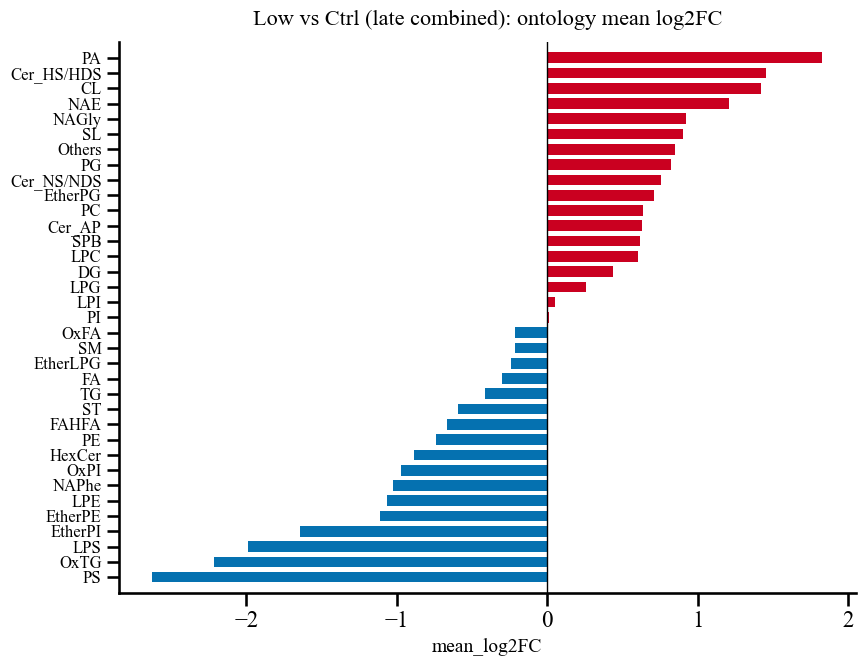

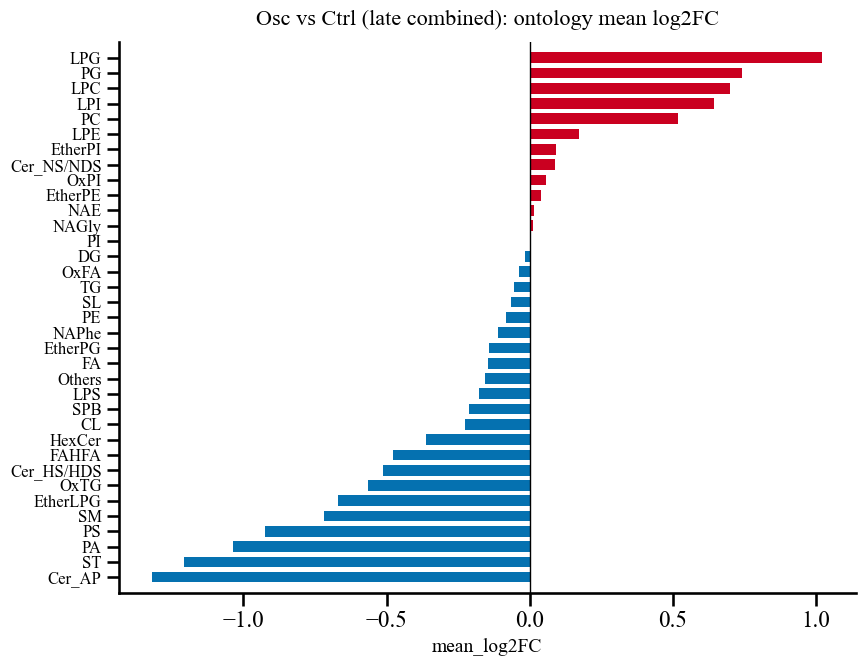

In [41]:


# Global font settings
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = ["Times New Roman"]
plt.rcParams["pdf.fonttype"] = 42
plt.rcParams["ps.fonttype"] = 42

def plot_class_bar(
    summary_df,
    title,
    value_col="mean_log2FC",
    save_path=None,
    dpi=300
):
    plot_df = summary_df.sort_values(value_col).copy()

    # Make figure height depend on number of ontology classes
    n_classes = len(plot_df)
    fig_height = max(6, n_classes * 0.2)   # increase 0.5 -> 0.6 if still crowded

    colors = ["#0571B0" if x < 0 else "#CA0020" for x in plot_df[value_col]]

    fig, ax = plt.subplots(figsize=(9, fig_height))

    y = np.arange(n_classes)
    ax.barh(y, plot_df[value_col], color=colors, height=0.7)

    ax.set_yticks(y)
    ax.set_yticklabels(plot_df["Ontology"], fontsize=12)
    ax.axvline(0, color="black", linewidth=1)

    ax.set_xlabel(value_col, fontsize=14)
    ax.set_title(title, fontsize=16, pad=12)

    # Add a little extra margin around top/bottom
    ax.margins(y=0.02)

    # Optional cleanup
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    plt.tight_layout()

    if save_path is not None:
        fig.savefig(f"{save_path}.png", dpi=dpi, bbox_inches="tight")
        fig.savefig(f"{save_path}.svg", dpi=dpi, bbox_inches="tight")

    plt.show()
    return fig, ax

# Save one file per contrast
for name, s in class_summaries.items():
    safe_name = (
        name.replace(" ", "_")
            .replace("/", "_")
            .replace("(", "")
            .replace(")", "")
            .replace(":", "")
    )

    plot_class_bar(
        s,
        f"{name}: ontology mean log2FC",
        save_path=f"class_bar_{safe_name}"
    )

In [42]:

# -----------------------------
# Global font settings
# -----------------------------
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = ["Times New Roman"]
plt.rcParams["pdf.fonttype"] = 42
plt.rcParams["ps.fonttype"] = 42


# -----------------------------
# Recompute class summaries robustly
# -----------------------------
def summarize_by_class(d):
    out = (
        d.groupby("Ontology")
         .agg(
             n_species=("lipid", "count"),
             median_log2FC=("log2FC", "median"),
             mean_log2FC=("log2FC", "mean"),
             n_sig=("sig", "sum"),
             frac_sig=("sig", "mean")
         )
         .reset_index()
    )
    return out


# rebuild summaries from your contrast tables if needed
class_summaries = {name: summarize_by_class(d) for name, d in contrast_tables.items()}


# -----------------------------
# Plot function
# -----------------------------
def plot_class_summary_robust(
    summary_df,
    title,
    effect_col="median_log2FC",
    save_path=None,
    dpi=300
):
    plot_df = summary_df.copy().sort_values(effect_col)

    # make label with counts
    plot_df["label"] = plot_df.apply(
        lambda r: f"{r['Ontology']}  (n={int(r['n_species'])}, sig={int(r['n_sig'])})",
        axis=1
    )

    n_classes = len(plot_df)
    fig_height = max(7, n_classes * 0.45)

    fig, axes = plt.subplots(
        nrows=1,
        ncols=2,
        figsize=(14, fig_height),
        gridspec_kw={"width_ratios": [1.8, 1.0]},
        sharey=True
    )

    ax1, ax2 = axes
    y = np.arange(n_classes)

    # left panel: median log2FC
    colors = ["#0571B0" if x < 0 else "#CA0020" for x in plot_df[effect_col]]
    ax1.barh(y, plot_df[effect_col], color=colors, height=0.72)
    ax1.axvline(0, color="black", linewidth=1)

    ax1.set_yticks(y)
    ax1.set_yticklabels(plot_df["label"], fontsize=12)
    ax1.tick_params(axis="y", pad=8)
    ax1.set_xlabel("median log2FC", fontsize=14)
    ax1.set_title(f"{title}\nClass-level median effect", fontsize=16, pad=12)

    # right panel: fraction significant
    ax2.barh(y, plot_df["frac_sig"], color="grey", height=0.72)
    ax2.set_xlim(0, 1)
    ax2.set_xlabel("fraction significant", fontsize=14)
    ax2.set_title("Class-level support", fontsize=16, pad=12)

    # annotate fraction significant values
    for yi, val in zip(y, plot_df["frac_sig"]):
        ax2.text(min(val + 0.02, 0.98), yi, f"{val:.2f}", va="center", fontsize=10)

    # clean up
    for ax in axes:
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    plt.tight_layout()

    if save_path is not None:
        fig.savefig(f"{save_path}.png", dpi=dpi, bbox_inches="tight")
        fig.savefig(f"{save_path}.svg", dpi=dpi, bbox_inches="tight")

    plt.show()
    return fig, axes

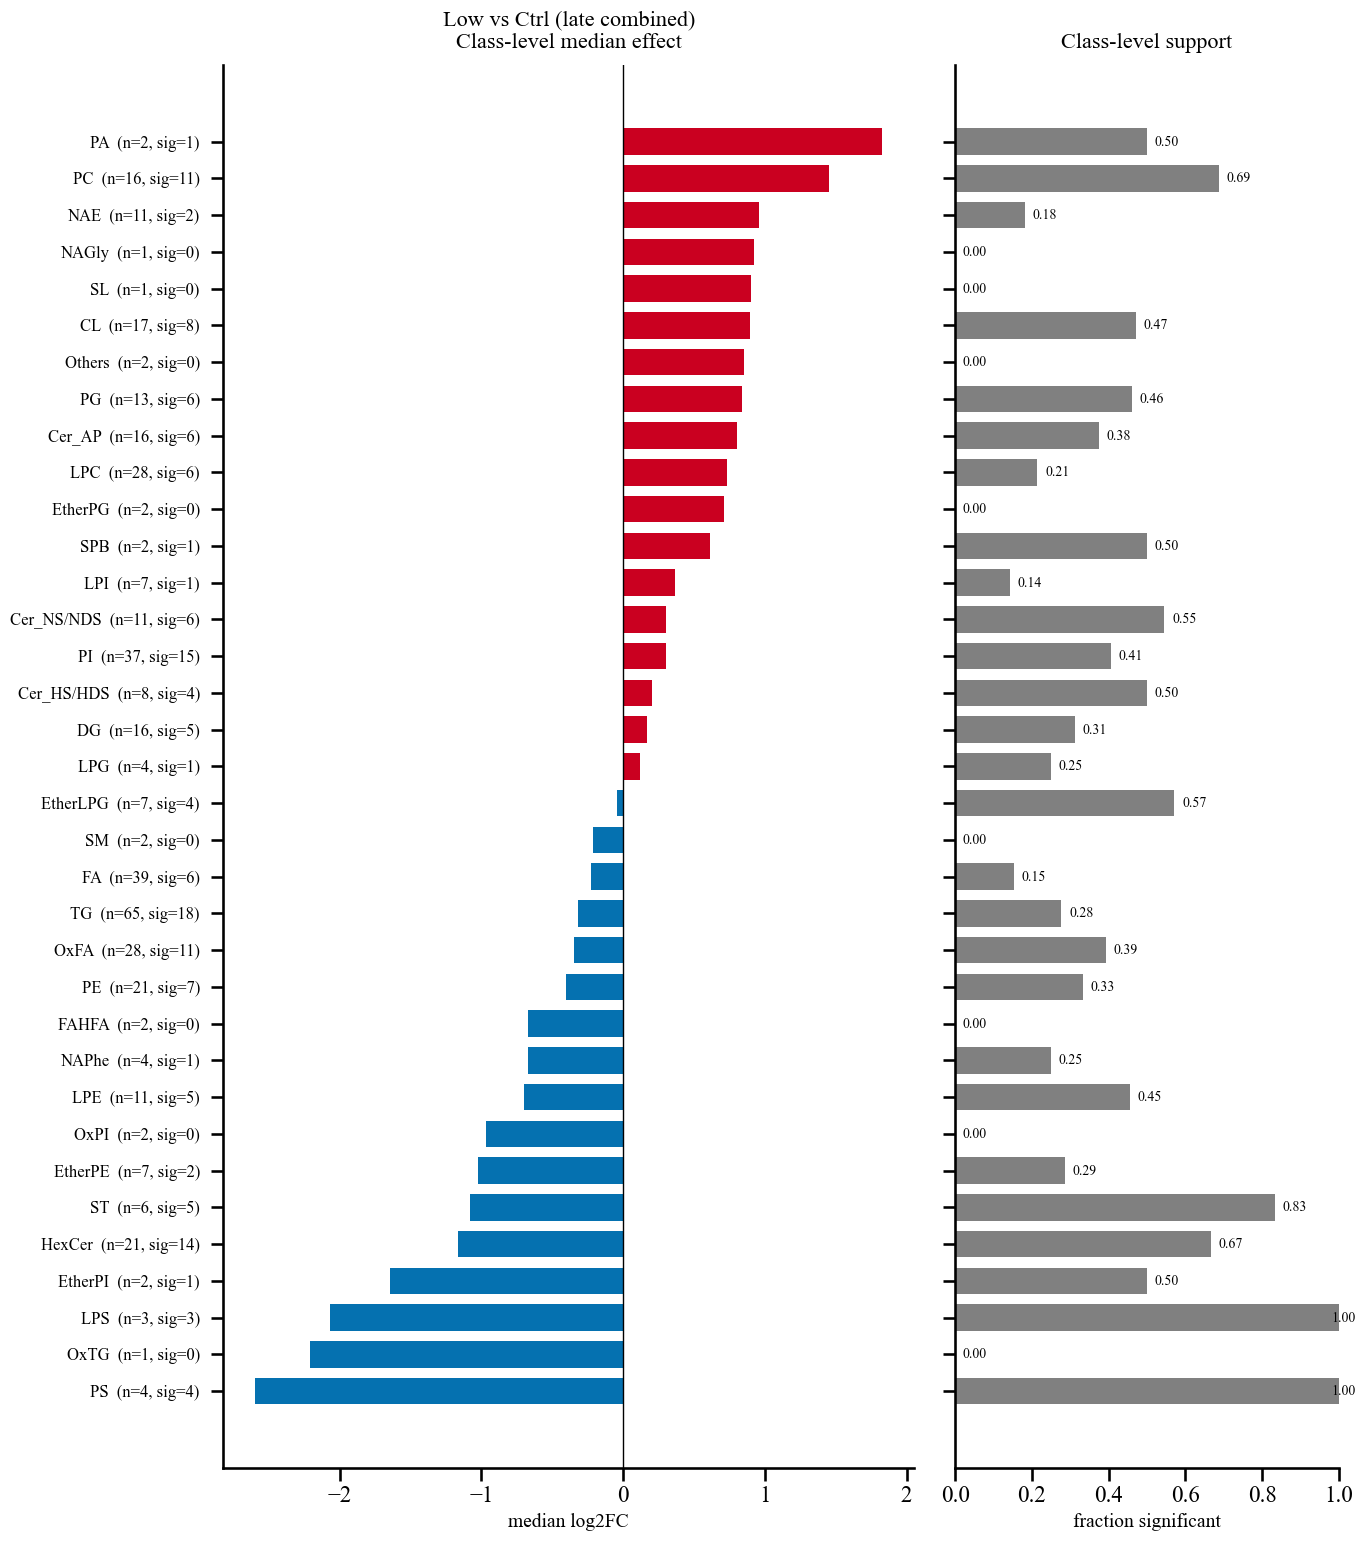

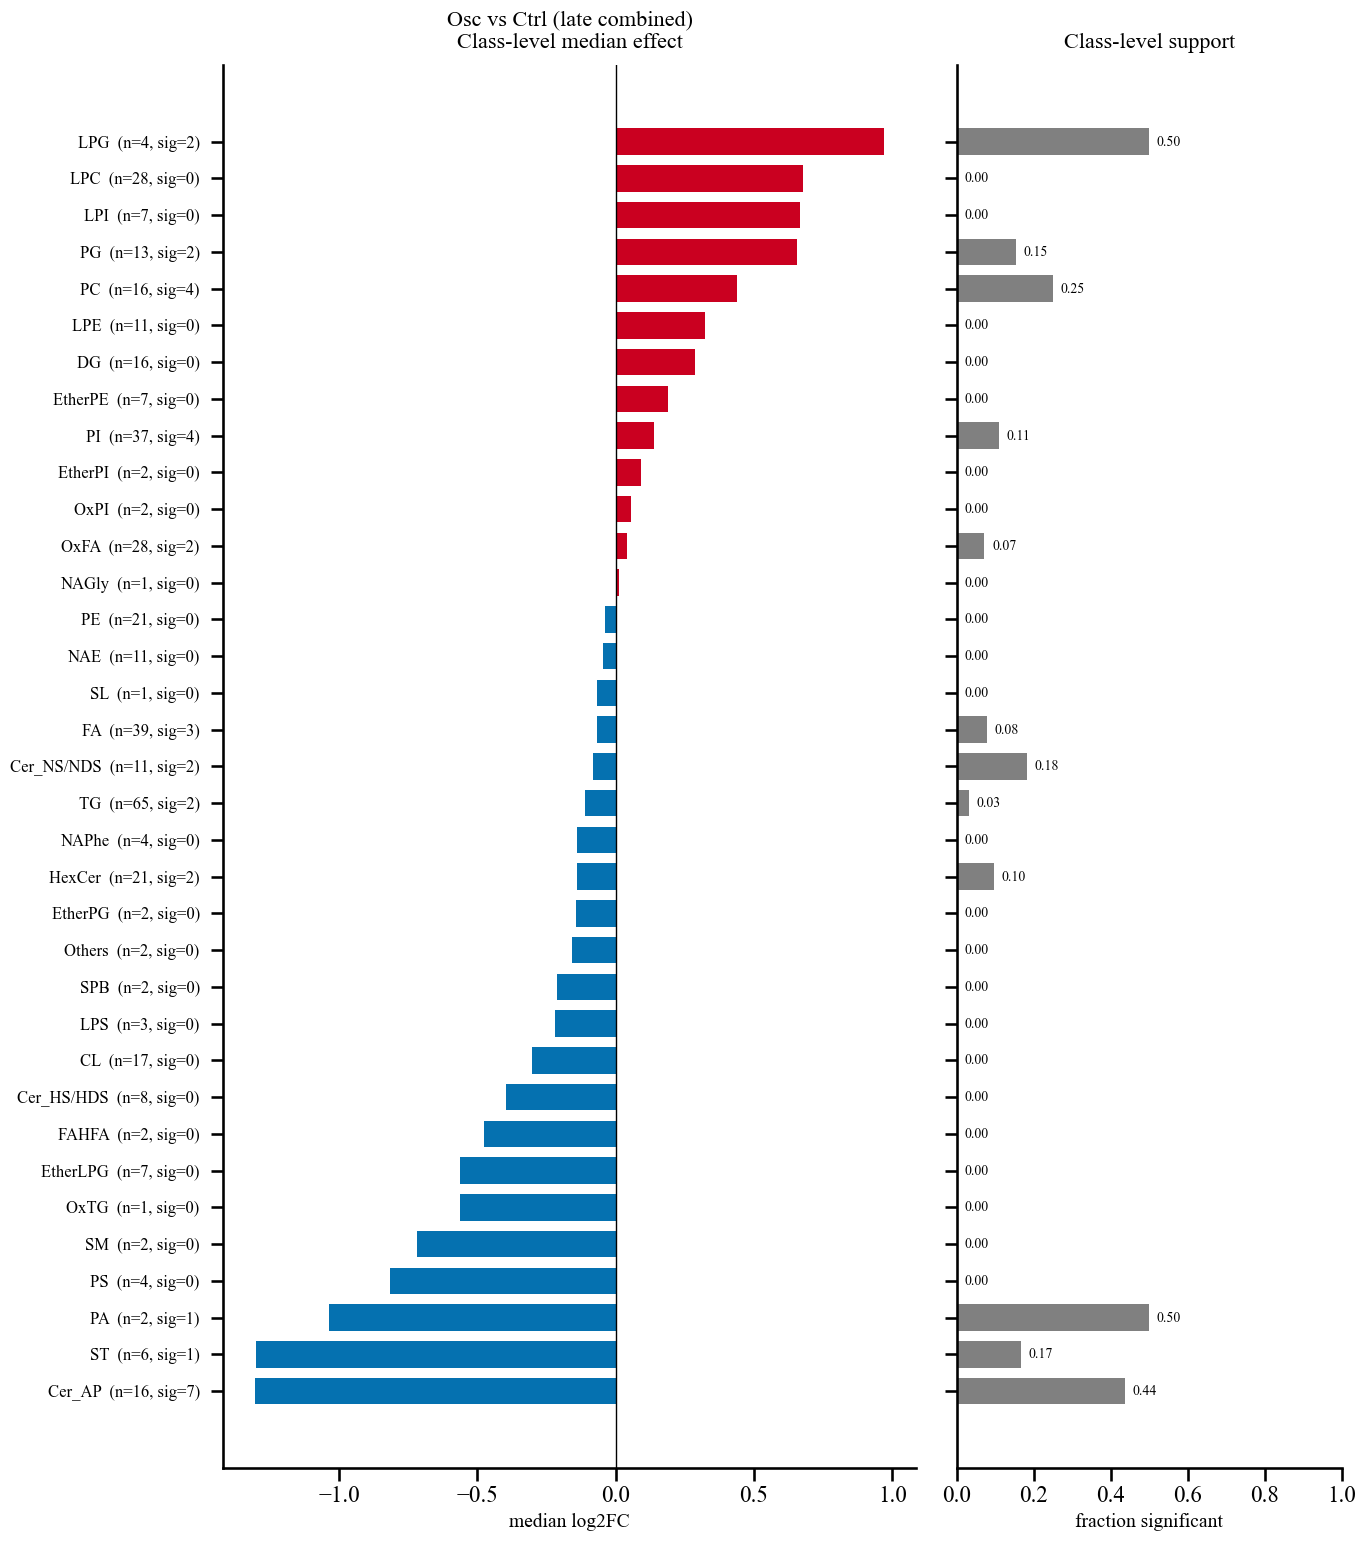

In [43]:
for name, s in class_summaries.items():
    safe_name = (
        name.replace(" ", "_")
            .replace("/", "_")
            .replace("(", "")
            .replace(")", "")
            .replace(":", "")
    )

    plot_class_summary_robust(
        s,
        title=name,
        effect_col="median_log2FC",
        save_path=f"class_summary_robust_{safe_name}"
    )

# Over enrichment/lipid set enrichment analyses. 

In [44]:

# -----------------------------
# 1) Load data
# -----------------------------
df = pd.read_csv("annotated_df.csv")

if "Unnamed: 0" in df.columns:
    df = df.drop(columns=["Unnamed: 0"])


# -----------------------------
# 2) Build ranked table
# -----------------------------
def make_ranked_table(df, fc_col, padj_col, class_col="Ontology"):
    d = df[["lipid", "lipid_clean", class_col, fc_col, padj_col]].copy()
    d = d.rename(columns={
        class_col: "Ontology",
        fc_col: "log2FC",
        padj_col: "padj"
    })
    d = d.dropna(subset=["Ontology", "log2FC", "padj"]).copy()

    # signed ranking statistic
    d["rank_score"] = d["log2FC"] * -np.log10(d["padj"].clip(lower=np.finfo(float).tiny))

    d = d.sort_values("rank_score", ascending=False).reset_index(drop=True)
    return d


# -----------------------------
# 3) GSEA-style enrichment score
# -----------------------------
def enrichment_score(ranked_scores, hits_mask, p=1):
    """
    ranked_scores: numpy array of signed ranking statistics in ranked order
    hits_mask: boolean array, True where class member
    p: weighting exponent (1 is standard GSEA-like weighting)
    """
    N = len(ranked_scores)
    Nh = hits_mask.sum()
    Nm = N - Nh

    if Nh == 0 or Nm == 0:
        return np.nan, np.array([])

    weights = np.abs(ranked_scores) ** p
    hit_weights = weights * hits_mask
    NR = hit_weights.sum()

    running = []
    rs = 0.0
    miss_penalty = 1.0 / Nm

    for i in range(N):
        if hits_mask[i]:
            rs += hit_weights[i] / NR if NR != 0 else 0.0
        else:
            rs -= miss_penalty
        running.append(rs)

    running = np.array(running)
    max_es = running.max()
    min_es = running.min()
    es = max_es if abs(max_es) >= abs(min_es) else min_es

    return es, running


# -----------------------------
# 4) Preranked GSEA-like analysis
# -----------------------------
def lipid_class_gsea(
    ranked_df,
    class_col="Ontology",
    score_col="rank_score",
    min_size=3,
    max_size=500,
    nperm=2000,
    p=1,
    seed=42
):
    rng = np.random.default_rng(seed)

    scores = ranked_df[score_col].to_numpy()
    classes = ranked_df[class_col].to_numpy()
    N = len(ranked_df)

    results = []

    for cls in pd.unique(classes):
        hits = (classes == cls)
        size = int(hits.sum())

        if size < min_size or size > max_size:
            continue

        es, running = enrichment_score(scores, hits, p=p)

        # permutation null by randomizing class membership of same size
        null_es = np.empty(nperm)
        for i in range(nperm):
            perm_hits = np.zeros(N, dtype=bool)
            perm_idx = rng.choice(N, size=size, replace=False)
            perm_hits[perm_idx] = True
            null_es[i], _ = enrichment_score(scores, perm_hits, p=p)

        if es >= 0:
            pos_null = null_es[null_es >= 0]
            nes = es / pos_null.mean() if len(pos_null) else np.nan
            pval = ((pos_null >= es).sum() + 1) / (len(pos_null) + 1) if len(pos_null) else 1.0
            peak_idx = running.argmax()
        else:
            neg_null = -null_es[null_es < 0]
            nes = es / neg_null.mean() if len(neg_null) else np.nan
            pval = ((neg_null >= abs(es)).sum() + 1) / (len(neg_null) + 1) if len(neg_null) else 1.0
            peak_idx = running.argmin()

        leading_edge = ranked_df.loc[:peak_idx, hits, "lipid"] if False else None  # placeholder

        results.append({
            "Ontology": cls,
            "size": size,
            "ES": es,
            "NES": nes,
            "pval": pval,
            "peak_index": int(peak_idx)
        })

    res = pd.DataFrame(results)

    if len(res):
        res = res.sort_values("pval").reset_index(drop=True)

        # Benjamini-Hochberg
        m = len(res)
        bh = res["pval"] * m / np.arange(1, m + 1)
        res["padj"] = np.minimum.accumulate(bh[::-1])[::-1].clip(upper=1)

    return res.sort_values("NES", ascending=False).reset_index(drop=True)


# -----------------------------
# 5) Run for late combined contrasts
# -----------------------------
low_ranked = make_ranked_table(
    df,
    "low/control_late_combined",
    "low/control_late_combined_ANOVA_padj"
)

osc_ranked = make_ranked_table(
    df,
    "osc/control_late_combined",
    "osc/control_late_combined_ANOVA_padj"
)

low_gsea = lipid_class_gsea(low_ranked, min_size=3, nperm=2000, seed=42)
osc_gsea = lipid_class_gsea(osc_ranked, min_size=3, nperm=2000, seed=42)

print("LOW late class enrichment")
print(low_gsea)

print("\nOSC late class enrichment")
print(osc_gsea)

LOW late class enrichment
      Ontology  size        ES       NES      pval  peak_index      padj
0           CL    17  0.910923  1.794173  0.001969          21  0.016842
1   Cer_HS/HDS     8  0.943103  1.583821  0.005297           9  0.031780
2   Cer_NS/NDS    10  0.862263  1.507482  0.020563          18  0.098701
3          LPC    27  0.610318  1.327674  0.094266          96  0.282799
4           DG    16  0.692124  1.326114  0.115800          47  0.308799
5           PG    12  0.714168  1.309185  0.164241          61  0.356863
6          NAE    10  0.694387  1.226568  0.226115          54  0.387625
7           PC    16  0.633120  1.223094  0.217172          56  0.387625
8           PI    36  0.425846  0.965768  0.512796          38  0.631733
9          LPG     4  0.640910  0.955907  0.599169          82  0.631733
10      Cer_AP    16  0.475568  0.913837  0.588113          98  0.631733
11         LPI     7  0.367808  0.604213  0.904357          70  0.904357
12          ST     6 -0.5

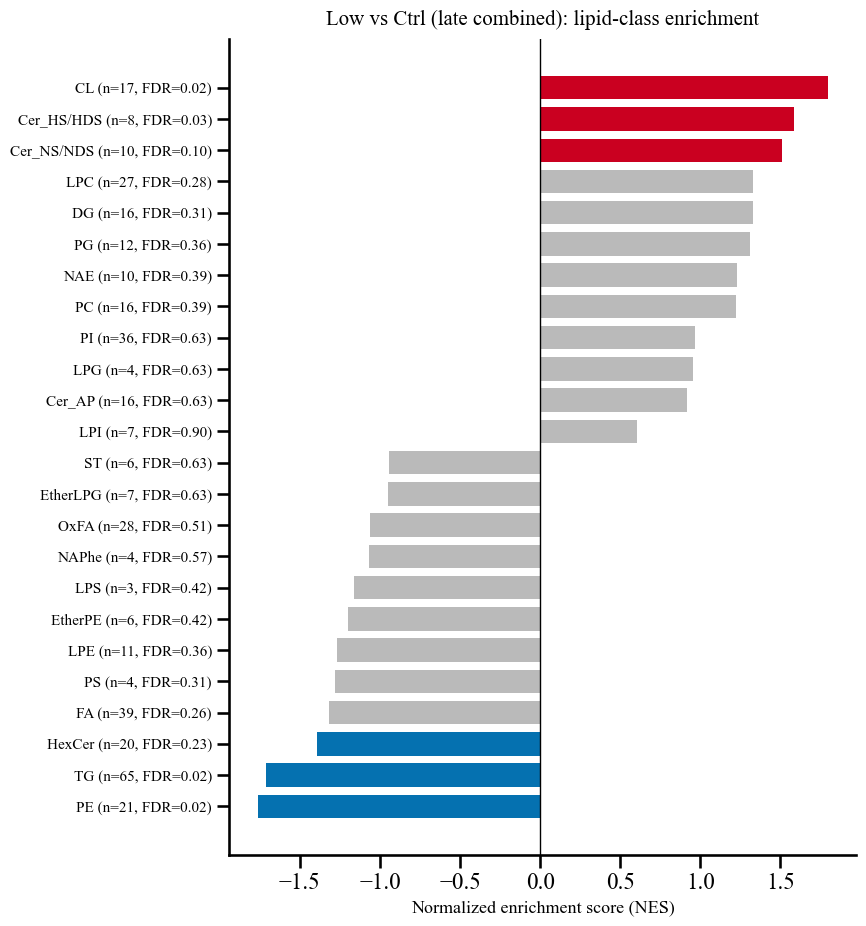

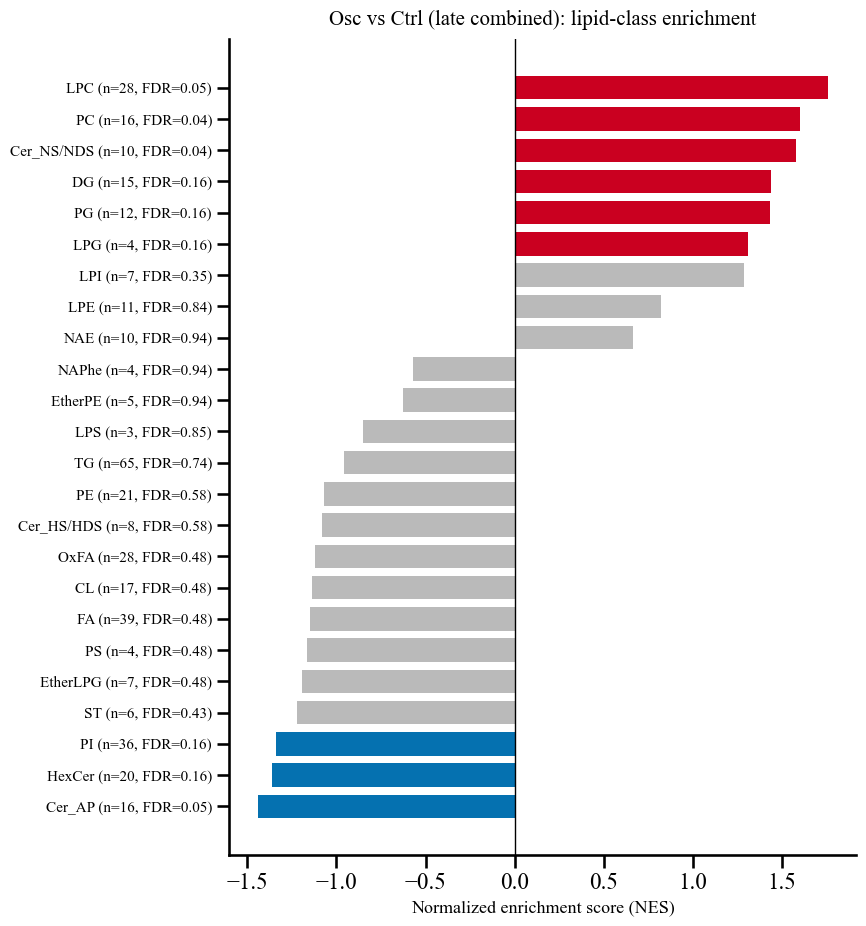

(<Figure size 900x960 with 1 Axes>,
 <Axes: title={'center': 'Osc vs Ctrl (late combined): lipid-class enrichment'}, xlabel='Normalized enrichment score (NES)'>)

In [45]:
def plot_gsea_bar(res, title, padj_cut=0.25, save_path=None, dpi=300):
    plot_df = res.copy().sort_values("NES")

    colors = []
    for _, r in plot_df.iterrows():
        if r["padj"] <= padj_cut:
            colors.append("#CA0020" if r["NES"] > 0 else "#0571B0")
        else:
            colors.append("#BABABA")

    plt.rcParams["font.family"] = "serif"
    plt.rcParams["font.serif"] = ["Times New Roman"]

    fig_height = max(6, 0.4 * len(plot_df))
    fig, ax = plt.subplots(figsize=(9, fig_height))

    y = np.arange(len(plot_df))
    labels = [
        f"{r['Ontology']} (n={int(r['size'])}, FDR={r['padj']:.2f})"
        for _, r in plot_df.iterrows()
    ]

    ax.barh(y, plot_df["NES"], color=colors, height=0.75)
    ax.set_yticks(y)
    ax.set_yticklabels(labels, fontsize=11)
    ax.axvline(0, color="black", linewidth=1)
    ax.set_xlabel("Normalized enrichment score (NES)", fontsize=13)
    ax.set_title(title, fontsize=15, pad=10)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    plt.tight_layout()

    if save_path:
        fig.savefig(f"{save_path}.png", dpi=dpi, bbox_inches="tight")
        fig.savefig(f"{save_path}.svg", dpi=dpi, bbox_inches="tight")

    plt.show()
    return fig, ax

plot_gsea_bar(low_gsea, "Low vs Ctrl (late combined): lipid-class enrichment", save_path="low_late_gsea")
plot_gsea_bar(osc_gsea, "Osc vs Ctrl (late combined): lipid-class enrichment", save_path="osc_late_gsea")

## over representation analysis. 

In [47]:


# -----------------------------
# Load data
# -----------------------------
df = final_df_annotated.copy()

if "Unnamed: 0" in df.columns:
    df = df.drop(columns=["Unnamed: 0"])

alpha = 0.05
# x_cut = 1
x_cut = 0.38

# -----------------------------
# Helper: ranked table
# -----------------------------
def make_ranked_table(df, fc_col, padj_col, class_col="Ontology"):
    d = df[["lipid", "lipid_clean", class_col, fc_col, padj_col]].copy()
    d = d.rename(columns={
        class_col: "Ontology",
        fc_col: "log2FC",
        padj_col: "padj"
    })
    d = d.dropna(subset=["Ontology", "log2FC", "padj"]).copy()

    # rank metric: effect size * confidence
    d["rank_score"] = d["log2FC"] * -np.log10(d["padj"].clip(lower=np.finfo(float).tiny))
    d = d.sort_values("rank_score", ascending=False).reset_index(drop=True)
    return d

# -----------------------------
# GSEA-like enrichment score
# -----------------------------
def enrichment_score(ranked_scores, hits_mask, p=1):
    N = len(ranked_scores)
    Nh = hits_mask.sum()
    Nm = N - Nh

    if Nh == 0 or Nm == 0:
        return np.nan, np.array([])

    weights = np.abs(ranked_scores) ** p
    hit_weights = weights * hits_mask
    NR = hit_weights.sum()

    running = []
    rs = 0.0
    miss_penalty = 1.0 / Nm

    for i in range(N):
        if hits_mask[i]:
            rs += hit_weights[i] / NR if NR != 0 else 0.0
        else:
            rs -= miss_penalty
        running.append(rs)

    running = np.array(running)
    max_es = running.max()
    min_es = running.min()
    es = max_es if abs(max_es) >= abs(min_es) else min_es

    return es, running

# -----------------------------
# GSEA-like class enrichment
# -----------------------------
def lipid_class_gsea(
    ranked_df,
    class_col="Ontology",
    score_col="rank_score",
    min_size=3,
    max_size=500,
    nperm=2000,
    p=1,
    seed=42
):
    rng = np.random.default_rng(seed)

    scores = ranked_df[score_col].to_numpy()
    classes = ranked_df[class_col].to_numpy()
    N = len(ranked_df)

    results = []

    for cls in pd.unique(classes):
        hits = (classes == cls)
        size = int(hits.sum())

        if size < min_size or size > max_size:
            continue

        es, running = enrichment_score(scores, hits, p=p)

        null_es = np.empty(nperm)
        for i in range(nperm):
            perm_hits = np.zeros(N, dtype=bool)
            perm_idx = rng.choice(N, size=size, replace=False)
            perm_hits[perm_idx] = True
            null_es[i], _ = enrichment_score(scores, perm_hits, p=p)

        if es >= 0:
            pos_null = null_es[null_es >= 0]
            nes = es / pos_null.mean() if len(pos_null) else np.nan
            pval = ((pos_null >= es).sum() + 1) / (len(pos_null) + 1) if len(pos_null) else 1.0
        else:
            neg_null = -null_es[null_es < 0]
            nes = es / neg_null.mean() if len(neg_null) else np.nan
            pval = ((neg_null >= abs(es)).sum() + 1) / (len(neg_null) + 1) if len(neg_null) else 1.0

        results.append({
            "Ontology": cls,
            "size": size,
            "ES": es,
            "NES": nes,
            "pval": pval
        })

    res = pd.DataFrame(results)

    if len(res):
        res = res.sort_values("pval").reset_index(drop=True)
        m = len(res)
        bh = res["pval"] * m / np.arange(1, m + 1)
        res["padj"] = np.minimum.accumulate(bh[::-1])[::-1].clip(upper=1)

    return res.sort_values("NES", ascending=False).reset_index(drop=True)

# -----------------------------
# ORA / Fisher enrichment
# direction = "up", "down", or "both"
# -----------------------------
def class_ora(df, fc_col, padj_col, class_col="Ontology",
              alpha=0.05, x_cut=0.38, direction="both", min_size=3):

    d = df[[class_col, fc_col, padj_col]].dropna().copy()
    d["sig"] = (d[padj_col] <= alpha) & (d[fc_col].abs() >= x_cut)

    if direction == "up":
        d["selected"] = d["sig"] & (d[fc_col] >= x_cut)
    elif direction == "down":
        d["selected"] = d["sig"] & (d[fc_col] <= -x_cut)
    else:
        d["selected"] = d["sig"]

    N = len(d)
    K = int(d["selected"].sum())

    rows = []
    for cls, g in d.groupby(class_col):
        n = len(g)
        if n < min_size:
            continue

        k = int(g["selected"].sum())

        # Fisher exact: enrichment of selected lipids in this class
        table = [
            [k, n - k],
            [K - k, (N - n) - (K - k)]
        ]

        odds_ratio, pval = fisher_exact(table, alternative="greater")

        rows.append({
            "Ontology": cls,
            "size": n,
            "selected_in_class": k,
            "selected_total": K,
            "frac_selected_in_class": k / n if n > 0 else np.nan,
            "odds_ratio": odds_ratio,
            "pval": pval
        })

    res = pd.DataFrame(rows).sort_values("pval").reset_index(drop=True)

    if len(res):
        m = len(res)
        bh = res["pval"] * m / np.arange(1, m + 1)
        res["padj"] = np.minimum.accumulate(bh[::-1])[::-1].clip(upper=1)

    return res

# -----------------------------
# Run analyses
# -----------------------------
low_ranked = make_ranked_table(
    df,
    "low/control_late_combined",
    "low/control_late_combined_ANOVA_padj"
)

osc_ranked = make_ranked_table(
    df,
    "osc/control_late_combined",
    "osc/control_late_combined_ANOVA_padj"
)

low_gsea = lipid_class_gsea(low_ranked, min_size=3, nperm=3000, seed=42)
osc_gsea = lipid_class_gsea(osc_ranked, min_size=3, nperm=3000, seed=42)

low_ora_up   = class_ora(df, "low/control_late_combined", "low/control_late_combined_ANOVA_padj", direction="up", alpha=alpha, x_cut=x_cut)
low_ora_down = class_ora(df, "low/control_late_combined", "low/control_late_combined_ANOVA_padj", direction="down", alpha=alpha, x_cut=x_cut)

osc_ora_up   = class_ora(df, "osc/control_late_combined", "osc/control_late_combined_ANOVA_padj", direction="up", alpha=alpha, x_cut=x_cut)
osc_ora_down = class_ora(df, "osc/control_late_combined", "osc/control_late_combined_ANOVA_padj", direction="down", alpha=alpha, x_cut=x_cut)

print("LOW GSEA")
print(low_gsea)

print("\nOSC GSEA")
print(osc_gsea)

print("\nLOW ORA UP")
print(low_ora_up)

print("\nLOW ORA DOWN")
print(low_ora_down)

print("\nOSC ORA UP")
print(osc_ora_up)

print("\nOSC ORA DOWN")
print(osc_ora_down)

LOW GSEA
      Ontology  size        ES       NES      pval      padj
0           CL    17  0.910923  1.805580  0.001329  0.010631
1   Cer_HS/HDS     8  0.943103  1.576123  0.003524  0.021142
2   Cer_NS/NDS    10  0.862263  1.523160  0.020237  0.097139
3           DG    16  0.692124  1.344264  0.104580  0.278879
4          LPC    27  0.610318  1.326454  0.096031  0.278879
5           PG    12  0.714168  1.298295  0.158819  0.334625
6           PC    16  0.633120  1.229626  0.201051  0.371172
7          NAE    10  0.694387  1.214424  0.245042  0.377358
8           PI    36  0.425846  0.974120  0.494297  0.624375
9          LPG     4  0.640910  0.958019  0.605000  0.631304
10      Cer_AP    16  0.475568  0.924430  0.564571  0.631304
11         LPI     7  0.367808  0.597491  0.923022  0.923022
12          ST     6 -0.598450 -0.954887  0.580726  0.631304
13    EtherLPG     7 -0.584605 -0.958112  0.577256  0.631304
14        OxFA    28 -0.470070 -1.049492  0.381458  0.538529
15       NAPhe 

In [48]:


plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = ["Times New Roman"]

def plot_gsea_bar(res, title, padj_cut=0.25, save_path=None, dpi=300):
    plot_df = res.sort_values("NES").copy()

    colors = []
    for _, r in plot_df.iterrows():
        if r["padj"] <= padj_cut:
            colors.append("#CA0020" if r["NES"] > 0 else "#0571B0")
        else:
            colors.append("#BABABA")

    fig_height = max(6, len(plot_df) * 0.4)
    fig, ax = plt.subplots(figsize=(9, fig_height))

    y = np.arange(len(plot_df))
    labels = [
        f"{r['Ontology']} (n={int(r['size'])}, FDR={r['padj']:.2f})"
        for _, r in plot_df.iterrows()
    ]

    ax.barh(y, plot_df["NES"], color=colors, height=0.75)
    ax.set_yticks(y)
    ax.set_yticklabels(labels, fontsize=11)
    ax.axvline(0, color="black", linewidth=1)
    ax.set_xlabel("NES", fontsize=13)
    ax.set_title(title, fontsize=15, pad=10)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    plt.tight_layout()

    if save_path:
        fig.savefig(f"{save_path}.png", dpi=dpi, bbox_inches="tight")
        fig.savefig(f"{save_path}.svg", dpi=dpi, bbox_inches="tight")

    plt.show()


def plot_ora_bar(res, title, padj_cut=0.25, save_path=None, dpi=300):
    plot_df = res.sort_values("odds_ratio").copy()

    colors = ["#CA0020" if p <= padj_cut else "#BABABA" for p in plot_df["padj"]]

    fig_height = max(6, len(plot_df) * 0.4)
    fig, ax = plt.subplots(figsize=(9, fig_height))

    y = np.arange(len(plot_df))
    labels = [
        f"{r['Ontology']} (k={int(r['selected_in_class'])}/{int(r['size'])}, FDR={r['padj']:.2f})"
        for _, r in plot_df.iterrows()
    ]

    ax.barh(y, plot_df["odds_ratio"].replace(np.inf, np.nan), color=colors, height=0.75)
    ax.set_yticks(y)
    ax.set_yticklabels(labels, fontsize=11)
    ax.set_xlabel("Fisher odds ratio", fontsize=13)
    ax.set_title(title, fontsize=15, pad=10)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    plt.tight_layout()

    if save_path:
        fig.savefig(f"{save_path}.png", dpi=dpi, bbox_inches="tight")
        fig.savefig(f"{save_path}.svg", dpi=dpi, bbox_inches="tight")

    plt.show()

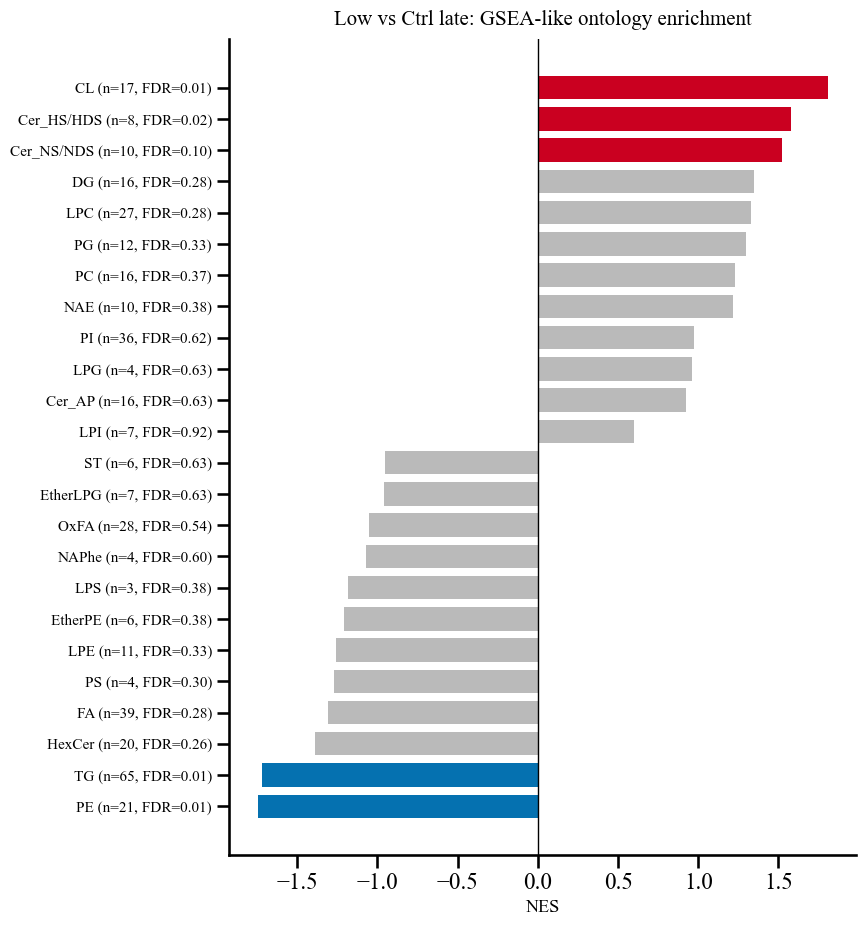

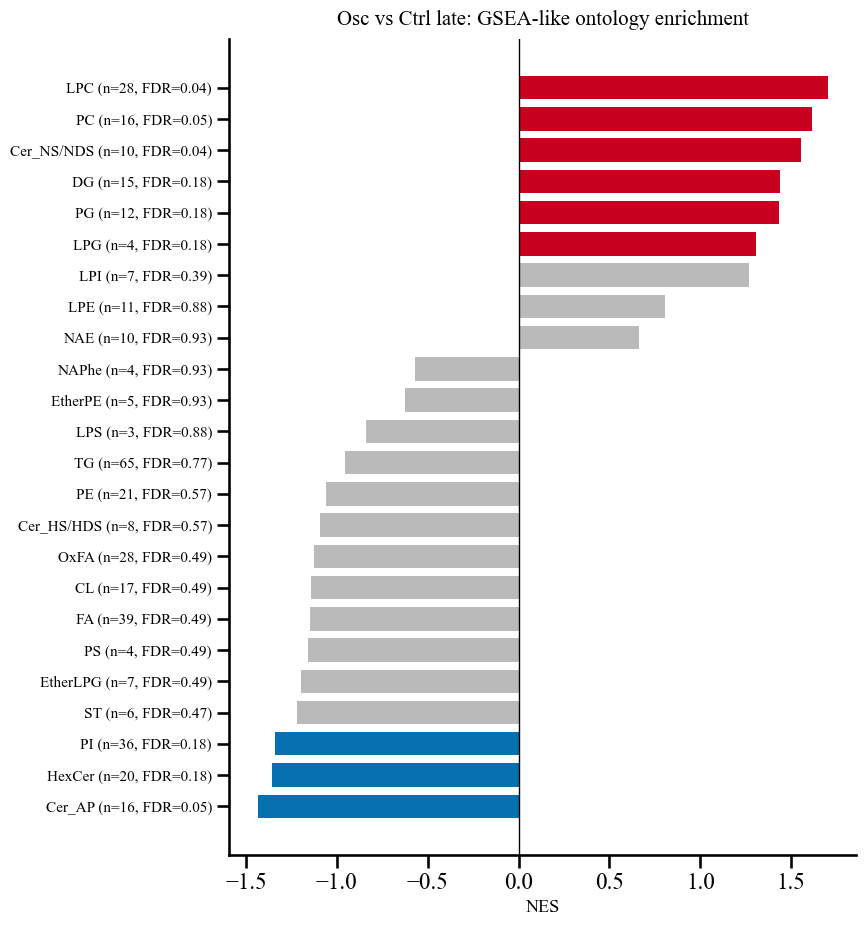

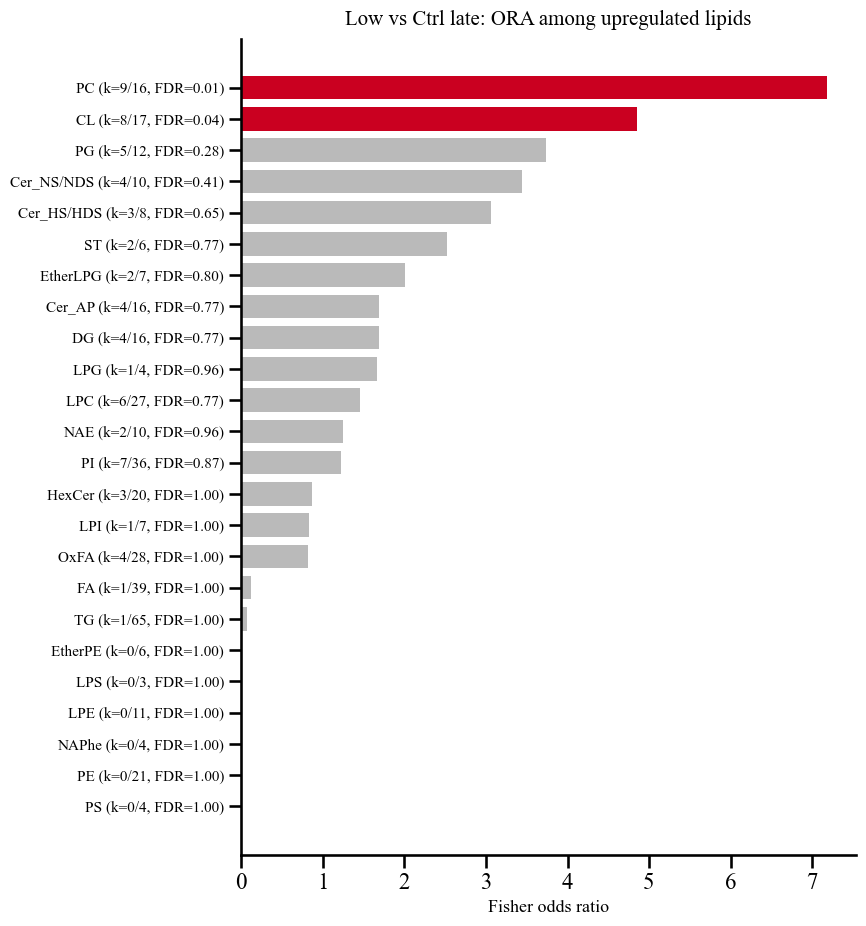

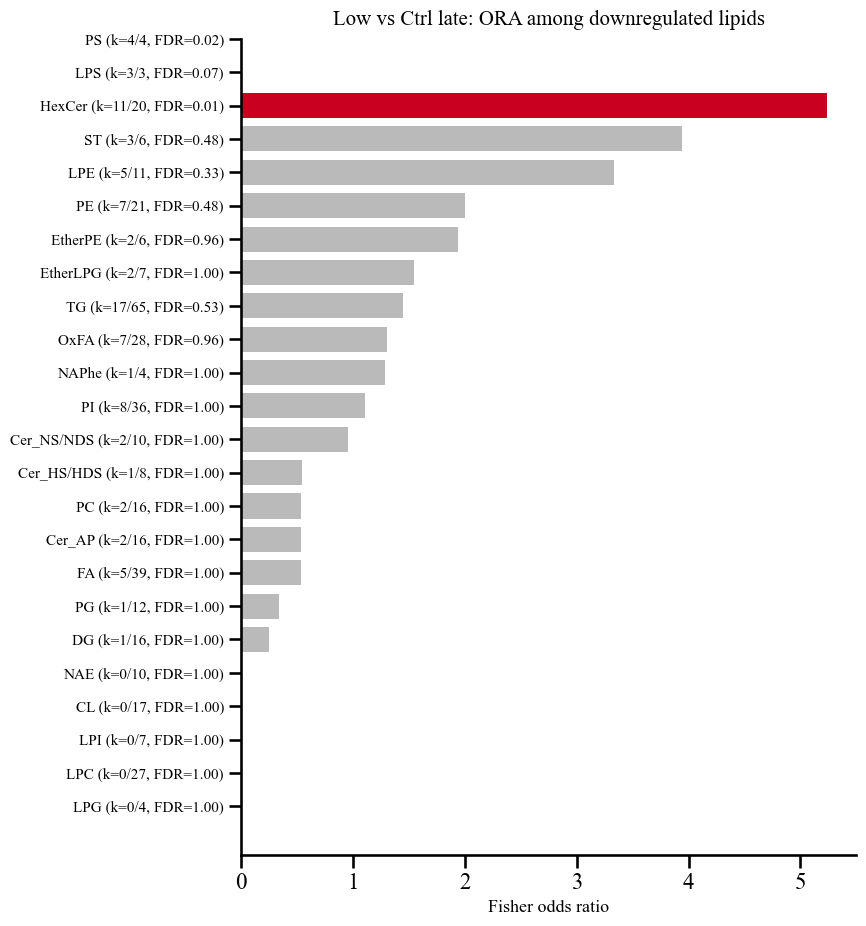

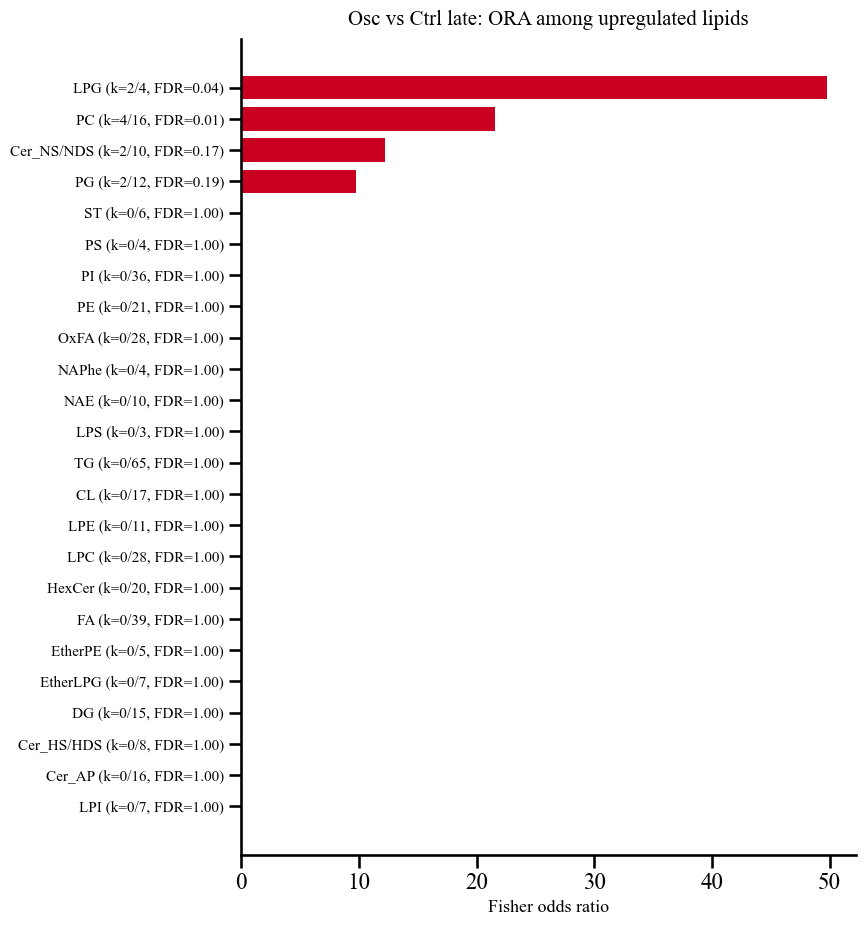

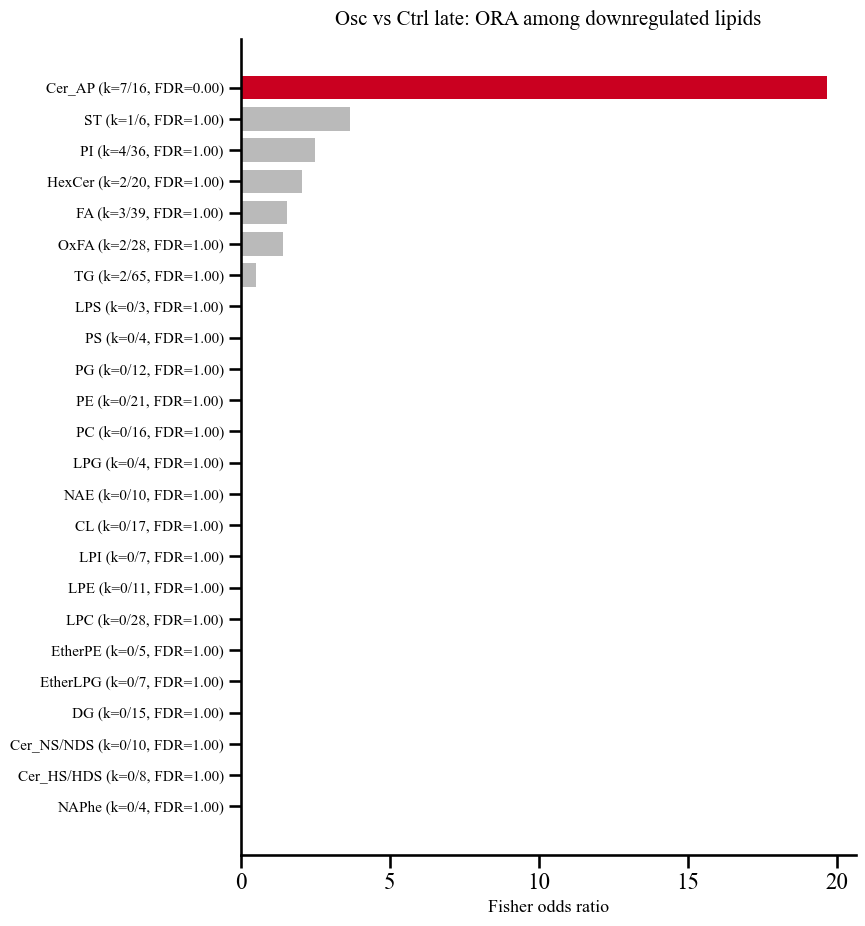

In [49]:
plot_gsea_bar(low_gsea, "Low vs Ctrl late: GSEA-like ontology enrichment", save_path="low_late_gsea")
plot_gsea_bar(osc_gsea, "Osc vs Ctrl late: GSEA-like ontology enrichment", save_path="osc_late_gsea")

plot_ora_bar(low_ora_up,   "Low vs Ctrl late: ORA among upregulated lipids", save_path="low_late_ora_up")
plot_ora_bar(low_ora_down, "Low vs Ctrl late: ORA among downregulated lipids", save_path="low_late_ora_down")
plot_ora_bar(osc_ora_up,   "Osc vs Ctrl late: ORA among upregulated lipids", save_path="osc_late_ora_up")
plot_ora_bar(osc_ora_down, "Osc vs Ctrl late: ORA among downregulated lipids", save_path="osc_late_ora_down")

# class summaries.

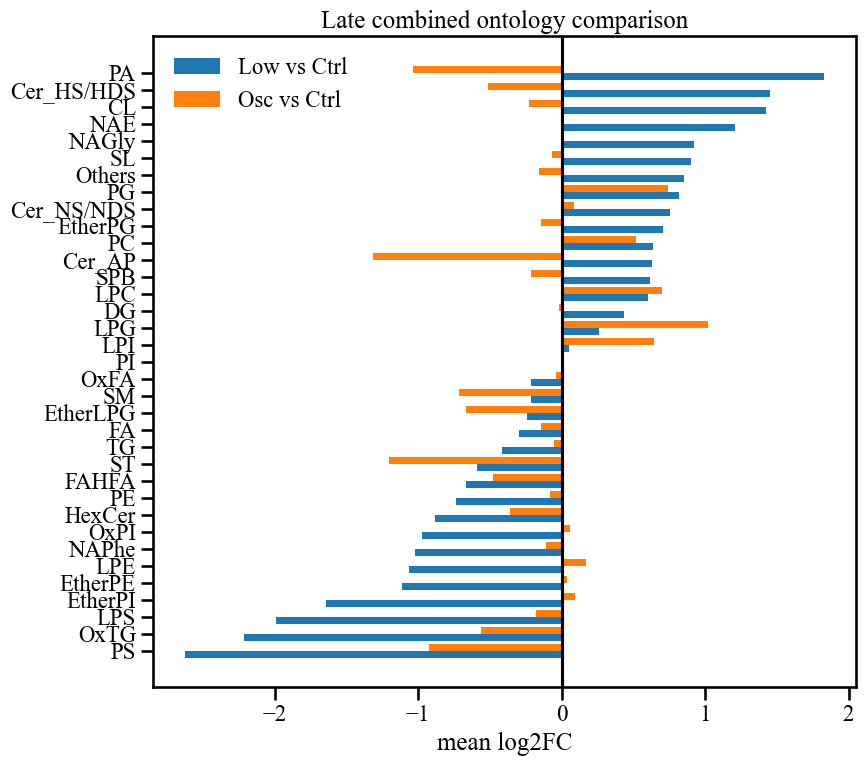

In [50]:
low_summary = class_summaries["Low vs Ctrl (late combined)"].copy()
osc_summary = class_summaries["Osc vs Ctrl (late combined)"].copy()

comp = low_summary.merge(
    osc_summary,
    on="Ontology",
    suffixes=("_low", "_osc")
)

comp = comp.sort_values("mean_log2FC_low")

fig, ax = plt.subplots(figsize=(9, 8))
y = np.arange(len(comp))

ax.barh(y - 0.2, comp["mean_log2FC_low"], height=0.4, label="Low vs Ctrl")
ax.barh(y + 0.2, comp["mean_log2FC_osc"], height=0.4, label="Osc vs Ctrl")

ax.set_yticks(y)
ax.set_yticklabels(comp["Ontology"])
ax.axvline(0, color="black")
ax.set_xlabel("mean log2FC")
ax.set_title("Late combined ontology comparison")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()